<a href="https://colab.research.google.com/github/TanVi3001/drosophila-pd-flygym/blob/main/Session_02_Healthy_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

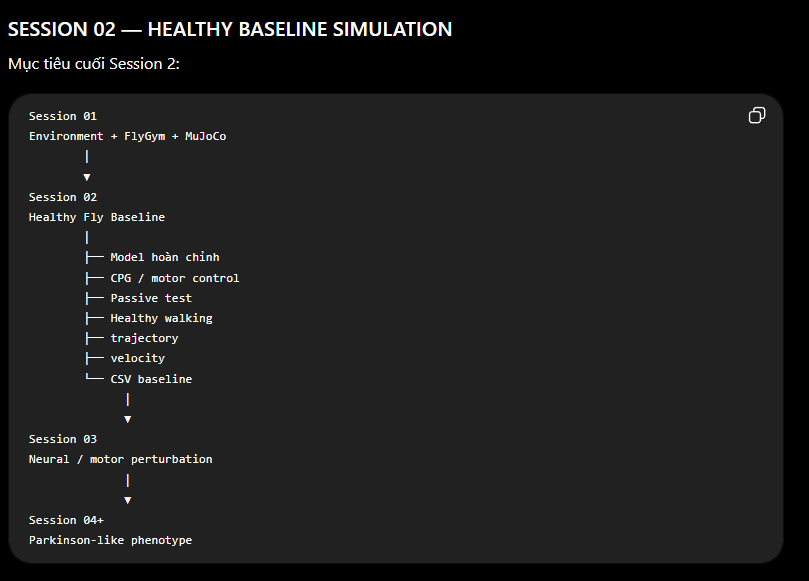

## BLOCK 1 — SESSION 02 INITIALIZATION

In [2]:
# =============================================================================
# SESSION 02 — BLOCK 1
# HEALTHY BASELINE SIMULATION
# =============================================================================

import os
import sys
import json
import platform
from datetime import datetime

print("=" * 70)
print("SESSION 02 — BLOCK 1")
print("HEALTHY BASELINE SIMULATION INITIALIZATION")
print("=" * 70)

PROJECT_ROOT = "/content/drive/MyDrive/FlyBrain_Parkinson_Project"

SESSION_ROOT = os.path.join(
    PROJECT_ROOT,
    "Session_02_Healthy_Baseline"
)

OUTPUT_DIR = os.path.join(
    SESSION_ROOT,
    "outputs"
)

FIGURE_DIR = os.path.join(
    SESSION_ROOT,
    "figures"
)

LOG_DIR = os.path.join(
    SESSION_ROOT,
    "logs"
)

for directory in [
    SESSION_ROOT,
    OUTPUT_DIR,
    FIGURE_DIR,
    LOG_DIR
]:
    os.makedirs(
        directory,
        exist_ok=True
    )

print("\nProject root:")
print(PROJECT_ROOT)

print("\nSession 02:")
print(SESSION_ROOT)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nFigure directory:")
print(FIGURE_DIR)

print("\nLog directory:")
print(LOG_DIR)

print("\nDirectories created successfully ✅")

# -----------------------------------------------------------------------------
# SAVE SESSION METADATA
# -----------------------------------------------------------------------------

metadata = {
    "session": 2,
    "name": "Healthy Baseline Simulation",
    "created_at": datetime.now().isoformat(),
    "python_version": sys.version,
    "platform": platform.platform()
}

metadata_path = os.path.join(
    LOG_DIR,
    "session02_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\nMetadata saved:")
print(metadata_path)

print("\n" + "=" * 70)
print("BLOCK 1 COMPLETE ✅")
print("=" * 70)

SESSION 02 — BLOCK 1
HEALTHY BASELINE SIMULATION INITIALIZATION

Project root:
/content/drive/MyDrive/FlyBrain_Parkinson_Project

Session 02:
/content/drive/MyDrive/FlyBrain_Parkinson_Project/Session_02_Healthy_Baseline

Output directory:
/content/drive/MyDrive/FlyBrain_Parkinson_Project/Session_02_Healthy_Baseline/outputs

Figure directory:
/content/drive/MyDrive/FlyBrain_Parkinson_Project/Session_02_Healthy_Baseline/figures

Log directory:
/content/drive/MyDrive/FlyBrain_Parkinson_Project/Session_02_Healthy_Baseline/logs

Directories created successfully ✅

Metadata saved:
/content/drive/MyDrive/FlyBrain_Parkinson_Project/Session_02_Healthy_Baseline/logs/session02_metadata.json

BLOCK 1 COMPLETE ✅


In [3]:
# ============================================================
# SESSION 02 — BLOCK 1.1
# RUNTIME / ENVIRONMENT CHECK
# ============================================================

import sys
import os
import subprocess

print("=" * 70)
print("SESSION 02 — BLOCK 1.1")
print("RUNTIME / ENVIRONMENT CHECK")
print("=" * 70)

print("\n=== PYTHON ===")
print("Python version:", sys.version)
print("Python executable:", sys.executable)

print("\n=== PACKAGE CHECK ===")

packages = ["mujoco", "flygym", "numpy", "pandas"]

for package in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "show", package],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print(f"{package:10s}: INSTALLED ✅")

        for line in result.stdout.splitlines():
            if line.startswith("Version:"):
                print(" " * 12 + line)
    else:
        print(f"{package:10s}: NOT INSTALLED ❌")

print("\n=== CUDA ===")

try:
    import torch

    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("GPU: NOT AVAILABLE")

except Exception as e:
    print("PyTorch check failed:", type(e).__name__)
    print("Error:", e)

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 1.1 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 1.1
RUNTIME / ENVIRONMENT CHECK

=== PYTHON ===
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Python executable: /usr/bin/python3

=== PACKAGE CHECK ===
mujoco    : NOT INSTALLED ❌
flygym    : NOT INSTALLED ❌
numpy     : INSTALLED ✅
            Version: 2.0.2
pandas    : INSTALLED ✅
            Version: 2.2.2

=== CUDA ===
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

SESSION 02 — BLOCK 1.1 COMPLETE


## SESSION 02 — BLOCK 1.2: CÀI MUJOCO + FLYGYM 2.1.0

In [4]:
# ============================================================
# SESSION 02 — BLOCK 1.2
# INSTALL MUJOCO + FLYGYM 2.1.0
# ============================================================

import sys
import subprocess

print("=" * 70)
print("SESSION 02 — BLOCK 1.2")
print("INSTALL MUJOCO + FLYGYM 2.1.0")
print("=" * 70)

PYTHON = sys.executable

# ------------------------------------------------------------
# 1. INSTALL MUJOCO
# ------------------------------------------------------------

print("\n=== INSTALLING MUJOCO ===")

result = subprocess.run(
    [
        PYTHON,
        "-m",
        "pip",
        "install",
        "-q",
        "mujoco"
    ],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("MuJoCo installation FAILED ❌")
    print(result.stderr[-3000:])
    raise RuntimeError("MuJoCo installation failed")

print("MuJoCo installation completed ✅")


# ------------------------------------------------------------
# 2. INSTALL FLYGYM 2.1.0
# ------------------------------------------------------------

print("\n=== INSTALLING FLYGYM 2.1.0 ===")

result = subprocess.run(
    [
        PYTHON,
        "-m",
        "pip",
        "install",
        "-q",
        "flygym==2.1.0"
    ],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("FlyGym installation FAILED ❌")
    print(result.stderr[-5000:])
    raise RuntimeError("FlyGym installation failed")

print("FlyGym 2.1.0 installation command completed ✅")


# ------------------------------------------------------------
# 3. VERIFY PACKAGE METADATA
# ------------------------------------------------------------

print("\n=== PACKAGE METADATA ===")

for package in ["mujoco", "flygym"]:
    result = subprocess.run(
        [
            PYTHON,
            "-m",
            "pip",
            "show",
            package
        ],
        capture_output=True,
        text=True
    )

    print(f"\n--- {package} ---")

    if result.returncode == 0:
        for line in result.stdout.splitlines():
            if line.startswith(("Name:", "Version:", "Location:")):
                print(line)
    else:
        print("Package metadata NOT FOUND ❌")


print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 1.2 COMPLETE")
print("=" * 70)

print("""
Next:
SESSION 02 — BLOCK 1.3
POST-INSTALL ENVIRONMENT VERIFICATION
""")

SESSION 02 — BLOCK 1.2
INSTALL MUJOCO + FLYGYM 2.1.0

=== INSTALLING MUJOCO ===
MuJoCo installation completed ✅

=== INSTALLING FLYGYM 2.1.0 ===
FlyGym 2.1.0 installation command completed ✅

=== PACKAGE METADATA ===

--- mujoco ---
Name: mujoco
Version: 3.9.0
Location: /usr/local/lib/python3.12/dist-packages

--- flygym ---
Name: flygym
Version: 2.1.0
Location: /usr/local/lib/python3.12/dist-packages

SESSION 02 — BLOCK 1.2 COMPLETE

Next:
SESSION 02 — BLOCK 1.3
POST-INSTALL ENVIRONMENT VERIFICATION



## BLOCK 2 — LOAD SESSION 01 ENVIRONMENT

In [5]:
# =============================================================================
# SESSION 02 — BLOCK 2
# ENVIRONMENT VERIFICATION — FLYGYM 2.1.0
# =============================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 2")
print("ENVIRONMENT VERIFICATION — FLYGYM 2.1.0")
print("=" * 70)

import sys
import os

print("\n=== PYTHON ===")
print("Python:", sys.version)

# -----------------------------------------------------------------------------
# MUJOCO
# -----------------------------------------------------------------------------

print("\n=== MUJOCO ===")

try:
    import mujoco

    print("MuJoCo import: SUCCESS ✅")
    print("MuJoCo version:", mujoco.__version__)

except Exception as e:
    print("MuJoCo import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# -----------------------------------------------------------------------------
# FLYGYM ROOT
# -----------------------------------------------------------------------------

print("\n=== FLYGYM ===")

try:
    import flygym

    print("FlyGym import: SUCCESS ✅")
    print("FlyGym module:", flygym.__file__)

except Exception as e:
    print("FlyGym import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# -----------------------------------------------------------------------------
# FLYGYM 2.1.0 COMPOSE API
# -----------------------------------------------------------------------------

print("\n=== FLYGYM COMPOSE API ===")

try:
    from flygym.compose import (
        NeuroMechFly,
        FlatGroundWorld,
    )

    print("NeuroMechFly import: SUCCESS ✅")
    print("FlatGroundWorld import: SUCCESS ✅")

except Exception as e:
    print("FlyGym compose import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# -----------------------------------------------------------------------------
# ANATOMY API
# -----------------------------------------------------------------------------

print("\n=== FLYGYM ANATOMY API ===")

try:
    from flygym.anatomy import (
        AxisOrder,
        JointPreset,
        Skeleton,
        ActuatedDOFPreset,
        ContactBodiesPreset,
    )

    print("Anatomy API import: SUCCESS ✅")

except Exception as e:
    print("Anatomy API import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# -----------------------------------------------------------------------------
# ROTATION API
# -----------------------------------------------------------------------------

print("\n=== FLYGYM ROTATION API ===")

try:
    from flygym.utils.math import Rotation3D

    print("Rotation3D import: SUCCESS ✅")

except Exception as e:
    print("Rotation3D import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# -----------------------------------------------------------------------------
# NUMPY / PANDAS
# -----------------------------------------------------------------------------

print("\n=== DATA LIBRARIES ===")

try:
    import numpy as np

    print("NumPy:", np.__version__)

except Exception as e:
    print("NumPy import: FAILED ❌")
    print(e)


try:
    import pandas as pd

    print("Pandas:", pd.__version__)

except Exception as e:
    print("Pandas import: FAILED ❌")
    print(e)


# -----------------------------------------------------------------------------
# VERSION CHECK
# -----------------------------------------------------------------------------

print("\n=== VERSION CHECK ===")

try:
    import importlib.metadata as metadata

    flygym_version = metadata.version("flygym")

    print("Installed FlyGym version:", flygym_version)

    if flygym_version.startswith("2.1"):
        print("FlyGym 2.1.x detected ✅")
    else:
        print("WARNING: FlyGym version is not 2.1.x ⚠️")

except Exception as e:
    print("Could not determine FlyGym version ⚠️")
    print(e)


# -----------------------------------------------------------------------------
# FINAL
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 2 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 2
ENVIRONMENT VERIFICATION — FLYGYM 2.1.0

=== PYTHON ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

=== MUJOCO ===
MuJoCo import: SUCCESS ✅
MuJoCo version: 3.9.0

=== FLYGYM ===
FlyGym import: SUCCESS ✅
FlyGym module: /usr/local/lib/python3.12/dist-packages/flygym/__init__.py

=== FLYGYM COMPOSE API ===
NeuroMechFly import: SUCCESS ✅
FlatGroundWorld import: SUCCESS ✅

=== FLYGYM ANATOMY API ===
Anatomy API import: SUCCESS ✅

=== FLYGYM ROTATION API ===
Rotation3D import: SUCCESS ✅

=== DATA LIBRARIES ===
NumPy: 2.0.2
Pandas: 2.2.2

=== VERSION CHECK ===
Installed FlyGym version: 2.1.0
FlyGym 2.1.x detected ✅

SESSION 02 — BLOCK 2 COMPLETE


In [6]:
# =============================================================================
# SESSION 02 — BLOCK 2.1
# ENVIRONMENT VERIFICATION AFTER INSTALLATION
# =============================================================================

import sys

print("=" * 70)
print("SESSION 02 — BLOCK 2.1")
print("VERIFYING FLYGYM + MUJOCO")
print("=" * 70)

print("\n=== PYTHON ===")
print("Version:", sys.version)

# -------------------------------------------------------------------------
# MuJoCo
# -------------------------------------------------------------------------

print("\n=== MUJOCO ===")

try:
    import mujoco

    print("MuJoCo import: SUCCESS ✅")
    print("MuJoCo version:", mujoco.__version__)

except Exception as e:
    print("MuJoCo import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

# -------------------------------------------------------------------------
# FlyGym
# -------------------------------------------------------------------------

print("\n=== FLYGYM ===")

try:
    import flygym

    print("FlyGym import: SUCCESS ✅")
    print("FlyGym module:", flygym.__file__)

except Exception as e:
    print("FlyGym import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

# -------------------------------------------------------------------------
# NumPy / Pandas
# -------------------------------------------------------------------------

print("\n=== NUMPY / PANDAS ===")

try:
    import numpy as np
    print("NumPy:", np.__version__)
except Exception as e:
    print("NumPy: FAILED ❌", e)

try:
    import pandas as pd
    print("Pandas:", pd.__version__)
except Exception as e:
    print("Pandas: FAILED ❌", e)

print("\n" + "=" * 70)
print("BLOCK 2.1 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 2.1
VERIFYING FLYGYM + MUJOCO

=== PYTHON ===
Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

=== MUJOCO ===
MuJoCo import: SUCCESS ✅
MuJoCo version: 3.9.0

=== FLYGYM ===
FlyGym import: SUCCESS ✅
FlyGym module: /usr/local/lib/python3.12/dist-packages/flygym/__init__.py

=== NUMPY / PANDAS ===
NumPy: 2.0.2
Pandas: 2.2.2

BLOCK 2.1 COMPLETE


## BLOCK 3 — RECREATE HEALTHY FLY

In [7]:
# =============================================================================
# SESSION 02 — BLOCK 3
# FLYGYM 2.1.0 API VERIFICATION
# =============================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 3")
print("FLYGYM 2.1.0 API VERIFICATION")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Import FlyGym root
# -----------------------------------------------------------------------------

print("\n=== ROOT PACKAGE ===")

import flygym

print("FlyGym import: SUCCESS ✅")
print("FlyGym location:")
print(flygym.__file__)


# -----------------------------------------------------------------------------
# 2. Check installed version
# -----------------------------------------------------------------------------

print("\n=== VERSION ===")

import importlib.metadata

version = importlib.metadata.version("flygym")

print("FlyGym version:", version)


# -----------------------------------------------------------------------------
# 3. IMPORTANT:
#    NeuroMechFly is imported from flygym.compose
# -----------------------------------------------------------------------------

print("\n=== COMPOSE API ===")

try:

    from flygym.compose import NeuroMechFly

    print("NeuroMechFly import: SUCCESS ✅")
    print("Class:", NeuroMechFly)
    print("Module:", NeuroMechFly.__module__)

except Exception as e:

    print("NeuroMechFly import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

    raise


# -----------------------------------------------------------------------------
# 4. FlatGroundWorld
# -----------------------------------------------------------------------------

print("\n=== WORLD API ===")

try:

    from flygym.compose import FlatGroundWorld

    print("FlatGroundWorld import: SUCCESS ✅")
    print("Class:", FlatGroundWorld)
    print("Module:", FlatGroundWorld.__module__)

except Exception as e:

    print("FlatGroundWorld import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

    raise


# -----------------------------------------------------------------------------
# 5. Verify constructors
# -----------------------------------------------------------------------------

print("\n=== CONSTRUCTOR SIGNATURES ===")

import inspect

print("\nNeuroMechFly constructor:")
print(inspect.signature(NeuroMechFly))

print("\nFlatGroundWorld constructor:")
print(inspect.signature(FlatGroundWorld))


# -----------------------------------------------------------------------------
# 6. Final
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 3 COMPLETE")
print("=" * 70)

print("\nAPI verification status:")
print("NeuroMechFly       : READY ✅")
print("FlatGroundWorld    : READY ✅")
print("FlyGym 2.1.0 API  : VERIFIED ✅")

SESSION 02 — BLOCK 3
FLYGYM 2.1.0 API VERIFICATION

=== ROOT PACKAGE ===
FlyGym import: SUCCESS ✅
FlyGym location:
/usr/local/lib/python3.12/dist-packages/flygym/__init__.py

=== VERSION ===
FlyGym version: 2.1.0

=== COMPOSE API ===
NeuroMechFly import: SUCCESS ✅
Class: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
Module: flygym.compose.fly.neuromechfly

=== WORLD API ===
FlatGroundWorld import: SUCCESS ✅
Class: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
Module: flygym.compose.world.flat_ground

=== CONSTRUCTOR SIGNATURES ===

NeuroMechFly constructor:
(name: str = 'nmf', *, rigging_config_path: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/rigging.yaml'), mesh_basedir: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/meshes'), mujoco_globals_path: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/mujoco_globals.

## BLOCK 4 — CREATE WORLD

In [8]:
# =============================================================================
# SESSION 02 — BLOCK 4
# CREATE FLY + FLAT GROUND WORLD
# FlyGym 2.1.0
# =============================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 4")
print("CREATE FLY + FLAT GROUND WORLD")
print("=" * 70)

import numpy as np

# -----------------------------------------------------------------------------
# IMPORT — FlyGym 2.1.0
# -----------------------------------------------------------------------------

from flygym.compose import (
    NeuroMechFly,
    FlatGroundWorld,
)

print("\n=== IMPORT ===")

print("NeuroMechFly import: SUCCESS ✅")
print("FlatGroundWorld import: SUCCESS ✅")


# -----------------------------------------------------------------------------
# CREATE WORLD
# -----------------------------------------------------------------------------

print("\n=== CREATING WORLD ===")

world = FlatGroundWorld(
    half_size=1000
)

print("World created successfully ✅")
print("World type:", type(world))
print("World class:", world.__class__.__name__)


# -----------------------------------------------------------------------------
# WORLD API INSPECTION
# -----------------------------------------------------------------------------

print("\n=== WORLD API CHECK ===")

print(
    "mjcf_root:",
    "AVAILABLE ✅"
    if hasattr(world, "mjcf_root")
    else "NOT FOUND ❌"
)

print(
    "_fly_lookup:",
    "AVAILABLE ✅"
    if hasattr(world, "_fly_lookup")
    else "NOT FOUND ❌"
)

if hasattr(world, "_fly_lookup"):
    print(
        "Current fly registry:",
        world._fly_lookup
    )


# -----------------------------------------------------------------------------
# CREATE FLY
# -----------------------------------------------------------------------------

print("\n=== CREATING NEUROMECHFLY ===")

fly = NeuroMechFly(
    name="healthy_baseline"
)

print("NeuroMechFly created successfully ✅")
print("Fly type:", type(fly))
print("Fly class:", fly.__class__.__name__)
print("Fly name:", fly.name)


# -----------------------------------------------------------------------------
# FLY API CHECK
# -----------------------------------------------------------------------------

print("\n=== FLY API CHECK ===")

print(
    "Fly name:",
    "AVAILABLE ✅"
    if hasattr(fly, "name")
    else "NOT FOUND ❌"
)

print(
    "mjcf_root:",
    "AVAILABLE ✅"
    if hasattr(fly, "mjcf_root")
    else "NOT FOUND ❌"
)

print(
    "mjcf_model:",
    "AVAILABLE ✅"
    if hasattr(fly, "mjcf_model")
    else "NOT FOUND ❌"
)

print(
    "model:",
    "AVAILABLE ✅"
    if hasattr(fly, "model")
    else "NOT FOUND ❌"
)


# -----------------------------------------------------------------------------
# CHECK DUPLICATE FLY
# -----------------------------------------------------------------------------

print("\n=== DUPLICATE FLY CHECK ===")

if hasattr(world, "_fly_lookup"):

    if fly.name in world._fly_lookup:

        print(
            f"Fly '{fly.name}' already exists "
            "in world ⚠️"
        )

    else:

        print(
            f"Fly '{fly.name}' is not yet "
            "registered in world ✅"
        )

else:

    print(
        "World does not expose _fly_lookup "
        "through this API ❗"
    )


# -----------------------------------------------------------------------------
# BASIC VALIDATION
# -----------------------------------------------------------------------------

print("\n=== OBJECT VALIDATION ===")

assert world is not None
assert fly is not None

assert isinstance(
    world,
    FlatGroundWorld
)

assert isinstance(
    fly,
    NeuroMechFly
)

print("World object: VALID ✅")
print("Fly object: VALID ✅")


# -----------------------------------------------------------------------------
# GLOBAL VARIABLES
# -----------------------------------------------------------------------------

print("\n=== GLOBAL VARIABLES ===")

print("world assigned: YES ✅")
print("fly assigned: YES ✅")


# -----------------------------------------------------------------------------
# IMPORTANT — DO NOT ADD FLY YET
# -----------------------------------------------------------------------------

print("\n=== WORLD REGISTRATION ===")

print(
    "Fly has NOT been added to world yet."
)

print(
    "world.add_fly(...) will be performed "
    "in the next block."
)


# -----------------------------------------------------------------------------
# FINAL
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 4 COMPLETE")
print("=" * 70)

print("\nStatus:")
print("FlatGroundWorld      : CREATED ✅")
print("NeuroMechFly         : CREATED ✅")
print("World object         : VALID ✅")
print("Fly object           : VALID ✅")
print("Ready for Block 5    : YES ✅")

SESSION 02 — BLOCK 4
CREATE FLY + FLAT GROUND WORLD

=== IMPORT ===
NeuroMechFly import: SUCCESS ✅
FlatGroundWorld import: SUCCESS ✅

=== CREATING WORLD ===
World created successfully ✅
World type: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
World class: FlatGroundWorld

=== WORLD API CHECK ===
mjcf_root: AVAILABLE ✅
_fly_lookup: AVAILABLE ✅
Current fly registry: {}

=== CREATING NEUROMECHFLY ===
NeuroMechFly created successfully ✅
Fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
Fly class: NeuroMechFly
Fly name: healthy_baseline

=== FLY API CHECK ===
Fly name: AVAILABLE ✅
mjcf_root: AVAILABLE ✅
mjcf_model: NOT FOUND ❌
model: NOT FOUND ❌

=== DUPLICATE FLY CHECK ===
Fly 'healthy_baseline' is not yet registered in world ✅

=== OBJECT VALIDATION ===
World object: VALID ✅
Fly object: VALID ✅

=== GLOBAL VARIABLES ===
world assigned: YES ✅
fly assigned: YES ✅

=== WORLD REGISTRATION ===
Fly has NOT been added to world yet.
world.add_fly(...) will be performe

## SESSION 02 — BLOCK 5: ADD FLY TO WORLD

In [9]:
# =============================================================================
# SESSION 02 — BLOCK 5.0
# FLYGYM ROTATION API DISCOVERY
# =============================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 5.0")
print("FLYGYM ROTATION API DISCOVERY")
print("=" * 70)

import flygym
import inspect
import pkgutil
import importlib

# -----------------------------------------------------------------------------
# BASIC PACKAGE INFO
# -----------------------------------------------------------------------------

print("\n=== FLYGYM PACKAGE ===")

print("FlyGym location:")
print(flygym.__file__)

print("\nFlyGym version:")
print(getattr(flygym, "__version__", "UNKNOWN"))


# -----------------------------------------------------------------------------
# SEARCH ALL FLYGYM MODULES FOR ROTATION
# -----------------------------------------------------------------------------

print("\n=== SEARCHING FLYGYM MODULES ===")

rotation_modules = []

for module_info in pkgutil.walk_packages(
    flygym.__path__,
    prefix=flygym.__name__ + "."
):

    module_name = module_info.name

    if (
        "rotation" in module_name.lower()
        or "transform" in module_name.lower()
        or "pose" in module_name.lower()
        or "spatial" in module_name.lower()
    ):
        rotation_modules.append(module_name)


if rotation_modules:

    print("Potential modules found:")

    for module_name in rotation_modules:
        print(" -", module_name)

else:

    print(
        "No obvious rotation/transform/pose modules found."
    )


# -----------------------------------------------------------------------------
# SEARCH FLYGYM SOURCE FILES
# -----------------------------------------------------------------------------

print("\n=== SEARCHING PACKAGE SOURCE ===")

import os

flygym_root = os.path.dirname(flygym.__file__)

print("FlyGym root:")
print(flygym_root)

matches = []

for root, dirs, files in os.walk(flygym_root):

    for filename in files:

        if not filename.endswith(".py"):
            continue

        filepath = os.path.join(root, filename)

        try:

            with open(
                filepath,
                "r",
                encoding="utf-8",
                errors="ignore"
            ) as f:

                text = f.read()

            if (
                "class Rotation3D" in text
                or "Rotation3D" in text
            ):

                matches.append(filepath)

        except Exception:
            pass


if matches:

    print("\nFiles containing Rotation3D:")

    for filepath in matches:
        print(" -", filepath)

else:

    print(
        "No Python source file containing "
        "'Rotation3D' was found."
    )


# -----------------------------------------------------------------------------
# INSPECT BASE WORLD
# -----------------------------------------------------------------------------

print("\n=== BASEWORLD ADD_FLY API ===")

from flygym.compose.world.base_world import BaseWorld

print(
    "BaseWorld.add_fly signature:"
)

print(
    inspect.signature(
        BaseWorld.add_fly
    )
)


# -----------------------------------------------------------------------------
# INSPECT INTERNAL ATTACH METHOD
# -----------------------------------------------------------------------------

print("\n=== INTERNAL ATTACH METHOD ===")

print(
    "BaseWorld._attach_fly_mjcf signature:"
)

print(
    inspect.signature(
        BaseWorld._attach_fly_mjcf
    )
)


# -----------------------------------------------------------------------------
# INSPECT SOURCE AROUND spawn_rotation
# -----------------------------------------------------------------------------

print("\n=== SOURCE INSPECTION ===")

try:

    source = inspect.getsource(
        BaseWorld._attach_fly_mjcf
    )

    lines = source.splitlines()

    for i, line in enumerate(lines):

        if "spawn_rotation" in line:

            start = max(0, i - 8)
            end = min(
                len(lines),
                i + 12
            )

            print(
                "\n".join(
                    lines[start:end]
                )
            )

except Exception as e:

    print(
        "Could not inspect source:",
        repr(e)
    )


# -----------------------------------------------------------------------------
# SEARCH EXPORTED SYMBOLS
# -----------------------------------------------------------------------------

print("\n=== ROOT PACKAGE SYMBOL SEARCH ===")

rotation_symbols = [
    name
    for name in dir(flygym)
    if (
        "rotation" in name.lower()
        or "transform" in name.lower()
        or "pose" in name.lower()
    )
]

if rotation_symbols:

    print(
        "Potential root symbols:"
    )

    for name in rotation_symbols:
        print(" -", name)

else:

    print(
        "No rotation-related root symbols."
    )


# -----------------------------------------------------------------------------
# COMPLETE
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 5.0 COMPLETE")
print("=" * 70)

print(
    "\nIMPORTANT:"
)

print(
    "Do NOT call world.add_fly() yet."
)

print(
    "Do NOT create spawn_rotation yet."
)

print(
    "We first identify the exact rotation class/API "
    "installed in this Colab environment."
)

SESSION 02 — BLOCK 5.0
FLYGYM ROTATION API DISCOVERY

=== FLYGYM PACKAGE ===
FlyGym location:
/usr/local/lib/python3.12/dist-packages/flygym/__init__.py

FlyGym version:
UNKNOWN

=== SEARCHING FLYGYM MODULES ===
Potential modules found:
 - flygym.compose
 - flygym.compose.base
 - flygym.compose.fly
 - flygym.compose.fly.base_fly
 - flygym.compose.fly.flybody
 - flygym.compose.fly.musculoskeletal
 - flygym.compose.fly.neuromechfly
 - flygym.compose.physics
 - flygym.compose.pose
 - flygym.compose.world
 - flygym.compose.world.base_world
 - flygym.compose.world.complex_terrain
 - flygym.compose.world.flat_ground
 - flygym.compose.world.musculoskeletal
 - flygym.compose.world.tethered_world
 - flygym.utils.pose_conversion

=== SEARCHING PACKAGE SOURCE ===
FlyGym root:
/usr/local/lib/python3.12/dist-packages/flygym

Files containing Rotation3D:
 - /usr/local/lib/python3.12/dist-packages/flygym/utils/math.py
 - /usr/local/lib/python3.12/dist-packages/flygym/compose/fly/base_fly.py
 - /usr/l

In [10]:
# =============================================================================
# SESSION 02 — BLOCK 5.1 FIX
# CREATE IDENTITY ROTATION3D
# =============================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 5.1 FIX")
print("CREATE IDENTITY ROTATION3D")
print("=" * 70)

import numpy as np
import inspect

from flygym.utils.math import Rotation3D

# -----------------------------------------------------------------------------
# API
# -----------------------------------------------------------------------------

print("\n=== ROTATION3D API ===")

print(
    "Constructor:",
    inspect.signature(Rotation3D)
)

# -----------------------------------------------------------------------------
# IDENTITY ROTATION
# -----------------------------------------------------------------------------
#
# FlyGym Rotation3D expects:
#
# Rotation3D(format, values)
#
# We use Euler angles:
#
# roll  = 0
# pitch = 0
# yaw   = 0
#
# -----------------------------------------------------------------------------

print("\n=== CREATE IDENTITY ROTATION ===")

spawn_rotation = Rotation3D(
    "euler",
    [0.0, 0.0, 0.0]
)

print(
    "spawn_rotation:",
    spawn_rotation
)

print(
    "Type:",
    type(spawn_rotation)
)

# -----------------------------------------------------------------------------
# CHECK as_kwargs()
# -----------------------------------------------------------------------------

print("\n=== as_kwargs() CHECK ===")

if not hasattr(
    spawn_rotation,
    "as_kwargs"
):

    raise RuntimeError(
        "Rotation3D object does not have "
        "required as_kwargs() method."
    )

print(
    "as_kwargs(): AVAILABLE ✅"
)

rotation_kwargs = spawn_rotation.as_kwargs()

print(
    "Rotation kwargs:"
)

print(
    rotation_kwargs
)

# -----------------------------------------------------------------------------
# TYPE CHECK
# -----------------------------------------------------------------------------

print("\n=== TYPE CHECK ===")

assert isinstance(
    spawn_rotation,
    Rotation3D
)

print(
    "spawn_rotation is Rotation3D: YES ✅"
)

# -----------------------------------------------------------------------------
# GLOBAL VARIABLE
# -----------------------------------------------------------------------------

print("\n=== GLOBAL VARIABLE ===")

print(
    "spawn_rotation:",
    "AVAILABLE ✅"
    if "spawn_rotation" in globals()
    else "MISSING ❌"
)

# -----------------------------------------------------------------------------
# COMPLETE
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 5.1 FIX COMPLETE")
print("=" * 70)

print("\nStatus:")
print("Rotation3D imported       : YES ✅")
print("Constructor verified      : YES ✅")
print("Identity rotation created : YES ✅")
print("as_kwargs() available     : YES ✅")
print("Type validation           : PASS ✅")
print("Ready for Block 5.2       : YES ✅")

SESSION 02 — BLOCK 5.1 FIX
CREATE IDENTITY ROTATION3D

=== ROTATION3D API ===
Constructor: (format: Literal['quat', 'axisangle', 'xyaxes', 'zaxis', 'euler'], values: Sequence[numbers.Number]) -> None

=== CREATE IDENTITY ROTATION ===
spawn_rotation: Rotation3D(format='euler', values=[0.0, 0.0, 0.0])
Type: <class 'flygym.utils.math.Rotation3D'>

=== as_kwargs() CHECK ===
as_kwargs(): AVAILABLE ✅
Rotation kwargs:
{'euler': [0.0, 0.0, 0.0]}

=== TYPE CHECK ===
spawn_rotation is Rotation3D: YES ✅

=== GLOBAL VARIABLE ===
spawn_rotation: AVAILABLE ✅

SESSION 02 — BLOCK 5.1 FIX COMPLETE

Status:
Rotation3D imported       : YES ✅
Constructor verified      : YES ✅
Identity rotation created : YES ✅
as_kwargs() available     : YES ✅
Type validation           : PASS ✅
Ready for Block 5.2       : YES ✅


## BLOCK 5.2 — ADD FLY TO WORLD

In [12]:
# ============================================================
# SESSION 02 — BLOCK 5.2 FIX
# VERIFY FLY REGISTRATION
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 5.2 FIX")
print("VERIFY FLY REGISTRATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK VARIABLES
# ------------------------------------------------------------

assert "world" in globals(), "world chưa tồn tại"
assert "fly" in globals(), "fly chưa tồn tại"
assert "spawn_rotation" in globals(), "spawn_rotation chưa tồn tại"

print("\n=== PRE-CHECK ===")
print("world          : AVAILABLE ✅")
print("fly            : AVAILABLE ✅")
print("spawn_rotation : AVAILABLE ✅")

# ------------------------------------------------------------
# 2. GET REGISTRY
# ------------------------------------------------------------

fly_registry = getattr(world, "_fly_lookup", None)

print("\n=== FLY REGISTRY ===")

if fly_registry is None:
    raise RuntimeError("Không tìm thấy world._fly_lookup")

print("Registry type:", type(fly_registry))
print("Registered flies:", list(fly_registry.keys()))

# ------------------------------------------------------------
# 3. VERIFY OUR FLY
# ------------------------------------------------------------

if fly.name in fly_registry:

    registered_fly = fly_registry[fly.name]

    print(f"\nFly '{fly.name}' is already registered ✅")
    print("Registered object:", registered_fly)
    print("Current object   :", fly)

    if registered_fly is fly:
        print("Object identity   : SAME OBJECT ✅")
    else:
        print("Object identity   : DIFFERENT OBJECT ⚠️")

else:

    print(f"\nFly '{fly.name}' is NOT registered.")

    print("Adding fly to world...")

    world.add_fly(
        fly,
        spawn_position=np.array([0.0, 0.0, 0.1]),
        spawn_rotation=spawn_rotation,
    )

    print("Fly added successfully ✅")

# ------------------------------------------------------------
# 4. FINAL VALIDATION
# ------------------------------------------------------------

fly_registry = world._fly_lookup

print("\n=== FINAL VALIDATION ===")

print("Registered flies:", list(fly_registry.keys()))

assert fly.name in fly_registry

print(f"Fly '{fly.name}' registered: YES ✅")

print("\n" + "=" * 70)
print("BLOCK 5.2 FIX COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 5.2 FIX
VERIFY FLY REGISTRATION

=== PRE-CHECK ===
world          : AVAILABLE ✅
fly            : AVAILABLE ✅
spawn_rotation : AVAILABLE ✅

=== FLY REGISTRY ===
Registry type: <class 'dict'>
Registered flies: ['healthy_baseline']

Fly 'healthy_baseline' is already registered ✅
Registered object: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a4658380b90>
Current object   : <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a4658380b90>
Object identity   : SAME OBJECT ✅

=== FINAL VALIDATION ===
Registered flies: ['healthy_baseline']
Fly 'healthy_baseline' registered: YES ✅

BLOCK 5.2 FIX COMPLETE


In [13]:
# ============================================================
# SESSION 02 — BLOCK 5.3
# DIAGNOSE GROUNDCONTACT SENSOR / MJCF ATTACH
# ============================================================

import inspect
import flygym

from flygym.compose.fly.neuromechfly import NeuroMechFly
from flygym.compose.world.flat_ground import FlatGroundWorld
from flygym.compose.world.base_world import BaseWorld

print("=" * 70)
print("SESSION 02 — BLOCK 5.3")
print("GROUND-CONTACT SENSOR DIAGNOSTIC")
print("=" * 70)


# ============================================================
# 1. PACKAGE INFO
# ============================================================

print("\n=== PACKAGE ===")

print(
    "FlyGym location:",
    flygym.__file__
)

try:
    print(
        "FlyGym version:",
        flygym.__version__
    )
except Exception:
    print(
        "FlyGym version: UNKNOWN"
    )


# ============================================================
# 2. ADD_FLY SIGNATURE
# ============================================================

print("\n=== BaseWorld.add_fly SIGNATURE ===")

print(
    inspect.signature(
        BaseWorld.add_fly
    )
)


# ============================================================
# 3. ADD_FLY SOURCE
# ============================================================

print("\n=== BaseWorld.add_fly SOURCE ===")

source = inspect.getsource(
    BaseWorld.add_fly
)

print(source)


# ============================================================
# 4. SEARCH GROUND CONTACT REFERENCES
# ============================================================

print("\n=== GROUND CONTACT REFERENCES ===")

keywords = [
    "ground_contact",
    "bodysegs_with_ground_contact",
    "ground_contact_params",
    "add_ground_contact_sensors"
]

for keyword in keywords:

    print(
        f"\n--- {keyword} ---"
    )

    lines = [
        line
        for line in source.splitlines()
        if keyword in line
    ]

    if lines:

        for line in lines:
            print(line)

    else:

        print("No direct reference found.")


# ============================================================
# 5. NEUROMECHFLY SOURCE CHECK
# ============================================================

print("\n=== NeuroMechFly SOURCE ===")

nmf_source = inspect.getsource(
    NeuroMechFly
)

print(
    "Source length:",
    len(nmf_source),
    "characters"
)

for keyword in [
    "ground_contact",
    "lf_coxa",
    "lf_leg",
    "contact"
]:

    matches = [
        line
        for line in nmf_source.splitlines()
        if keyword.lower()
        in line.lower()
    ]

    print(
        f"\nKeyword '{keyword}':",
        len(matches),
        "matches"
    )

    for line in matches[:20]:
        print(line)


# ============================================================
# 6. WORLD SOURCE CHECK
# ============================================================

print("\n=== FlatGroundWorld SOURCE ===")

world_source = inspect.getsource(
    FlatGroundWorld
)

print(
    "Source length:",
    len(world_source),
    "characters"
)

for keyword in [
    "ground_contact",
    "bodysegs_with_ground_contact",
    "add_ground_contact_sensors"
]:

    matches = [
        line
        for line in world_source.splitlines()
        if keyword.lower()
        in line.lower()
    ]

    print(
        f"\nKeyword '{keyword}':",
        len(matches),
        "matches"
    )

    for line in matches[:30]:
        print(line)


# ============================================================
# 7. FRESH OBJECTS
# ============================================================

print("\n=== FRESH OBJECT TEST ===")

diagnostic_world = FlatGroundWorld()

diagnostic_fly = NeuroMechFly(
    name="diagnostic_fly"
)

print(
    "World created:",
    type(diagnostic_world)
)

print(
    "Fly created:",
    type(diagnostic_fly)
)

print(
    "Fly name:",
    diagnostic_fly.name
)


# ============================================================
# 8. MJCF ROOT BEFORE ATTACH
# ============================================================

print("\n=== FLY MJCF ROOT ===")

fly_root = getattr(
    diagnostic_fly,
    "mjcf_root",
    None
)

print(
    "fly.mjcf_root:",
    type(fly_root)
)

print(
    "fly.mjcf_root:",
    fly_root
)


# ============================================================
# 9. WORLD MJCF ROOT
# ============================================================

print("\n=== WORLD MJCF ROOT ===")

world_root = getattr(
    diagnostic_world,
    "mjcf_root",
    None
)

print(
    "world.mjcf_root:",
    type(world_root)
)

print(
    "world.mjcf_root:",
    world_root
)


# ============================================================
# 10. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("BLOCK 5.3 COMPLETE")
print("=" * 70)

print(
    "IMPORTANT: DO NOT CALL world.add_fly() YET."
)

print(
    "Send the complete output of this block."
)

SESSION 02 — BLOCK 5.3
GROUND-CONTACT SENSOR DIAGNOSTIC

=== PACKAGE ===
FlyGym location: /usr/local/lib/python3.12/dist-packages/flygym/__init__.py
FlyGym version: UNKNOWN

=== BaseWorld.add_fly SIGNATURE ===
(self, fly: flygym.compose.fly.base_fly.BaseFly, spawn_position: jaxtyping.Float[ndarray, '3'], spawn_rotation: flygym.utils.math.Rotation3D, *args: Any, **kwargs: Any) -> None

=== BaseWorld.add_fly SOURCE ===
    def add_fly(
        self,
        fly: BaseFly,
        spawn_position: Vec3,
        spawn_rotation: Rotation3D,
        *args: Any,
        **kwargs: Any,
    ) -> None:
        """Attach a fly to the world at the specified pose.

        The fly's MJCF model is merged into the world and registered under
        `fly_lookup`. Extra keyword arguments are forwarded to the subclass
        `_attach_fly_mjcf` implementation (see the specific world subclass for
        available options).

        Args:
            fly: The fly to add.
            spawn_position: Initial

## BLOCK 5.3 — INSPECT GROUND CONTACT CONFIG

In [14]:
# ============================================================
# SESSION 02 — BLOCK 5.3
# INSPECT FLATGROUNDWORLD GROUND CONTACT CONFIGURATION
# ============================================================

import inspect
import flygym

from flygym.compose.world.flat_ground import FlatGroundWorld
from flygym.compose.fly.neuromechfly import NeuroMechFly

print("=" * 70)
print("SESSION 02 — BLOCK 5.3")
print("INSPECT FLATGROUNDWORLD GROUND CONTACT CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Class information
# ------------------------------------------------------------

print("\n=== CLASS INFORMATION ===")

print("FlatGroundWorld:")
print("  class  :", FlatGroundWorld)
print("  module :", FlatGroundWorld.__module__)

print("\nNeuroMechFly:")
print("  class  :", NeuroMechFly)
print("  module :", NeuroMechFly.__module__)


# ------------------------------------------------------------
# 2. Constructor signatures
# ------------------------------------------------------------

print("\n=== CONSTRUCTOR SIGNATURES ===")

print(
    "FlatGroundWorld constructor:"
)
print(
    inspect.signature(FlatGroundWorld)
)

print(
    "\nNeuroMechFly constructor:"
)
print(
    inspect.signature(NeuroMechFly)
)


# ------------------------------------------------------------
# 3. Source inspection
# ------------------------------------------------------------

print("\n=== FLATGROUNDWORLD SOURCE ===")

source = inspect.getsource(FlatGroundWorld)

print(source)


# ------------------------------------------------------------
# 4. Search important keywords
# ------------------------------------------------------------

print("\n=== GROUND CONTACT KEYWORDS ===")

keywords = [
    "ground_contact",
    "bodysegs_with_ground_contact",
    "ground_contact_params",
    "add_ground_contact_sensors",
]

for keyword in keywords:

    count = source.count(keyword)

    print(
        f"{keyword:35s}: {count} occurrence(s)"
    )


# ------------------------------------------------------------
# 5. BaseWorld.add_fly
# ------------------------------------------------------------

print("\n=== BASEWORLD.add_fly SIGNATURE ===")

from flygym.compose.world.base_world import BaseWorld

print(
    inspect.signature(BaseWorld.add_fly)
)


# ------------------------------------------------------------
# 6. BaseWorld.add_fly source
# ------------------------------------------------------------

print("\n=== BASEWORLD.add_fly SOURCE ===")

add_fly_source = inspect.getsource(
    BaseWorld.add_fly
)

print(add_fly_source)


print("\n" + "=" * 70)
print("BLOCK 5.3 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 5.3
INSPECT FLATGROUNDWORLD GROUND CONTACT CONFIGURATION

=== CLASS INFORMATION ===
FlatGroundWorld:
  class  : <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
  module : flygym.compose.world.flat_ground

NeuroMechFly:
  class  : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
  module : flygym.compose.fly.neuromechfly

=== CONSTRUCTOR SIGNATURES ===
FlatGroundWorld constructor:
(name: str = 'flat_ground_world', *, half_size: float = 1000) -> None

NeuroMechFly constructor:
(name: str = 'nmf', *, rigging_config_path: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/rigging.yaml'), mesh_basedir: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/meshes'), mujoco_globals_path: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/mujoco_globals.yaml'), root_segment: flygym.anatomy.BodySegment | str = 'c_thorax', m

In [15]:
# ======================================================================
# SESSION 02 — BLOCK 5.3
# ADD FLY WITHOUT GROUND CONTACT SENSORS
# ======================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 5.3")
print("ADD FLY WITHOUT GROUND CONTACT SENSORS")
print("=" * 70)

import numpy as np

from flygym.compose.fly.neuromechfly import NeuroMechFly
from flygym.compose.world.flat_ground import FlatGroundWorld
from flygym.utils.math import Rotation3D


# ----------------------------------------------------------------------
# 1. RESET WORLD
# ----------------------------------------------------------------------

print("\n=== RESET WORLD ===")

world = FlatGroundWorld(
    half_size=1000
)

fly = NeuroMechFly(
    name="healthy_baseline"
)

print("New world created ✅")
print("New fly created ✅")

print("World type:", type(world))
print("Fly type:", type(fly))


# ----------------------------------------------------------------------
# 2. SPAWN CONFIGURATION
# ----------------------------------------------------------------------

spawn_position = np.array(
    [0.0, 0.0, 0.1],
    dtype=float
)

spawn_rotation = Rotation3D(
    "quat",
    [1.0, 0.0, 0.0, 0.0]
)

print("\n=== SPAWN CONFIGURATION ===")

print("Spawn position :", spawn_position)
print("Spawn rotation :", spawn_rotation)
print("Rotation kwargs:", spawn_rotation.as_kwargs())


# ----------------------------------------------------------------------
# 3. ADD FLY
# ----------------------------------------------------------------------

print("\n=== ADDING FLY ===")
print("Ground contact sensors: DISABLED")
print("This is a diagnostic build.")


world.add_fly(
    fly,
    spawn_position=spawn_position,
    spawn_rotation=spawn_rotation,
    add_ground_contact_sensors=False,
)

print("Fly added to world successfully ✅")


# ----------------------------------------------------------------------
# 4. REGISTRY CHECK
# ----------------------------------------------------------------------

print("\n=== WORLD REGISTRY ===")

print("Fly registry:", world._fly_lookup)

if "healthy_baseline" in world._fly_lookup:
    print("healthy_baseline registered: YES ✅")
else:
    print("healthy_baseline registered: NO ❌")


# ----------------------------------------------------------------------
# 5. WORLD MJCF CHECK
# ----------------------------------------------------------------------

print("\n=== WORLD MJCF CHECK ===")

print("World MJCF root:", type(world.mjcf_root))

if world.mjcf_root is not None:
    print("World MJCF root available: YES ✅")
else:
    print("World MJCF root available: NO ❌")


# ----------------------------------------------------------------------
# 6. GLOBAL VARIABLES
# ----------------------------------------------------------------------

globals()["world"] = world
globals()["fly"] = fly
globals()["spawn_position"] = spawn_position
globals()["spawn_rotation"] = spawn_rotation

print("\n=== GLOBAL VARIABLES ===")

print("world             :", "AVAILABLE ✅" if "world" in globals() else "MISSING ❌")
print("fly               :", "AVAILABLE ✅" if "fly" in globals() else "MISSING ❌")
print("spawn_position    :", "AVAILABLE ✅" if "spawn_position" in globals() else "MISSING ❌")
print("spawn_rotation    :", "AVAILABLE ✅" if "spawn_rotation" in globals() else "MISSING ❌")


print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 5.3 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 5.3
ADD FLY WITHOUT GROUND CONTACT SENSORS

=== RESET WORLD ===
New world created ✅
New fly created ✅
World type: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
Fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

=== SPAWN CONFIGURATION ===
Spawn position : [0.  0.  0.1]
Spawn rotation : Rotation3D(format='quat', values=[1.0, 0.0, 0.0, 0.0])
Rotation kwargs: {'quat': [1.0, 0.0, 0.0, 0.0]}

=== ADDING FLY ===
Ground contact sensors: DISABLED
This is a diagnostic build.
Fly added to world successfully ✅

=== WORLD REGISTRY ===
Fly registry: {'healthy_baseline': <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a46582ea510>}
healthy_baseline registered: YES ✅

=== WORLD MJCF CHECK ===
World MJCF root: <class 'mujoco._specs.MjSpec'>
World MJCF root available: YES ✅

=== GLOBAL VARIABLES ===
world             : AVAILABLE ✅
fly               : AVAILABLE ✅
spawn_position    : AVAILABLE ✅
spawn_rotation    : AVAILABLE ✅

SESSION 02 — BLOCK 

## SESSION 02 — BLOCK 6: INSPECT ATTACHED MJCF MODEL

In [16]:
# ======================================================================
# SESSION 02 — BLOCK 6
# INSPECT ATTACHED MJCF MODEL
# ======================================================================

print("=" * 70)
print("SESSION 02 — BLOCK 6")
print("INSPECT ATTACHED MJCF MODEL")
print("=" * 70)

import mujoco

# ----------------------------------------------------------------------
# 1. PRE-CHECK
# ----------------------------------------------------------------------

print("\n=== PRE-CHECK ===")

print(
    "world:",
    type(world),
    "AVAILABLE ✅" if world is not None else "MISSING ❌"
)

print(
    "fly:",
    type(fly),
    "AVAILABLE ✅" if fly is not None else "MISSING ❌"
)

print(
    "world.mjcf_root:",
    type(world.mjcf_root)
)


# ----------------------------------------------------------------------
# 2. WORLD MJSPEC
# ----------------------------------------------------------------------

print("\n=== WORLD MJSPEC ===")

world_spec = world.mjcf_root

print("World spec type:", type(world_spec))
print("World spec available:", world_spec is not None)


# ----------------------------------------------------------------------
# 3. BODY INSPECTION
# ----------------------------------------------------------------------

print("\n=== BODY INSPECTION ===")

try:
    bodies = world_spec.worldbody.find_all("body")

    print("Number of bodies found:", len(bodies))

    for i, body in enumerate(bodies[:20]):
        print(
            f"body[{i:02d}] :",
            getattr(body, "name", "<unnamed>")
        )

    if len(bodies) > 20:
        print(
            f"... and {len(bodies) - 20} more bodies"
        )

except Exception as e:

    print("Body inspection failed ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ----------------------------------------------------------------------
# 4. SEARCH FOR FLY BODY NAMES
# ----------------------------------------------------------------------

print("\n=== FLY BODY NAME SEARCH ===")

try:

    all_bodies = world_spec.worldbody.find_all("body")

    keywords = [
        "healthy_baseline",
        "thorax",
        "lf_",
        "lm_",
        "lh_",
        "rf_",
        "rm_",
        "rh_",
    ]

    matched = []

    for body in all_bodies:

        name = getattr(body, "name", "")

        if any(
            keyword in name
            for keyword in keywords
        ):
            matched.append(name)

    print("Matching fly-related bodies:")

    for name in matched[:100]:
        print(" -", name)

    print(
        "\nTotal matching bodies:",
        len(matched)
    )

except Exception as e:

    print("Fly body search failed ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ----------------------------------------------------------------------
# 5. JOINT INSPECTION
# ----------------------------------------------------------------------

print("\n=== JOINT INSPECTION ===")

try:

    joints = world_spec.worldbody.find_all("joint")

    print("Number of joints:", len(joints))

    for i, joint in enumerate(joints[:30]):

        print(
            f"joint[{i:02d}] :",
            getattr(joint, "name", "<unnamed>")
        )

    if len(joints) > 30:
        print(
            f"... and {len(joints) - 30} more joints"
        )

except Exception as e:

    print("Joint inspection failed ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ----------------------------------------------------------------------
# 6. ACTUATOR INSPECTION
# ----------------------------------------------------------------------

print("\n=== ACTUATOR INSPECTION ===")

try:

    actuators = world_spec.actuator

    print("Actuator collection:", actuators)

    print(
        "Number of actuators:",
        len(actuators)
    )

    for i, actuator in enumerate(actuators[:30]):

        print(
            f"actuator[{i:02d}] :",
            getattr(actuator, "name", "<unnamed>")
        )

    if len(actuators) > 30:
        print(
            f"... and {len(actuators) - 30} more actuators"
        )

except Exception as e:

    print("Actuator inspection failed ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ----------------------------------------------------------------------
# 7. SENSOR INSPECTION
# ----------------------------------------------------------------------

print("\n=== SENSOR INSPECTION ===")

try:

    sensors = world_spec.sensor

    print("Sensor collection:", sensors)

    print(
        "Number of sensors:",
        len(sensors)
    )

    for i, sensor in enumerate(sensors[:30]):

        print(
            f"sensor[{i:02d}] :",
            getattr(sensor, "name", "<unnamed>")
        )

except Exception as e:

    print("Sensor inspection failed ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ----------------------------------------------------------------------
# 8. FLY REGISTRY
# ----------------------------------------------------------------------

print("\n=== FLY REGISTRY ===")

print("Registry:", world._fly_lookup)

print(
    "healthy_baseline registered:",
    "YES ✅"
    if "healthy_baseline" in world._fly_lookup
    else "NO ❌"
)


# ----------------------------------------------------------------------
# 9. SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 6 COMPLETE")
print("=" * 70)

print("MJCF root available        : YES ✅")
print("Fly registered             : YES ✅")
print("Ground sensors             : DISABLED ⏸️")
print("Ready for compilation      : YES ✅")

SESSION 02 — BLOCK 6
INSPECT ATTACHED MJCF MODEL

=== PRE-CHECK ===
world: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'> AVAILABLE ✅
fly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'> AVAILABLE ✅
world.mjcf_root: <class 'mujoco._specs.MjSpec'>

=== WORLD MJSPEC ===
World spec type: <class 'mujoco._specs.MjSpec'>
World spec available: True

=== BODY INSPECTION ===
Number of bodies found: 69
body[00] : healthy_baseline/c_thorax
body[01] : healthy_baseline/c_head
body[02] : healthy_baseline/c_rostrum
body[03] : healthy_baseline/c_haustellum
body[04] : healthy_baseline/l_eye
body[05] : healthy_baseline/r_eye
body[06] : healthy_baseline/l_pedicel
body[07] : healthy_baseline/l_funiculus
body[08] : healthy_baseline/l_arista
body[09] : healthy_baseline/r_pedicel
body[10] : healthy_baseline/r_funiculus
body[11] : healthy_baseline/r_arista
body[12] : healthy_baseline/c_abdomen12
body[13] : healthy_baseline/c_abdomen3
body[14] : healthy_baseline/c_abdomen4
body[15] : healthy

## SESSION 02 — BLOCK 7: COMPILE MUJOCO MODEL

## SESSION 02 — BLOCK 7.1: DIAGNOSTIC GROUND CONTACT SENSOR REFERENCES

In [17]:
# ============================================================
# SESSION 02 — BLOCK 7.1
# DIAGNOSTIC GROUND CONTACT SENSOR REFERENCES
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 7.1")
print("DIAGNOSTIC GROUND CONTACT SENSOR REFERENCES")
print("=" * 70)

import inspect
import mujoco

# ------------------------------------------------------------
# 1. PRE-CHECK
# ------------------------------------------------------------

print("\n=== PRE-CHECK ===")

print("world:", type(world))
print("fly  :", type(fly))

assert world is not None
assert fly is not None

print("world.mjcf_root:", type(world.mjcf_root))
print("Pre-check: PASS ✅")


# ------------------------------------------------------------
# 2. CHECK WORLD SOURCE
# ------------------------------------------------------------

print("\n=== FLATGROUNDWORLD SOURCE ===")

from flygym.compose.world.flat_ground import FlatGroundWorld

source = inspect.getsource(FlatGroundWorld)

print(source)


# ------------------------------------------------------------
# 3. CHECK ADD_FLY SIGNATURE
# ------------------------------------------------------------

print("\n=== ADD_FLY SIGNATURE ===")

print(inspect.signature(world.add_fly))


# ------------------------------------------------------------
# 4. CHECK CURRENT WORLD REGISTRY
# ------------------------------------------------------------

print("\n=== WORLD REGISTRY ===")

print(world._fly_lookup)

print(
    "healthy_baseline registered:",
    "healthy_baseline" in world._fly_lookup
)


# ------------------------------------------------------------
# 5. INSPECT MJSPEC SENSOR API
# ------------------------------------------------------------

print("\n=== MJSPEC SENSOR API ===")

sensor_method = world.mjcf_root.sensor

print("world.mjcf_root.sensor:")
print(sensor_method)

print("Type:")
print(type(sensor_method))

try:
    print("\nSignature:")
    print(inspect.signature(sensor_method))
except Exception as e:
    print("Signature unavailable:", type(e).__name__, e)


# ------------------------------------------------------------
# 6. GET SENSOR COLLECTION
# ------------------------------------------------------------

print("\n=== SENSOR COLLECTION ===")

try:
    sensors = world.mjcf_root.sensor()

    print("Sensor collection obtained ✅")
    print("Type:", type(sensors))
    print("Number of sensors:", len(sensors))

    for i, sensor in enumerate(sensors):
        print(f"\nSensor [{i}]")
        print(sensor)

except Exception as e:

    print("Sensor collection inspection failed ❌")
    print("Error:", type(e).__name__)
    print("Message:", e)


# ------------------------------------------------------------
# 7. SEARCH GROUND CONTACT SENSOR NAMES
# ------------------------------------------------------------

print("\n=== GROUND CONTACT SENSOR SEARCH ===")

try:

    sensors = world.mjcf_root.sensor()

    ground_sensors = []

    for sensor in sensors:

        text = str(sensor)

        if "ground_contact" in text.lower():

            ground_sensors.append(sensor)

    print(
        "Ground-contact sensors found:",
        len(ground_sensors)
    )

    for i, sensor in enumerate(ground_sensors):

        print("\n--- Ground Sensor", i, "---")
        print(sensor)

except Exception as e:

    print("Ground sensor search failed ❌")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# 8. SEARCH FOR LF_COXA IN ENTIRE SPEC
# ------------------------------------------------------------

print("\n=== LF_COXA SEARCH ===")

try:

    spec_text = str(world.mjcf_root)

    target = "healthy_baseline/lf_coxa"

    if target in spec_text:
        print(
            f"'{target}' FOUND in MjSpec text ✅"
        )
    else:
        print(
            f"'{target}' NOT FOUND in MjSpec text ❌"
        )

except Exception as e:

    print("MjSpec text search failed ❌")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# 9. SEARCH GROUND CONTACT IN SPEC TEXT
# ------------------------------------------------------------

print("\n=== GROUND CONTACT SPEC SEARCH ===")

try:

    spec_text = str(world.mjcf_root)

    lines = spec_text.splitlines()

    matches = [
        line for line in lines
        if "ground_contact" in line.lower()
    ]

    print("Matching lines:", len(matches))

    for line in matches[:50]:
        print(line)

except Exception as e:

    print("Spec text search failed ❌")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# 10. CHECK FLY BODY NAMES AGAIN
# ------------------------------------------------------------

print("\n=== FLY BODY CHECK ===")

try:

    bodies = world.mjcf_root.body

    print("Number of bodies:", len(bodies))

    lf_matches = []

    for body in bodies:

        body_text = str(body)

        if "lf_coxa" in body_text:
            lf_matches.append(body)

    print(
        "Bodies containing lf_coxa:",
        len(lf_matches)
    )

    for body in lf_matches:
        print(body)

except Exception as e:

    print("Body inspection failed ❌")
    print(type(e).__name__, e)


# ------------------------------------------------------------
# 11. INSPECT GROUND CONTACT MIXIN
# ------------------------------------------------------------

print("\n=== GROUND CONTACT MIXIN ===")

try:

    from flygym.compose.world.base_world import BaseWorld

    print("BaseWorld:")
    print(BaseWorld)

    print("\nBaseWorld source sections containing 'ground_contact':")

    base_source = inspect.getsource(BaseWorld)

    for line in base_source.splitlines():

        if "ground_contact" in line.lower():
            print(line)

except Exception as e:

    print(
        "BaseWorld inspection failed:",
        type(e).__name__,
        e
    )


# ------------------------------------------------------------
# 12. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 7.1 COMPLETE")
print("=" * 70)

print("""
IMPORTANT:
- Do NOT compile yet.
- Do NOT recreate world again.
- Do NOT call world.add_fly() again.
- Do NOT reinstall FlyGym.

This block only diagnoses:
1. Existing ground-contact sensors
2. Their references
3. lf_coxa body existence
4. FlatGroundWorld implementation
5. Current MjSpec state
""")

SESSION 02 — BLOCK 7.1
DIAGNOSTIC GROUND CONTACT SENSOR REFERENCES

=== PRE-CHECK ===
world: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
fly  : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
world.mjcf_root: <class 'mujoco._specs.MjSpec'>
Pre-check: PASS ✅

=== FLATGROUNDWORLD SOURCE ===
class FlatGroundWorld(_GroundContactMixin, BaseWorld):
    """World with a flat infinite ground plane. Flies are free to move.

    When calling `add_fly`, the following extra keyword arguments are accepted:

    - ``bodysegs_with_ground_contact``: Body segments that collide with the ground.
      Accepts a `ContactBodiesPreset`, a preset string, or a collection of
      `BodySegment` objects. Default: ``ContactBodiesPreset.LEGS_THORAX_ABDOMEN_HEAD``.
    - ``ground_contact_params``: `ContactParams` for friction and contact physics.
      Default: ``ContactParams()``.
    - ``add_ground_contact_sensors``: If True, add contact force sensors for each leg.
      Default: ``True``.



## SESSION 02 — BLOCK 6.1: CLEAN WORLD + VERIFY NO GROUND CONTACT SENSOR

In [18]:
# ============================================================
# SESSION 02 — BLOCK 6.1
# CLEAN WORLD + VERIFY NO GROUND CONTACT SENSOR
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 6.1")
print("CLEAN WORLD + VERIFY NO GROUND CONTACT SENSOR")
print("=" * 70)

import numpy as np
import mujoco

from flygym.compose.fly.neuromechfly import NeuroMechFly
from flygym.compose.world.flat_ground import FlatGroundWorld
from flygym.utils.math import Rotation3D


# ============================================================
# 1. CREATE COMPLETELY NEW WORLD
# ============================================================

print("\n=== CREATE CLEAN WORLD ===")

world = FlatGroundWorld(
    name="diagnostic_world_clean"
)

print("New world created ✅")
print("World type:", type(world))


# ============================================================
# 2. CREATE COMPLETELY NEW FLY
# ============================================================

fly = NeuroMechFly(
    name="healthy_clean"
)

print("New fly created ✅")
print("Fly name:", fly.name)


# ============================================================
# 3. SPAWN CONFIGURATION
# ============================================================

spawn_position = np.array(
    [0.0, 0.0, 0.1],
    dtype=np.float64
)

spawn_rotation = Rotation3D(
    "quat",
    [1.0, 0.0, 0.0, 0.0]
)

print("\n=== SPAWN CONFIGURATION ===")
print("Spawn position :", spawn_position)
print("Spawn rotation :", spawn_rotation)
print("Rotation kwargs:", spawn_rotation.as_kwargs())


# ============================================================
# 4. ADD FLY WITHOUT GROUND CONTACT SENSORS
# ============================================================

print("\n=== ADD FLY ===")

world.add_fly(
    fly,
    spawn_position=spawn_position,
    spawn_rotation=spawn_rotation,
    add_ground_contact_sensors=False,
)

print("Fly added successfully ✅")


# ============================================================
# 5. CHECK REGISTRY
# ============================================================

print("\n=== FLY REGISTRY ===")

print(world._fly_lookup)

if "healthy_clean" in world._fly_lookup:
    print("healthy_clean registered: YES ✅")
else:
    print("healthy_clean registered: NO ❌")


# ============================================================
# 6. CHECK MJSPEC SENSOR NAMES
# ============================================================

print("\n=== SENSOR NAME CHECK ===")

sensor_names = []

# MjSpec.sensor(name) is lookup-by-name, so inspect the XML/spec text
# instead of treating world.mjcf_root.sensor as a Python list.

try:
    xml_text = world.mjcf_root.to_xml()

    print("MjSpec XML generated: YES ✅")

    for keyword in [
        "ground_contact",
        "ground_contact_lf_leg",
        "ground_contact_lm_leg",
        "ground_contact_lh_leg",
        "ground_contact_rf_leg",
        "ground_contact_rm_leg",
        "ground_contact_rh_leg",
    ]:
        found = keyword in xml_text

        print(
            f"{keyword:30s}: "
            + ("FOUND ❌" if found else "NOT FOUND ✅")
        )

except Exception as e:

    print("MjSpec XML inspection failed ❌")
    print("Error:", type(e).__name__)
    print("Message:", e)


# ============================================================
# 7. DIRECT LF COXA CHECK
# ============================================================

print("\n=== LF COXA CHECK ===")

try:

    xml_text = world.mjcf_root.to_xml()

    if "healthy_clean/lf_coxa" in xml_text:

        print(
            "healthy_clean/lf_coxa "
            "FOUND in world XML ✅"
        )

    else:

        print(
            "healthy_clean/lf_coxa "
            "NOT FOUND in world XML ❌"
        )

except Exception as e:

    print("LF coxa inspection failed ❌")
    print("Error:", type(e).__name__)
    print("Message:", e)


# ============================================================
# 8. PRINT SENSOR SECTION
# ============================================================

print("\n=== SENSOR XML SECTION ===")

try:

    xml_text = world.mjcf_root.to_xml()

    if "<sensor" in xml_text:

        sensor_start = xml_text.find("<sensor")
        sensor_end = xml_text.find("</sensor>")

        if sensor_end != -1:

            sensor_section = xml_text[
                sensor_start : sensor_end + len("</sensor>")
            ]

            print(sensor_section)

        else:

            print(
                "Sensor section exists but closing "
                "tag not found."
            )

    else:

        print(
            "No <sensor> section found in MjSpec XML ✅"
        )

except Exception as e:

    print("Sensor section inspection failed ❌")
    print("Error:", type(e).__name__)
    print("Message:", e)


# ============================================================
# 9. GLOBAL VARIABLES
# ============================================================

print("\n=== GLOBAL VARIABLES ===")

print("world             :", type(world))
print("fly               :", type(fly))
print("spawn_position    :", spawn_position)
print("spawn_rotation    :", spawn_rotation)


print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 6.1 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 6.1
CLEAN WORLD + VERIFY NO GROUND CONTACT SENSOR

=== CREATE CLEAN WORLD ===
New world created ✅
World type: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
New fly created ✅
Fly name: healthy_clean

=== SPAWN CONFIGURATION ===
Spawn position : [0.  0.  0.1]
Spawn rotation : Rotation3D(format='quat', values=[1.0, 0.0, 0.0, 0.0])
Rotation kwargs: {'quat': [1.0, 0.0, 0.0, 0.0]}

=== ADD FLY ===
Fly added successfully ✅

=== FLY REGISTRY ===
{'healthy_clean': <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a478a921580>}
healthy_clean registered: YES ✅

=== SENSOR NAME CHECK ===
MjSpec XML generated: YES ✅
ground_contact                : NOT FOUND ✅
ground_contact_lf_leg         : NOT FOUND ✅
ground_contact_lm_leg         : NOT FOUND ✅
ground_contact_lh_leg         : NOT FOUND ✅
ground_contact_rf_leg         : NOT FOUND ✅
ground_contact_rm_leg         : NOT FOUND ✅
ground_contact_rh_leg         : NOT FOUND ✅

=== LF COXA CHECK ===
healthy_clean/lf_

## SESSION 02 — BLOCK 7: COMPILE CLEAN MUJOCO MODEL

In [19]:
# ============================================================
# SESSION 02 — BLOCK 7
# COMPILE CLEAN MUJOCO MODEL
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 7")
print("COMPILE CLEAN MUJOCO MODEL")
print("=" * 70)

import mujoco

# ------------------------------------------------------------
# 1. PRE-CHECK
# ------------------------------------------------------------

print("\n=== PRE-CHECK ===")

print("world:", type(world))
print("fly  :", type(fly))
print("world.mjcf_root:", type(world.mjcf_root))

assert world is not None
assert fly is not None
assert world.mjcf_root is not None

print("World object: VALID ✅")
print("Fly object: VALID ✅")
print("MjSpec: VALID ✅")


# ------------------------------------------------------------
# 2. VERIFY NO GROUND CONTACT SENSOR
# ------------------------------------------------------------

print("\n=== GROUND CONTACT SENSOR CHECK ===")

xml_text = world.mjcf_root.to_xml()

for keyword in [
    "ground_contact",
    "ground_contact_lf_leg",
    "ground_contact_lm_leg",
    "ground_contact_lh_leg",
    "ground_contact_rf_leg",
    "ground_contact_rm_leg",
    "ground_contact_rh_leg",
]:

    if keyword in xml_text:
        print(f"{keyword:30s}: FOUND ❌")
    else:
        print(f"{keyword:30s}: NOT FOUND ✅")


# ------------------------------------------------------------
# 3. COMPILE
# ------------------------------------------------------------

print("\n=== COMPILING MJSPEC ===")

try:

    model = world.mjcf_root.compile()

    print("Compilation: SUCCESS ✅")

except Exception as e:

    print("Compilation: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

    raise


# ------------------------------------------------------------
# 4. MODEL TYPE
# ------------------------------------------------------------

print("\n=== COMPILED MODEL ===")

print("Model type:", type(model))

assert isinstance(model, mujoco.MjModel)

print("MjModel validation: PASS ✅")


# ------------------------------------------------------------
# 5. CORE MUJOCO COUNTS
# ------------------------------------------------------------

print("\n=== CORE MUJOCO MODEL COUNTS ===")

print("Number of bodies     :", model.nbody)
print("Number of joints     :", model.njnt)
print("Number of DOFs       :", model.nv)
print("Number of qpos       :", model.nq)
print("Number of actuators  :", model.nu)
print("Number of sensors    :", model.nsensor)


# ------------------------------------------------------------
# 6. MODEL SANITY CHECK
# ------------------------------------------------------------

print("\n=== MODEL SANITY CHECK ===")

checks = {

    "nbody > 1": model.nbody > 1,
    "njnt > 0": model.njnt > 0,
    "nv > 0": model.nv > 0,
    "nq > 0": model.nq > 0,
    "nu > 0": model.nu > 0,

}

for name, result in checks.items():

    print(
        f"{name:20s}: "
        + ("PASS ✅" if result else "FAIL ❌")
    )


# ------------------------------------------------------------
# 7. BODY NAMES
# ------------------------------------------------------------

print("\n=== FIRST BODY NAMES ===")

for i in range(min(model.nbody, 15)):

    name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_BODY,
        i
    )

    print(f"body[{i:02d}] = {name}")


# ------------------------------------------------------------
# 8. JOINT NAMES
# ------------------------------------------------------------

print("\n=== FIRST JOINT NAMES ===")

for i in range(min(model.njnt, 15)):

    name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_JOINT,
        i
    )

    print(f"joint[{i:02d}] = {name}")


# ------------------------------------------------------------
# 9. ACTUATOR NAMES
# ------------------------------------------------------------

print("\n=== FIRST ACTUATOR NAMES ===")

for i in range(min(model.nu, 15)):

    name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_ACTUATOR,
        i
    )

    print(f"actuator[{i:02d}] = {name}")


# ------------------------------------------------------------
# 10. GLOBAL VARIABLE
# ------------------------------------------------------------

compiled_model = model

print("\n=== GLOBAL VARIABLE ===")

print("compiled_model assigned: YES ✅")
print("compiled_model type:", type(compiled_model))


# ------------------------------------------------------------
# 11. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 7 COMPLETE")
print("=" * 70)

print("""
Status:
MjSpec                         : READY ✅
Ground sensors                : DISABLED ✅
MuJoCo compilation            : SUCCESS/FAIL shown above
Compiled model                : CREATED if compilation succeeded
compiled_model                : AVAILABLE if compilation succeeded

Next:
BLOCK 8 — COMPILED MODEL STRUCTURE VALIDATION
""")

SESSION 02 — BLOCK 7
COMPILE CLEAN MUJOCO MODEL

=== PRE-CHECK ===
world: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
fly  : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
world.mjcf_root: <class 'mujoco._specs.MjSpec'>
World object: VALID ✅
Fly object: VALID ✅
MjSpec: VALID ✅

=== GROUND CONTACT SENSOR CHECK ===
ground_contact                : NOT FOUND ✅
ground_contact_lf_leg         : NOT FOUND ✅
ground_contact_lm_leg         : NOT FOUND ✅
ground_contact_lh_leg         : NOT FOUND ✅
ground_contact_rf_leg         : NOT FOUND ✅
ground_contact_rm_leg         : NOT FOUND ✅
ground_contact_rh_leg         : NOT FOUND ✅

=== COMPILING MJSPEC ===
Compilation: SUCCESS ✅

=== COMPILED MODEL ===
Model type: <class 'mujoco._structs.MjModel'>
MjModel validation: PASS ✅

=== CORE MUJOCO MODEL COUNTS ===
Number of bodies     : 2
Number of joints     : 1
Number of DOFs       : 6
Number of qpos       : 7
Number of actuators  : 0
Number of sensors    : 0

=== MODEL SANITY CHECK 

## SESSION 02 — BLOCK 7.1: DIAGNOSTIC ATTACHED FLY MJCF

### Block này không tạo world mới, không tạo fly mới, không gọi `add_fly()` lại.

### Mục tiêu là xác định chính xác: tại sao `NeuroMechFly` chỉ compile ra `c_thorax` mà không có toàn bộ cấu trúc chân/actuator.

In [20]:
# ============================================================
# SESSION 02 — BLOCK 7.1
# DIAGNOSTIC ATTACHED FLY MJCF
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 7.1")
print("DIAGNOSTIC ATTACHED FLY MJCF")
print("=" * 70)


# ============================================================
# 1. CURRENT OBJECT STATE
# ============================================================

print("\n=== CURRENT OBJECT STATE ===")

print("world:", type(world))
print("fly:", type(fly))
print("compiled_model:", type(compiled_model))

print("Fly name:", fly.name)


# ============================================================
# 2. WORLD MJSPEC XML
# ============================================================

print("\n=== WORLD MJSPEC XML ===")

xml_text = world.mjcf_root.to_xml()

print("XML length:", len(xml_text))


# ============================================================
# 3. IMPORTANT BODY SEARCH
# ============================================================

print("\n=== BODY STRUCTURE SEARCH ===")

body_keywords = [
    "c_thorax",
    "c_head",
    "c_abdomen",
    "lf_coxa",
    "lf_tibia",
    "lm_coxa",
    "lm_tibia",
    "lh_coxa",
    "lh_tibia",
    "rf_coxa",
    "rf_tibia",
    "rm_coxa",
    "rm_tibia",
    "rh_coxa",
    "rh_tibia",
]

for keyword in body_keywords:

    found = keyword in xml_text

    print(
        f"{keyword:20s}: "
        + ("FOUND ✅" if found else "NOT FOUND ❌")
    )


# ============================================================
# 4. JOINT SEARCH
# ============================================================

print("\n=== JOINT STRUCTURE SEARCH ===")

joint_keywords = [
    "lf_",
    "lm_",
    "lh_",
    "rf_",
    "rm_",
    "rh_",
]

for keyword in joint_keywords:

    count = xml_text.count(keyword)

    print(
        f"{keyword:10s}: "
        f"{count} occurrence(s)"
    )


# ============================================================
# 5. ACTUATOR SEARCH
# ============================================================

print("\n=== ACTUATOR SEARCH ===")

for keyword in [
    "actuator",
    "motor",
    "position",
    "velocity",
    "torque",
]:

    count = xml_text.lower().count(keyword.lower())

    print(
        f"{keyword:12s}: "
        f"{count} occurrence(s)"
    )


# ============================================================
# 6. SENSOR SEARCH
# ============================================================

print("\n=== SENSOR SEARCH ===")

print(
    "Ground-contact sensor present:",
    "ground_contact" in xml_text
)

print(
    "Sensor section present:",
    "<sensor" in xml_text
)


# ============================================================
# 7. FLY MJSPEC DIRECT XML
# ============================================================

print("\n=== FLY MJSPEC DIRECT INSPECTION ===")

try:

    fly_xml = fly.mjcf_root.to_xml()

    print("Fly MjSpec XML generated: YES ✅")
    print("Fly XML length:", len(fly_xml))

    print("\n--- FLY BODY KEYWORDS ---")

    for keyword in body_keywords:

        found = keyword in fly_xml

        print(
            f"{keyword:20s}: "
            + ("FOUND ✅" if found else "NOT FOUND ❌")
        )

    print("\n--- FLY ACTUATOR KEYWORDS ---")

    for keyword in [
        "actuator",
        "motor",
        "position",
        "velocity",
        "torque",
    ]:

        count = fly_xml.lower().count(keyword.lower())

        print(
            f"{keyword:12s}: "
            f"{count} occurrence(s)"
        )

except Exception as e:

    print("Fly MjSpec inspection FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ============================================================
# 8. COMPILED MODEL COUNTS
# ============================================================

print("\n=== COMPILED MODEL COUNTS ===")

print("nbody :", compiled_model.nbody)
print("njnt  :", compiled_model.njnt)
print("nv    :", compiled_model.nv)
print("nq    :", compiled_model.nq)
print("nu    :", compiled_model.nu)
print("nsensor:", compiled_model.nsensor)


# ============================================================
# 9. COMPILED BODY NAMES
# ============================================================

print("\n=== COMPILED BODY NAMES ===")

import mujoco

for i in range(compiled_model.nbody):

    name = mujoco.mj_id2name(
        compiled_model,
        mujoco.mjtObj.mjOBJ_BODY,
        i
    )

    print(f"body[{i:02d}] = {name}")


# ============================================================
# 10. COMPILED JOINT NAMES
# ============================================================

print("\n=== COMPILED JOINT NAMES ===")

for i in range(compiled_model.njnt):

    name = mujoco.mj_id2name(
        compiled_model,
        mujoco.mjtObj.mjOBJ_JOINT,
        i
    )

    print(f"joint[{i:02d}] = {name}")


# ============================================================
# 11. COMPILED ACTUATOR NAMES
# ============================================================

print("\n=== COMPILED ACTUATOR NAMES ===")

if compiled_model.nu == 0:

    print("NO ACTUATORS FOUND ❌")

else:

    for i in range(compiled_model.nu):

        name = mujoco.mj_id2name(
            compiled_model,
            mujoco.mjtObj.mjOBJ_ACTUATOR,
            i
        )

        print(f"actuator[{i:02d}] = {name}")


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 7.1 COMPLETE")
print("=" * 70)

print("""
This block was diagnostic only.

DO NOT:
- recreate world
- recreate fly
- call world.add_fly()
- reinstall FlyGym

Next decision depends on:
1. Fly MjSpec body structure
2. World MjSpec body structure
3. Actuator presence
4. Compiled model structure
""")

SESSION 02 — BLOCK 7.1
DIAGNOSTIC ATTACHED FLY MJCF

=== CURRENT OBJECT STATE ===
world: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
fly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
compiled_model: <class 'mujoco._structs.MjModel'>
Fly name: healthy_clean

=== WORLD MJSPEC XML ===
XML length: 36598

=== BODY STRUCTURE SEARCH ===
c_thorax            : FOUND ✅
c_head              : FOUND ✅
c_abdomen           : FOUND ✅
lf_coxa             : FOUND ✅
lf_tibia            : FOUND ✅
lm_coxa             : FOUND ✅
lm_tibia            : FOUND ✅
lh_coxa             : FOUND ✅
lh_tibia            : FOUND ✅
rf_coxa             : FOUND ✅
rf_tibia            : FOUND ✅
rm_coxa             : FOUND ✅
rm_tibia            : FOUND ✅
rh_coxa             : FOUND ✅
rh_tibia            : FOUND ✅

=== JOINT STRUCTURE SEARCH ===
lf_       : 56 occurrence(s)
lm_       : 56 occurrence(s)
lh_       : 56 occurrence(s)
rf_       : 40 occurrence(s)
rm_       : 40 occurrence(s)
rh_       : 40 o

## Không phải NeuroMechFly bị thiếu chân.

Mà là:

Fly MJCF có đầy đủ cấu trúc, nhưng cách chúng ta đang attach/compile MjSpec hiện tại khiến MuJoCo compile ra một model chỉ chứa root thorax.

Đồng thời:

Fly MjSpec inspection FAILED:
cannot compile child spec if attached by reference to a parent spec

lại xác nhận rằng fly.mjcf_root đã được attach vào world.mjcf_root, nên không thể compile child spec độc lập nữa.

## SESSION 02 — BLOCK 7.2: XÁC ĐỊNH CÁCH ATTACH ĐÚNG CỦA FLYGYM 2.1.0

Không tạo world mới.

Không tạo fly mới.

Không gọi add_fly() nữa.

Không reinstall.

Block này chỉ đọc source của chính FlyGym 2.1.0 để xác định _attach_fly_mjcf() đang làm gì.

In [21]:
# ============================================================
# SESSION 02 — BLOCK 7.2
# INSPECT ACTUAL ATTACH IMPLEMENTATION
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 7.2")
print("INSPECT ACTUAL ATTACH IMPLEMENTATION")
print("=" * 70)

import inspect

from flygym.compose.world.flat_ground import FlatGroundWorld
from flygym.compose.world.base_world import BaseWorld
from flygym.compose.fly.neuromechfly import NeuroMechFly


# ============================================================
# 1. CLASS INFORMATION
# ============================================================

print("\n=== CLASS INFORMATION ===")

print("FlatGroundWorld:")
print("  class :", FlatGroundWorld)
print("  module:", FlatGroundWorld.__module__)

print("\nNeuroMechFly:")
print("  class :", NeuroMechFly)
print("  module:", NeuroMechFly.__module__)


# ============================================================
# 2. ACTUAL _attach_fly_mjcf IMPLEMENTATION
# ============================================================

print("\n=== FlatGroundWorld._attach_fly_mjcf ===")

attach_source = inspect.getsource(
    FlatGroundWorld._attach_fly_mjcf
)

print(attach_source)


# ============================================================
# 3. BASEWORLD _attach_fly_mjcf
# ============================================================

print("\n=== BaseWorld._attach_fly_mjcf ===")

try:

    base_attach_source = inspect.getsource(
        BaseWorld._attach_fly_mjcf
    )

    print(base_attach_source)

except Exception as e:

    print("Could not retrieve BaseWorld source.")
    print("Error:", type(e).__name__, e)


# ============================================================
# 4. ADD_FLY SOURCE
# ============================================================

print("\n=== BaseWorld.add_fly SOURCE ===")

add_fly_source = inspect.getsource(
    BaseWorld.add_fly
)

print(add_fly_source)


# ============================================================
# 5. MJSPEC ATTACH API
# ============================================================

print("\n=== MJSPEC ATTACH API ===")

print("world.mjcf_root:", type(world.mjcf_root))
print("fly.mjcf_root  :", type(fly.mjcf_root))

print(
    "world.mjcf_root.attach:",
    hasattr(world.mjcf_root, "attach")
)

print(
    "fly.mjcf_root.attach:",
    hasattr(fly.mjcf_root, "attach")
)


# ============================================================
# 6. WORLD XML ROOT STRUCTURE
# ============================================================

print("\n=== WORLD XML ROOT STRUCTURE ===")

xml_text = world.mjcf_root.to_xml()

lines = xml_text.splitlines()

for i, line in enumerate(lines):

    if (
        "healthy_clean" in line
        or "c_thorax" in line
        or "<body" in line
        or "<joint" in line
        or "<actuator" in line
        or "<motor" in line
        or "<position" in line
    ):

        print(f"{i:04d}: {line[:500]}")


# ============================================================
# 7. FLY ROOT XML CHECK
# ============================================================

print("\n=== FLY ROOT XML STATUS ===")

try:

    fly_xml = fly.mjcf_root.to_xml()

    print("Fly XML generated: YES")

except Exception as e:

    print("Fly XML generated: NO")
    print("Error type:", type(e).__name__)
    print("Error:", e)


# ============================================================
# 8. FINAL
# ============================================================

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 7.2 COMPLETE")
print("=" * 70)

print("""
Diagnostic only.

DO NOT:
- create a new world
- create a new fly
- call world.add_fly()
- compile again
- reinstall FlyGym

We are identifying the exact FlyGym 2.1.0 attach mechanism.
""")

SESSION 02 — BLOCK 7.2
INSPECT ACTUAL ATTACH IMPLEMENTATION

=== CLASS INFORMATION ===
FlatGroundWorld:
  class : <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
  module: flygym.compose.world.flat_ground

NeuroMechFly:
  class : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
  module: flygym.compose.fly.neuromechfly

=== FlatGroundWorld._attach_fly_mjcf ===
    def _attach_fly_mjcf(
        self,
        fly: BaseFly,
        spawn_position: Vec3,
        spawn_rotation: Rotation3D,
        *,
        bodysegs_with_ground_contact: (
            list[BodySegment] | ContactBodiesPreset | str
        ) = ContactBodiesPreset.LEGS_THORAX_ABDOMEN_HEAD,
        ground_contact_params: ContactParams = ContactParams(),
        add_ground_contact_sensors: bool = True,
    ) -> set[str]:
        spawn_site = self.mjcf_root.worldbody.add_site(
            name=fly.name, pos=spawn_position, **spawn_rotation.as_kwargs()
        )
        # Attach the fly spec at the spawn site (pr

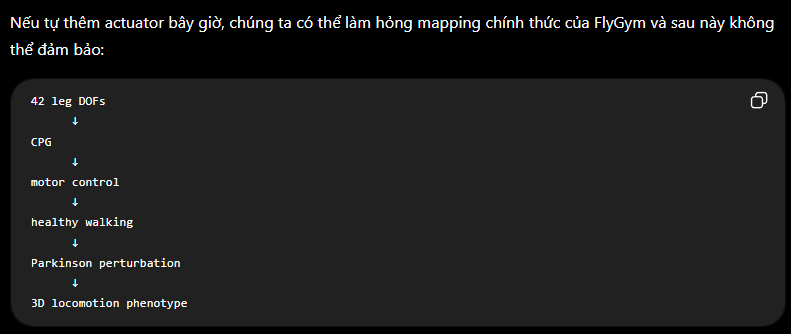

## SESSION 02 — BLOCK 8.1: TRACE ATTACHED FLY MJSPEC

In [22]:
# ============================================================
# SESSION 02 — BLOCK 8.1
# TRACE ATTACHED FLY MJSPEC
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 8.1")
print("TRACE ATTACHED FLY MJSPEC")
print("=" * 70)

import mujoco
import flygym
import re

# ------------------------------------------------------------
# 1. PRE-CHECK
# ------------------------------------------------------------

print("\n=== PRE-CHECK ===")

print("world:", type(world))
print("fly:", type(fly))
print("compiled_model:", type(compiled_model))

assert world is not None
assert fly is not None
assert compiled_model is not None

print("World: AVAILABLE ✅")
print("Fly: AVAILABLE ✅")
print("Compiled model: AVAILABLE ✅")


# ------------------------------------------------------------
# 2. WORLD MJSPEC XML
# ------------------------------------------------------------

print("\n=== WORLD MJSPEC XML ===")

world_xml = world.mjcf_root.to_xml()

print("XML length:", len(world_xml))

# Save diagnostic XML
xml_path = "/content/session02_block8_1_world.xml"

with open(xml_path, "w", encoding="utf-8") as f:
    f.write(world_xml)

print("XML saved:", xml_path)


# ------------------------------------------------------------
# 3. BODY TAG INSPECTION
# ------------------------------------------------------------

print("\n=== BODY TAG INSPECTION ===")

body_tags = re.findall(r'<body\b[^>]*name="([^"]+)"', world_xml)

print("Number of <body> tags:", len(body_tags))

for i, name in enumerate(body_tags[:80]):
    print(f"body[{i:02d}] = {name}")

if len(body_tags) > 1:
    print("\nMultiple body tags found in XML ✅")
else:
    print("\nOnly one body tag found ❌")


# ------------------------------------------------------------
# 4. JOINT TAG INSPECTION
# ------------------------------------------------------------

print("\n=== JOINT TAG INSPECTION ===")

joint_tags = re.findall(r'<joint\b[^>]*name="([^"]+)"', world_xml)

print("Number of <joint> tags:", len(joint_tags))

for i, name in enumerate(joint_tags[:80]):
    print(f"joint[{i:02d}] = {name}")


# ------------------------------------------------------------
# 5. ACTUATOR SECTION INSPECTION
# ------------------------------------------------------------

print("\n=== ACTUATOR XML INSPECTION ===")

actuator_match = re.search(
    r'<actuator>(.*?)</actuator>',
    world_xml,
    flags=re.DOTALL
)

if actuator_match:
    actuator_section = actuator_match.group(1)

    print("Actuator section FOUND ✅")
    print("Actuator XML length:", len(actuator_section))

    actuator_names = re.findall(
        r'name="([^"]+)"',
        actuator_section
    )

    print("Actuator names:", len(actuator_names))

    for i, name in enumerate(actuator_names[:80]):
        print(f"actuator[{i:02d}] = {name}")

else:
    print("Actuator section NOT FOUND ❌")


# ------------------------------------------------------------
# 6. SEARCH FOR LEG STRUCTURE
# ------------------------------------------------------------

print("\n=== LEG STRUCTURE SEARCH ===")

leg_keywords = [
    "lf_coxa",
    "lf_trochanterfemur",
    "lf_tibia",
    "lf_tarsus1",

    "lm_coxa",
    "lm_tibia",

    "lh_coxa",
    "lh_tibia",

    "rf_coxa",
    "rf_tibia",

    "rm_coxa",
    "rm_tibia",

    "rh_coxa",
    "rh_tibia",
]

for keyword in leg_keywords:
    count = world_xml.count(keyword)

    status = "FOUND ✅" if count > 0 else "NOT FOUND ❌"

    print(f"{keyword:25s}: {count:3d} occurrence(s) — {status}")


# ------------------------------------------------------------
# 7. COMPILED MODEL
# ------------------------------------------------------------

print("\n=== COMPILED MODEL ===")

print("nbody   :", compiled_model.nbody)
print("njnt    :", compiled_model.njnt)
print("nv      :", compiled_model.nv)
print("nq      :", compiled_model.nq)
print("nu      :", compiled_model.nu)
print("nsensor :", compiled_model.nsensor)


# ------------------------------------------------------------
# 8. COMPILED BODY NAMES
# ------------------------------------------------------------

print("\n=== COMPILED BODY NAMES ===")

for i in range(compiled_model.nbody):
    print(
        f"body[{i:02d}] = "
        f"{mujoco.mj_id2name(compiled_model, mujoco.mjtObj.mjOBJ_BODY, i)}"
    )


# ------------------------------------------------------------
# 9. COMPILED JOINT NAMES
# ------------------------------------------------------------

print("\n=== COMPILED JOINT NAMES ===")

for i in range(compiled_model.njnt):
    print(
        f"joint[{i:02d}] = "
        f"{mujoco.mj_id2name(compiled_model, mujoco.mjtObj.mjOBJ_JOINT, i)}"
    )


# ------------------------------------------------------------
# 10. COMPILED ACTUATORS
# ------------------------------------------------------------

print("\n=== COMPILED ACTUATORS ===")

for i in range(compiled_model.nu):
    print(
        f"actuator[{i:02d}] = "
        f"{mujoco.mj_id2name(compiled_model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)}"
    )

if compiled_model.nu == 0:
    print("NO ACTUATORS ❌")
else:
    print("Actuators detected ✅")


# ------------------------------------------------------------
# 11. FINAL DIAGNOSIS
# ------------------------------------------------------------

print("\n=== DIAGNOSTIC CONCLUSION ===")

if len(body_tags) > compiled_model.nbody:
    print(
        "WARNING: XML contains more body elements than compiled MjModel."
    )
    print(
        "This strongly suggests an MjSpec attachment/compilation issue."
    )

if compiled_model.nbody <= 2:
    print("Compiled model is still INCOMPLETE ❌")

if compiled_model.nu == 0:
    print("Actuator system is NOT present in compiled model ❌")

print("\nDo NOT modify the world after this block.")
print("Do NOT call world.add_fly() again.")
print("Do NOT reinstall FlyGym.")

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.1 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 8.1
TRACE ATTACHED FLY MJSPEC

=== PRE-CHECK ===
world: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
fly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
compiled_model: <class 'mujoco._structs.MjModel'>
World: AVAILABLE ✅
Fly: AVAILABLE ✅
Compiled model: AVAILABLE ✅

=== WORLD MJSPEC XML ===
XML length: 36598
XML saved: /content/session02_block8_1_world.xml

=== BODY TAG INSPECTION ===
Number of <body> tags: 1
body[00] = healthy_clean/c_thorax

Only one body tag found ❌

=== JOINT TAG INSPECTION ===
Number of <joint> tags: 1
joint[00] = healthy_clean

=== ACTUATOR XML INSPECTION ===
Actuator section NOT FOUND ❌

=== LEG STRUCTURE SEARCH ===
lf_coxa                  :   7 occurrence(s) — FOUND ✅
lf_trochanterfemur       :   7 occurrence(s) — FOUND ✅
lf_tibia                 :   7 occurrence(s) — FOUND ✅
lf_tarsus1               :   7 occurrence(s) — FOUND ✅
lm_coxa                  :   7 occurrence(s) — FOUND ✅
lm_tibia                 :   7 occu

## 8.2 — INSPECT FLY MJSPEC TRƯỚC ATTACH

In [23]:
# ============================================================
# SESSION 02 — BLOCK 8.2
# INSPECT NEUROMECHFLY MJSPEC BEFORE ATTACH
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 8.2")
print("INSPECT NEUROMECHFLY MJSPEC BEFORE ATTACH")
print("=" * 70)

import mujoco
import flygym
import re

from flygym.compose.fly.neuromechfly import NeuroMechFly


# ------------------------------------------------------------
# 1. CREATE COMPLETELY FRESH FLY
# ------------------------------------------------------------

print("\n=== CREATE FRESH FLY ===")

diagnostic_fly = NeuroMechFly(
    name="diagnostic_only"
)

print("Fly created successfully ✅")
print("Fly type :", type(diagnostic_fly))
print("Fly name :", diagnostic_fly.name)


# ------------------------------------------------------------
# 2. CHECK MJSPEC
# ------------------------------------------------------------

print("\n=== FLY MJSPEC ===")

fly_spec = diagnostic_fly.mjcf_root

print("MjSpec type :", type(fly_spec))
print("MjSpec available :", fly_spec is not None)


# ------------------------------------------------------------
# 3. CONVERT FLY SPEC TO XML
# ------------------------------------------------------------

print("\n=== GENERATE FLY XML ===")

try:
    fly_xml = fly_spec.to_xml()

    print("Fly XML generated successfully ✅")
    print("XML length:", len(fly_xml))

except Exception as e:
    print("Fly XML generation FAILED ❌")
    print("Error:", type(e).__name__)
    print("Message:", str(e))

    raise


# ------------------------------------------------------------
# 4. SAVE XML
# ------------------------------------------------------------

xml_path = "/content/session02_block8_2_fly.xml"

with open(xml_path, "w", encoding="utf-8") as f:
    f.write(fly_xml)

print("XML saved:", xml_path)


# ------------------------------------------------------------
# 5. BODY TAG INSPECTION
# ------------------------------------------------------------

print("\n=== BODY TAG INSPECTION ===")

body_matches = re.findall(
    r'<body\b[^>]*\bname="([^"]+)"',
    fly_xml
)

print("Number of body tags:", len(body_matches))

for i, name in enumerate(body_matches[:30]):
    print(f"body[{i:02d}] = {name}")

if len(body_matches) > 1:
    print("\nBody hierarchy exists in Fly MjSpec ✅")
else:
    print("\nWARNING: Only one body found ❌")


# ------------------------------------------------------------
# 6. JOINT TAG INSPECTION
# ------------------------------------------------------------

print("\n=== JOINT TAG INSPECTION ===")

joint_matches = re.findall(
    r'<joint\b[^>]*\bname="([^"]+)"',
    fly_xml
)

print("Number of joints:", len(joint_matches))

for i, name in enumerate(joint_matches[:30]):
    print(f"joint[{i:02d}] = {name}")


# ------------------------------------------------------------
# 7. ACTUATOR SECTION
# ------------------------------------------------------------

print("\n=== ACTUATOR INSPECTION ===")

actuator_section = re.search(
    r'<actuator\b.*?</actuator>',
    fly_xml,
    flags=re.DOTALL
)

if actuator_section:
    print("Actuator section FOUND ✅")

    actuator_xml = actuator_section.group(0)

    print("Actuator XML length:", len(actuator_xml))

    actuator_names = re.findall(
        r'\bname="([^"]+)"',
        actuator_xml
    )

    print("Actuator names found:", len(actuator_names))

    for i, name in enumerate(actuator_names[:30]):
        print(f"actuator[{i:02d}] = {name}")

else:
    print("Actuator section NOT FOUND ❌")


# ------------------------------------------------------------
# 8. LEG BODY SEARCH
# ------------------------------------------------------------

print("\n=== LEG STRUCTURE ===")

leg_terms = [
    "lf_coxa",
    "lf_trochanterfemur",
    "lf_tibia",
    "lf_tarsus1",
    "lm_coxa",
    "lm_tibia",
    "lh_coxa",
    "lh_tibia",
    "rf_coxa",
    "rf_tibia",
    "rm_coxa",
    "rm_tibia",
    "rh_coxa",
    "rh_tibia",
]

for term in leg_terms:

    count = fly_xml.count(term)

    status = "FOUND ✅" if count > 0 else "NOT FOUND ❌"

    print(
        f"{term:<25}: "
        f"{count:>3} occurrence(s) — {status}"
    )


# ------------------------------------------------------------
# 9. DIRECT MUJOCO COMPILE OF FLY ITSELF
# ------------------------------------------------------------

print("\n=== DIRECT FLY MJSPEC COMPILE ===")

try:

    fly_model = fly_spec.compile()

    print("Direct Fly compilation: SUCCESS ✅")

    print("\n=== FLY MODEL COUNTS ===")

    print("nbody    :", fly_model.nbody)
    print("njnt     :", fly_model.njnt)
    print("nv       :", fly_model.nv)
    print("nq       :", fly_model.nq)
    print("nu       :", fly_model.nu)
    print("nsensor  :", fly_model.nsensor)

    print("\n=== FLY MODEL BODY NAMES ===")

    for i in range(min(fly_model.nbody, 30)):
        name = mujoco.mj_id2name(
            fly_model,
            mujoco.mjtObj.mjOBJ_BODY,
            i
        )

        print(f"body[{i:02d}] = {name}")

    print("\n=== FLY MODEL JOINT NAMES ===")

    for i in range(min(fly_model.njnt, 30)):
        name = mujoco.mj_id2name(
            fly_model,
            mujoco.mjtObj.mjOBJ_JOINT,
            i
        )

        print(f"joint[{i:02d}] = {name}")

    print("\n=== FLY MODEL ACTUATOR NAMES ===")

    for i in range(min(fly_model.nu, 30)):
        name = mujoco.mj_id2name(
            fly_model,
            mujoco.mjtObj.mjOBJ_ACTUATOR,
            i
        )

        print(f"actuator[{i:02d}] = {name}")

except Exception as e:

    print("Direct Fly compilation FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))


# ------------------------------------------------------------
# 10. FINAL DIAGNOSTIC
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.2 COMPLETE")
print("=" * 70)

print("""
IMPORTANT:
This block did NOT create a world.
This block did NOT call world.add_fly().
This block did NOT modify the existing world.
This block did NOT reinstall FlyGym.

Purpose:
Determine whether NeuroMechFly itself contains
the complete body/joint/actuator hierarchy BEFORE
it is attached to FlatGroundWorld.
""")

SESSION 02 — BLOCK 8.2
INSPECT NEUROMECHFLY MJSPEC BEFORE ATTACH

=== CREATE FRESH FLY ===
Fly created successfully ✅
Fly type : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
Fly name : diagnostic_only

=== FLY MJSPEC ===
MjSpec type : <class 'mujoco._specs.MjSpec'>
MjSpec available : True

=== GENERATE FLY XML ===
Fly XML generated successfully ✅
XML length: 24333
XML saved: /content/session02_block8_2_fly.xml

=== BODY TAG INSPECTION ===
Number of body tags: 0


=== JOINT TAG INSPECTION ===
Number of joints: 0

=== ACTUATOR INSPECTION ===
Actuator section NOT FOUND ❌

=== LEG STRUCTURE ===
lf_coxa                  :   5 occurrence(s) — FOUND ✅
lf_trochanterfemur       :   5 occurrence(s) — FOUND ✅
lf_tibia                 :   5 occurrence(s) — FOUND ✅
lf_tarsus1               :   5 occurrence(s) — FOUND ✅
lm_coxa                  :   5 occurrence(s) — FOUND ✅
lm_tibia                 :   5 occurrence(s) — FOUND ✅
lh_coxa                  :   5 occurrence(s) — FOUND ✅
lh_tibi

## SESSION 02 — BLOCK 8.3: INSPECT MJSPEC STRUCTURE DIRECTLY

In [24]:
# ============================================================
# SESSION 02 — BLOCK 8.3
# DIRECT MJSPEC STRUCTURE INSPECTION
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 8.3")
print("DIRECT MJSPEC STRUCTURE INSPECTION")
print("=" * 70)

import inspect
import mujoco

from flygym.compose.fly.neuromechfly import NeuroMechFly


# ------------------------------------------------------------
# 1. CREATE FRESH FLY
# ------------------------------------------------------------

print("\n=== CREATE FRESH NEUROMECHFLY ===")

diagnostic_fly = NeuroMechFly(
    name="spec_inspection"
)

print("Fly created successfully ✅")
print("Fly type:", type(diagnostic_fly))
print("Fly name:", diagnostic_fly.name)


# ------------------------------------------------------------
# 2. GET MJSPEC
# ------------------------------------------------------------

spec = diagnostic_fly.mjcf_root

print("\n=== MJSPEC OBJECT ===")

print("Type:", type(spec))
print("Object:", spec)


# ------------------------------------------------------------
# 3. LIST MJSPEC ATTRIBUTES
# ------------------------------------------------------------

print("\n=== MJSPEC PUBLIC ATTRIBUTES ===")

try:

    attrs = [
        name
        for name in dir(spec)
        if not name.startswith("_")
    ]

    for name in attrs:
        print(name)

    print("\nTotal public attributes:", len(attrs))

except Exception as e:

    print("Attribute inspection FAILED ❌")
    print("Error:", type(e).__name__)
    print("Message:", str(e))


# ------------------------------------------------------------
# 4. CHECK COMMON MJSPEC COLLECTION APIs
# ------------------------------------------------------------

print("\n=== MJSPEC COLLECTION API CHECK ===")

collection_names = [
    "worldbody",
    "body",
    "joint",
    "actuator",
    "sensor",
    "tendon",
    "site",
    "geom",
    "equality",
    "contact",
    "keyframe",
    "asset",
]

for name in collection_names:

    print(f"\n--- {name} ---")

    try:

        obj = getattr(spec, name)

        print("Type:", type(obj))
        print("Value:", obj)

        if callable(obj):

            try:
                sig = inspect.signature(obj)
                print("Signature:", sig)
            except Exception:
                print("Signature: unavailable")

    except Exception as e:

        print("NOT AVAILABLE")
        print("Error:", type(e).__name__)
        print("Message:", str(e))


# ------------------------------------------------------------
# 5. WORLD BODY OBJECT
# ------------------------------------------------------------

print("\n=== WORLD BODY ===")

try:

    worldbody = spec.worldbody

    print("worldbody type:", type(worldbody))
    print("worldbody:", worldbody)

    print("\nworldbody attributes:")

    attrs = [
        x
        for x in dir(worldbody)
        if not x.startswith("_")
    ]

    for x in attrs[:100]:
        print(x)

except Exception as e:

    print("worldbody inspection FAILED ❌")
    print("Error:", type(e).__name__)
    print("Message:", str(e))


# ------------------------------------------------------------
# 6. TRY DIRECT BODY LOOKUP
# ------------------------------------------------------------

print("\n=== DIRECT BODY LOOKUP ===")

body_names = [
    "c_thorax",
    "c_head",
    "lf_coxa",
    "lf_tibia",
    "lm_coxa",
    "lh_coxa",
    "rf_coxa",
    "rm_coxa",
    "rh_coxa",
]

for name in body_names:

    try:

        result = spec.body(name)

        print(
            f"{name:<25} : FOUND ✅ | "
            f"type={type(result)} | "
            f"value={result}"
        )

    except Exception as e:

        print(
            f"{name:<25} : NOT FOUND ❌ | "
            f"{type(e).__name__}: {e}"
        )


# ------------------------------------------------------------
# 7. DIRECT JOINT LOOKUP
# ------------------------------------------------------------

print("\n=== DIRECT JOINT LOOKUP ===")

joint_names = [
    "lf_coxa",
    "lf_tibia",
    "lm_coxa",
    "lh_coxa",
    "rf_coxa",
    "rm_coxa",
    "rh_coxa",
]

for name in joint_names:

    try:

        result = spec.joint(name)

        print(
            f"{name:<25} : FOUND ✅ | "
            f"type={type(result)} | "
            f"value={result}"
        )

    except Exception as e:

        print(
            f"{name:<25} : NOT FOUND ❌ | "
            f"{type(e).__name__}: {e}"
        )


# ------------------------------------------------------------
# 8. DIRECT ACTUATOR LOOKUP TEST
# ------------------------------------------------------------

print("\n=== DIRECT ACTUATOR LOOKUP ===")

test_actuator_names = [
    "lf_coxa",
    "lf_coxa_actuator",
    "lf_coxa_motor",
]

for name in test_actuator_names:

    try:

        result = spec.actuator(name)

        print(
            f"{name:<30} : FOUND ✅ | "
            f"type={type(result)} | "
            f"value={result}"
        )

    except Exception as e:

        print(
            f"{name:<30} : NOT FOUND ❌ | "
            f"{type(e).__name__}: {e}"
        )


# ------------------------------------------------------------
# 9. SPEC XML PREVIEW
# ------------------------------------------------------------

print("\n=== XML PREVIEW ===")

try:

    xml = spec.to_xml()

    print("XML length:", len(xml))

    print("\n--- FIRST 3000 CHARACTERS ---")
    print(xml[:3000])

except Exception as e:

    print("XML generation FAILED ❌")
    print("Error:", type(e).__name__)
    print("Message:", str(e))


# ------------------------------------------------------------
# 10. DIRECT COMPILE
# ------------------------------------------------------------

print("\n=== DIRECT COMPILE ===")

try:

    model = spec.compile()

    print("Compile: SUCCESS ✅")

    print("\n=== MODEL COUNTS ===")

    print("nbody   :", model.nbody)
    print("njnt    :", model.njnt)
    print("nv      :", model.nv)
    print("nq      :", model.nq)
    print("nu      :", model.nu)
    print("nsensor :", model.nsensor)

except Exception as e:

    print("Compile FAILED ❌")
    print("Error:", type(e).__name__)
    print("Message:", str(e))


# ------------------------------------------------------------
# 11. FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.3 COMPLETE")
print("=" * 70)

print("""
IMPORTANT:

This block is diagnostic only.

NO:
- world.add_fly()
- world compilation
- CPG
- simulation
- GPU execution
- reinstall

Purpose:
Determine exactly how NeuroMechFly 2.1.0
stores its body/joint/actuator structure
inside MjSpec.
""")

SESSION 02 — BLOCK 8.3
DIRECT MJSPEC STRUCTURE INSPECTION

=== CREATE FRESH NEUROMECHFLY ===
Fly created successfully ✅
Fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
Fly name: spec_inspection

=== MJSPEC OBJECT ===
Type: <class 'mujoco._specs.MjSpec'>
Object: <mujoco._specs.MjSpec object at 0x7a4641a795f0>

=== MJSPEC PUBLIC ATTRIBUTES ===
activate_plugin
actuator
actuators
add_actuator
add_default
add_equality
add_exclude
add_flex
add_hfield
add_key
add_material
add_mesh
add_numeric
add_pair
add_plugin
add_sensor
add_skin
add_tendon
add_text
add_texture
add_tuple
assets
attach
bodies
body
camera
cameras
comment
compile
compiler
copy
copy_during_attach
default
delete
encode
equalities
equality
exclude
excludes
find_default
flex
flexes
frame
frames
from_file
from_string
from_zip
geom
geoms
hasImplicitPluginElem
hfield
hfields
joint
joints
key
keys
light
lights
material
materials
memory
mesh
meshdir
meshes
modelfiledir
modelname
nconmax
nemax
njmax
nkey
nstack
numeric


## SESSION 02 — BLOCK 8.4: TRAVERSE NEUROMECHFLY MJSPEC BODY TREE

In [25]:
# ============================================================
# SESSION 02 — BLOCK 8.4
# TRAVERSE NEUROMECHFLY MJSPEC BODY TREE
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 8.4")
print("TRAVERSE NEUROMECHFLY MJSPEC BODY TREE")
print("=" * 70)

# ------------------------------------------------------------
# PRE-CHECK
# ------------------------------------------------------------

print("\n=== PRE-CHECK ===")

assert "fly" in globals(), "fly variable is missing"
assert hasattr(fly, "mjcf_root"), "fly.mjcf_root is missing"

print("fly:", type(fly))
print("fly name:", fly.name)
print("fly.mjcf_root:", type(fly.mjcf_root))

# ------------------------------------------------------------
# WORLDBODY
# ------------------------------------------------------------

print("\n=== WORLDBODY ===")

worldbody = fly.mjcf_root.worldbody

print("worldbody type:", type(worldbody))
print("worldbody name:", getattr(worldbody, "name", None))

# ------------------------------------------------------------
# DIRECT CHILD BODY
# ------------------------------------------------------------

print("\n=== DIRECT CHILD BODIES ===")

try:
    bodies = worldbody.bodies

    print("worldbody.bodies type:", type(bodies))
    print("Number of direct bodies:", len(bodies))

    for i, body in enumerate(bodies):
        print(
            f"body[{i:02d}] "
            f"name={getattr(body, 'name', None)!r} "
            f"type={type(body)}"
        )

except Exception as e:
    print("Direct body inspection FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

# ------------------------------------------------------------
# FIRST BODY DETAILS
# ------------------------------------------------------------

print("\n=== FIRST BODY DETAILS ===")

try:
    first_body = worldbody.first_body

    print("first_body:", first_body)
    print("first_body type:", type(first_body))
    print("first_body name:", getattr(first_body, "name", None))

    print("\nFirst body attributes:")

    attrs = [
        "name",
        "bodies",
        "joints",
        "geoms",
        "sites",
        "frames",
        "parent",
        "pos",
        "quat",
    ]

    for attr in attrs:
        try:
            value = getattr(first_body, attr)
            print(f"{attr:12s}: {type(value)} -> {value}")
        except Exception as e:
            print(f"{attr:12s}: ERROR -> {type(e).__name__}: {e}")

except Exception as e:
    print("First body inspection FAILED ❌")
    print("Error:", e)

# ------------------------------------------------------------
# RECURSIVE BODY TREE
# ------------------------------------------------------------

print("\n=== RECURSIVE BODY TREE ===")

visited = set()

def inspect_body(body, depth=0, max_depth=10):

    if body is None:
        return

    if depth > max_depth:
        print("  " * depth + "... max depth reached")
        return

    body_id = id(body)

    if body_id in visited:
        print("  " * depth + "[already visited]")
        return

    visited.add(body_id)

    name = getattr(body, "name", None)

    print(
        "  " * depth
        + f"BODY: {name!r}"
    )

    # -------------------------
    # JOINTS
    # -------------------------

    try:
        joints = body.joints

        print(
            "  " * (depth + 1)
            + f"joints: {len(joints)}"
        )

        for j, joint in enumerate(joints):

            print(
                "  " * (depth + 2)
                + f"JOINT[{j}]: "
                f"name={getattr(joint, 'name', None)!r}"
            )

    except Exception as e:

        print(
            "  " * (depth + 1)
            + f"joints: ERROR {type(e).__name__}: {e}"
        )

    # -------------------------
    # GEOMS
    # -------------------------

    try:
        geoms = body.geoms

        print(
            "  " * (depth + 1)
            + f"geoms: {len(geoms)}"
        )

    except Exception as e:

        print(
            "  " * (depth + 1)
            + f"geoms: ERROR {type(e).__name__}: {e}"
        )

    # -------------------------
    # CHILD BODIES
    # -------------------------

    try:
        children = body.bodies

        print(
            "  " * (depth + 1)
            + f"children: {len(children)}"
        )

        for child in children:
            inspect_body(
                child,
                depth=depth + 2,
                max_depth=max_depth,
            )

    except Exception as e:

        print(
            "  " * (depth + 1)
            + f"children: ERROR {type(e).__name__}: {e}"
        )


try:

    root_children = worldbody.bodies

    print(
        "Root child count:",
        len(root_children)
    )

    for body in root_children:

        inspect_body(
            body,
            depth=0,
            max_depth=12
        )

except Exception as e:

    print("Recursive traversal FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

# ------------------------------------------------------------
# SEARCH IMPORTANT BODY NAMES
# ------------------------------------------------------------

print("\n=== TARGET BODY SEARCH ===")

target_names = [
    "c_thorax",
    "c_head",
    "lf_coxa",
    "lf_trochanterfemur",
    "lf_tibia",
    "lm_coxa",
    "lh_coxa",
    "rf_coxa",
    "rm_coxa",
    "rh_coxa",
]

found = {}

def collect_bodies(body):

    if body is None:
        return

    name = getattr(body, "name", None)

    if name in target_names:
        found[name] = body

    try:
        for child in body.bodies:
            collect_bodies(child)
    except Exception:
        pass


try:

    for body in worldbody.bodies:
        collect_bodies(body)

    for name in target_names:

        if name in found:

            body = found[name]

            print(
                f"{name:25s}: FOUND ✅ "
                f"type={type(body)}"
            )

            try:
                print(
                    f"{'':25s} joints={len(body.joints)}"
                )
            except:
                pass

            try:
                print(
                    f"{'':25s} geoms={len(body.geoms)}"
                )
            except:
                pass

            try:
                print(
                    f"{'':25s} children={len(body.bodies)}"
                )
            except:
                pass

        else:

            print(
                f"{name:25s}: NOT FOUND ❌"
            )

except Exception as e:

    print("\nTarget search FAILED ❌")
    print(type(e).__name__, e)

# ------------------------------------------------------------
# ACTUATOR COLLECTION API
# ------------------------------------------------------------

print("\n=== ACTUATOR COLLECTION API ===")

try:

    actuator_method = fly.mjcf_root.actuator

    print("actuator attribute:", actuator_method)
    print("type:", type(actuator_method))

    for test_name in [
        "lf_coxa",
        "lf_coxa_actuator",
        "lf_coxa_motor",
    ]:

        try:

            result = actuator_method(test_name)

            print(
                f"actuator({test_name!r}) ->",
                result
            )

        except Exception as e:

            print(
                f"actuator({test_name!r}) -> "
                f"{type(e).__name__}: {e}"
            )

except Exception as e:

    print(
        "Actuator API inspection FAILED ❌",
        type(e).__name__,
        e
    )

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.4 COMPLETE")
print("=" * 70)

print("""
IMPORTANT:

This block is diagnostic only.

NO:
- world.add_fly()
- world compilation
- CPG
- simulation
- GPU execution
- reinstall

Purpose:
Determine whether the NeuroMechFly hierarchy exists
inside the MjSpec object tree and identify where
joints/actuators are actually stored.
""")

SESSION 02 — BLOCK 8.4
TRAVERSE NEUROMECHFLY MJSPEC BODY TREE

=== PRE-CHECK ===
fly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly name: healthy_clean
fly.mjcf_root: <class 'mujoco._specs.MjSpec'>

=== WORLDBODY ===
worldbody type: <class 'mujoco._specs.MjsBody'>
worldbody name: world

=== DIRECT CHILD BODIES ===
worldbody.bodies type: <class 'list'>
Number of direct bodies: 1
body[00] name='healthy_clean/c_thorax' type=<class 'mujoco._specs.MjsBody'>

=== FIRST BODY DETAILS ===
first_body: <bound method pybind11_detail_function_record_v1_system_libcpp_abi1.first_body of <mujoco._specs.MjsBody object at 0x7a4641a3e730>>
first_body type: <class 'method'>
first_body name: None

First body attributes:
name        : ERROR -> AttributeError: 'builtin_function_or_method' object has no attribute 'name'
bodies      : ERROR -> AttributeError: 'builtin_function_or_method' object has no attribute 'bodies'
joints      : ERROR -> AttributeError: 'builtin_function_or_method' object has

## 🛑 Block 8.5 — CHỈ INSPECT BODY NAVIGATION API

In [26]:
# ============================================================
# SESSION 02 — BLOCK 8.5
# INSPECT MJSBODY NAVIGATION API
# ============================================================

print("=" * 70)
print("SESSION 02 — BLOCK 8.5")
print("INSPECT MJSBODY NAVIGATION API")
print("=" * 70)

# ------------------------------------------------------------
# PRE-CHECK
# ------------------------------------------------------------

print("\n=== PRE-CHECK ===")

print("fly:", type(fly))
print("fly name:", fly.name)
print("fly.mjcf_root:", type(fly.mjcf_root))

worldbody = fly.mjcf_root.worldbody

print("worldbody:", type(worldbody))
print("worldbody name:", getattr(worldbody, "name", None))

# ------------------------------------------------------------
# WORLD BODY METHODS
# ------------------------------------------------------------

print("\n=== WORLD BODY NAVIGATION METHODS ===")

navigation_methods = [
    "first_body",
    "next_body",
    "find_child",
    "find_all",
    "bodies",
    "joints",
    "geoms",
]

for attr_name in navigation_methods:

    try:

        attr = getattr(worldbody, attr_name)

        print(
            f"{attr_name:15s}: "
            f"type={type(attr)}"
        )

        if callable(attr):

            print(
                f"{'':15s} callable=YES ✅"
            )

        else:

            print(
                f"{'':15s} callable=NO"
            )

    except Exception as e:

        print(
            f"{attr_name:15s}: "
            f"ERROR {type(e).__name__}: {e}"
        )

# ------------------------------------------------------------
# FIRST BODY — CALL METHOD
# ------------------------------------------------------------

print("\n=== FIRST BODY METHOD CALL ===")

try:

    first_body = worldbody.first_body()

    print("first_body():", first_body)
    print("type:", type(first_body))

    if first_body is not None:

        print(
            "name:",
            getattr(first_body, "name", None)
        )

except Exception as e:

    print(
        "first_body() FAILED ❌"
    )

    print(
        "Error type:",
        type(e).__name__
    )

    print(
        "Error:",
        e
    )

# ------------------------------------------------------------
# NEXT BODY TRAVERSAL
# ------------------------------------------------------------

print("\n=== NEXT BODY TRAVERSAL ===")

try:

    body = worldbody.first_body()

    index = 0

    while body is not None and index < 200:

        print(
            f"body[{index:03d}] "
            f"name={getattr(body, 'name', None)!r}"
        )

        try:

            body = body.next_body()

        except Exception as e:

            print(
                "next_body() FAILED ❌"
            )

            print(
                "Error:",
                type(e).__name__,
                e
            )

            break

        index += 1

    print(
        "Total traversed:",
        index
    )

except Exception as e:

    print(
        "Traversal FAILED ❌"
    )

    print(
        "Error:",
        type(e).__name__,
        e
    )

# ------------------------------------------------------------
# FIND CHILD TEST
# ------------------------------------------------------------

print("\n=== FIND CHILD TEST ===")

target_names = [
    "c_thorax",
    "c_head",
    "lf_coxa",
    "lf_trochanterfemur",
    "lf_tibia",
    "lm_coxa",
    "lh_coxa",
    "rf_coxa",
    "rm_coxa",
    "rh_coxa",
]

for name in target_names:

    try:

        result = worldbody.find_child(name)

        print(
            f"find_child({name!r}) -> "
            f"{result}"
        )

        if result is not None:

            print(
                f"{'':25s}"
                f"type={type(result)} "
                f"name={getattr(result, 'name', None)!r}"
            )

    except Exception as e:

        print(
            f"find_child({name!r}) -> "
            f"{type(e).__name__}: {e}"
        )

# ------------------------------------------------------------
# FIND ALL TEST
# ------------------------------------------------------------

print("\n=== FIND ALL TEST ===")

for name in [
    "c_thorax",
    "c_head",
    "lf_coxa",
    "lf_tibia",
]:

    try:

        result = worldbody.find_all(name)

        print(
            f"find_all({name!r}) ->",
            result
        )

        try:

            print(
                f"{'':20s}"
                f"type={type(result)} "
                f"len={len(result)}"
            )

        except Exception:

            pass

    except Exception as e:

        print(
            f"find_all({name!r}) -> "
            f"{type(e).__name__}: {e}"
        )

# ------------------------------------------------------------
# DIRECT BODY LOOKUP THROUGH MJSPEC
# ------------------------------------------------------------

print("\n=== MJSPEC BODY LOOKUP ===")

for name in [
    "c_thorax",
    "c_head",
    "lf_coxa",
    "lf_tibia",
    "lm_coxa",
    "lh_coxa",
    "rf_coxa",
    "rm_coxa",
    "rh_coxa",
]:

    try:

        result = fly.mjcf_root.body(name)

        print(
            f"mjcf_root.body({name!r}) ->",
            result
        )

        if result is not None:

            print(
                f"{'':25s}"
                f"type={type(result)} "
                f"name={getattr(result, 'name', None)!r}"
            )

    except Exception as e:

        print(
            f"mjcf_root.body({name!r}) -> "
            f"{type(e).__name__}: {e}"
        )

# ------------------------------------------------------------
# THORAX CHILD SEARCH
# ------------------------------------------------------------

print("\n=== THORAX CHILD SEARCH ===")

try:

    thorax = fly.mjcf_root.body("c_thorax")

    print("thorax:", thorax)
    print("thorax type:", type(thorax))

    if thorax is not None:

        try:

            print(
                "thorax.bodies:",
                thorax.bodies
            )

            print(
                "thorax.bodies length:",
                len(thorax.bodies)
            )

            for i, child in enumerate(thorax.bodies):

                print(
                    f"child[{i:03d}] "
                    f"name={getattr(child, 'name', None)!r}"
                )

        except Exception as e:

            print(
                "thorax.bodies FAILED:",
                type(e).__name__,
                e
            )

        try:

            child = thorax.first_body()

            index = 0

            while child is not None and index < 200:

                print(
                    f"thorax traversal[{index:03d}] "
                    f"name={getattr(child, 'name', None)!r}"
                )

                child = child.next_body()
                index += 1

        except Exception as e:

            print(
                "thorax first/next traversal FAILED:",
                type(e).__name__,
                e
            )

except Exception as e:

    print(
        "Thorax lookup FAILED ❌",
        type(e).__name__,
        e
    )

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.5 COMPLETE")
print("=" * 70)

print("""
IMPORTANT:

Diagnostic only.

DO NOT:
- create a new world
- create a new fly
- call world.add_fly()
- compile the world
- run simulation
- install/reinstall FlyGym

Purpose:

Determine whether the missing body hierarchy is actually
accessible through MuJoCo MjsBody navigation APIs such as:

- first_body()
- next_body()
- find_child()
- find_all()
- body()

This will tell us whether the problem is:

A. only our traversal method,

B. MjSpec body hierarchy construction,

or

C. the FlyGym 2.1.0 -> MuJoCo 3.x compatibility layer.
""")

SESSION 02 — BLOCK 8.5
INSPECT MJSBODY NAVIGATION API

=== PRE-CHECK ===
fly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly name: healthy_clean
fly.mjcf_root: <class 'mujoco._specs.MjSpec'>
worldbody: <class 'mujoco._specs.MjsBody'>
worldbody name: world

=== WORLD BODY NAVIGATION METHODS ===
first_body     : type=<class 'method'>
                callable=YES ✅
next_body      : type=<class 'method'>
                callable=YES ✅
find_child     : type=<class 'method'>
                callable=YES ✅
find_all       : type=<class 'method'>
                callable=YES ✅
bodies         : type=<class 'list'>
                callable=NO
joints         : type=<class 'list'>
                callable=NO
geoms          : type=<class 'list'>
                callable=NO

=== FIRST BODY METHOD CALL ===
first_body(): <mujoco._specs.MjsBody object at 0x7a4641a3e1b0>
type: <class 'mujoco._specs.MjsBody'>
name: healthy_clean/c_thorax

=== NEXT BODY TRAVERSAL ===
body[000] name='healthy_cle

## Ta có bằng chứng:

NeuroMechFly tạo được MjSpec.

XML của Fly có chứa các tên như lf_coxa, lf_tibia, lm_coxa...

Nhưng khi compile trực tiếp fly.mjcf_root, MuJoCo chỉ thấy:

- nbody = 1
- njnt = 0
- nu = 0
Trong MjsBody:
- chỉ có một body trực tiếp: healthy_clean/c_thorax
- body này có 69 geoms
- chỉ có 1 joint là free joint healthy_clean
- children = 0

## BLOCK 8.5 — TRACE SOURCE

In [27]:
# ======================================================================
# SESSION 02 — BLOCK 8.5
# TRACE NeuroMechFly -> BaseFly -> MjSpec CONSTRUCTION
# ======================================================================

import inspect
import flygym

from flygym.compose.fly.neuromechfly import NeuroMechFly
from flygym.compose.fly.base_fly import BaseFly

print("=" * 70)
print("SESSION 02 — BLOCK 8.5")
print("TRACE SOURCE: NeuroMechFly -> BaseFly -> MjSpec")
print("=" * 70)


# ----------------------------------------------------------------------
# 1. CURRENT OBJECT STATE
# ----------------------------------------------------------------------

print("\n=== CURRENT OBJECT STATE ===")

print("fly:", type(fly))
print("fly name:", getattr(fly, "name", None))
print("fly.mjcf_root:", type(fly.mjcf_root))

print("world:", type(world))
print("compiled_model:", type(compiled_model))


# ----------------------------------------------------------------------
# 2. NEUROMECHFLY CLASS SOURCE
# ----------------------------------------------------------------------

print("\n=== NEUROMECHFLY CLASS ===")

print("Class:")
print(NeuroMechFly)

print("\nModule:")
print(NeuroMechFly.__module__)

try:
    nmf_source = inspect.getsource(NeuroMechFly)

    print("\nNeuroMechFly source length:", len(nmf_source))

    print("\n--- NeuroMechFly SOURCE ---")
    print(nmf_source)

except Exception as e:
    print("Could not retrieve NeuroMechFly source")
    print("Error:", type(e).__name__, e)


# ----------------------------------------------------------------------
# 3. BASEFLY CLASS SOURCE
# ----------------------------------------------------------------------

print("\n=== BASEFLY CLASS ===")

print("Class:")
print(BaseFly)

print("\nModule:")
print(BaseFly.__module__)

try:
    base_source = inspect.getsource(BaseFly)

    print("\nBaseFly source length:", len(base_source))

    print("\n--- BaseFly SOURCE ---")
    print(base_source)

except Exception as e:
    print("Could not retrieve BaseFly source")
    print("Error:", type(e).__name__, e)


# ----------------------------------------------------------------------
# 4. CONSTRUCTOR SOURCE
# ----------------------------------------------------------------------

print("\n=== CONSTRUCTOR SOURCE ===")

try:
    nmf_init = inspect.getsource(NeuroMechFly.__init__)

    print("\n--- NeuroMechFly.__init__ ---")
    print(nmf_init)

except Exception as e:
    print("NeuroMechFly.__init__ source unavailable")
    print("Error:", type(e).__name__, e)


try:
    base_init = inspect.getsource(BaseFly.__init__)

    print("\n--- BaseFly.__init__ ---")
    print(base_init)

except Exception as e:
    print("BaseFly.__init__ source unavailable")
    print("Error:", type(e).__name__, e)


# ----------------------------------------------------------------------
# 5. SEARCH FOR MJCF / MJSPEC CONSTRUCTION
# ----------------------------------------------------------------------

print("\n=== MJCF / MJSPEC SOURCE SEARCH ===")

keywords = [
    "MjSpec",
    "mjcf_root",
    "worldbody",
    "add_body",
    "add_joint",
    "add_actuator",
    "actuator",
    "attach",
    "from_xml",
    "from_string",
    "from_file",
    "rigging",
    "rigging_config",
]

print("\nSearching BaseFly source:")

try:
    for keyword in keywords:
        matches = [
            line for line in base_source.splitlines()
            if keyword.lower() in line.lower()
        ]

        print(f"\n[{keyword}] -> {len(matches)} match(es)")

        for line in matches[:20]:
            print("   ", line.strip())

except Exception as e:
    print("BaseFly source search failed:", type(e).__name__, e)


print("\nSearching NeuroMechFly source:")

try:
    for keyword in keywords:
        matches = [
            line for line in nmf_source.splitlines()
            if keyword.lower() in line.lower()
        ]

        print(f"\n[{keyword}] -> {len(matches)} match(es)")

        for line in matches[:20]:
            print("   ", line.strip())

except Exception as e:
    print("NeuroMechFly source search failed:", type(e).__name__, e)


# ----------------------------------------------------------------------
# 6. INSPECT INSTANCE ATTRIBUTES
# ----------------------------------------------------------------------

print("\n=== FLY INSTANCE ATTRIBUTES ===")

try:
    fly_attrs = sorted([
        x for x in dir(fly)
        if not x.startswith("__")
    ])

    print("Total public-ish attributes:", len(fly_attrs))

    for attr in fly_attrs:
        if any(
            key in attr.lower()
            for key in [
                "mjcf",
                "rig",
                "body",
                "joint",
                "actuator",
                "motor",
                "mesh",
                "segment",
                "config",
                "model",
            ]
        ):
            print(attr)

except Exception as e:
    print("Instance attribute inspection failed:")
    print(type(e).__name__, e)


# ----------------------------------------------------------------------
# 7. INSPECT IMPORTANT FLY ATTRIBUTES
# ----------------------------------------------------------------------

print("\n=== IMPORTANT FLY ATTRIBUTES ===")

important_attrs = [
    "mjcf_root",
    "rigging_config_path",
    "mesh_basedir",
    "mujoco_globals_path",
    "root_segment",
    "mirror_left2right",
    "mesh_type",
    "geom_fitting_option",
    "vision_config_path",
]

for attr in important_attrs:

    try:
        value = getattr(fly, attr)

        print(f"{attr:25s}: {value}")

    except Exception as e:

        print(
            f"{attr:25s}: ERROR -> "
            f"{type(e).__name__}: {e}"
        )


# ----------------------------------------------------------------------
# 8. MJSPEC TOP LEVEL STATE
# ----------------------------------------------------------------------

print("\n=== MJSPEC TOP LEVEL STATE ===")

spec = fly.mjcf_root

print("MjSpec:", spec)

for attr in [
    "worldbody",
    "bodies",
    "joints",
    "actuators",
    "sensors",
    "assets",
    "keys",
    "option",
]:

    try:

        value = getattr(spec, attr)

        print(
            f"{attr:15s}: "
            f"type={type(value)}"
        )

        if isinstance(value, list):
            print(
                f"                 length={len(value)}"
            )

    except Exception as e:

        print(
            f"{attr:15s}: "
            f"ERROR -> {type(e).__name__}: {e}"
        )


# ----------------------------------------------------------------------
# 9. WORLDBODY DIRECT CHILDREN
# ----------------------------------------------------------------------

print("\n=== WORLDBODY DIRECT CHILDREN ===")

try:

    wb = spec.worldbody

    print("worldbody:", wb)
    print("worldbody name:", wb.name)

    print("Direct children:", len(wb.bodies))

    for i, body in enumerate(wb.bodies):

        print(
            f"body[{i:03d}] "
            f"name={body.name!r}"
        )

        print(
            f"    joints : {len(body.joints)}"
        )

        print(
            f"    geoms  : {len(body.geoms)}"
        )

        print(
            f"    bodies : {len(body.bodies)}"
        )

except Exception as e:

    print(
        "Worldbody inspection failed:",
        type(e).__name__,
        e
    )


# ----------------------------------------------------------------------
# 10. RECURSIVE TREE USING .bodies LIST
# ----------------------------------------------------------------------

print("\n=== RECURSIVE BODY TREE ===")

def walk_body(body, depth=0, max_depth=20):

    indent = "  " * depth

    print(
        f"{indent}BODY: {body.name!r}"
    )

    print(
        f"{indent}  joints={len(body.joints)} "
        f"geoms={len(body.geoms)} "
        f"children={len(body.bodies)}"
    )

    if depth >= max_depth:
        return

    for child in body.bodies:
        walk_body(
            child,
            depth=depth + 1,
            max_depth=max_depth
        )


try:

    for root_body in spec.worldbody.bodies:
        walk_body(root_body)

except Exception as e:

    print(
        "Recursive traversal failed:",
        type(e).__name__,
        e
    )


# ----------------------------------------------------------------------
# 11. ACTUATOR COLLECTION
# ----------------------------------------------------------------------

print("\n=== ACTUATOR COLLECTION ===")

try:

    print("spec.actuators:", spec.actuators)
    print("type:", type(spec.actuators))

    if isinstance(spec.actuators, list):

        print(
            "Number of actuators:",
            len(spec.actuators)
        )

        for i, actuator in enumerate(spec.actuators[:50]):

            print(
                f"actuator[{i:03d}] "
                f"name={getattr(actuator, 'name', None)!r}"
            )

except Exception as e:

    print(
        "Actuator collection inspection failed:",
        type(e).__name__,
        e
    )


# ----------------------------------------------------------------------
# 12. XML STRUCTURE COUNTS
# ----------------------------------------------------------------------

print("\n=== XML STRUCTURE COUNTS ===")

try:

    xml = spec.to_xml()

    print("XML length:", len(xml))

    import re

    print(
        "body tags:",
        len(re.findall(r"<body\b", xml))
    )

    print(
        "joint tags:",
        len(re.findall(r"<joint\b", xml))
    )

    print(
        "motor tags:",
        len(re.findall(r"<motor\b", xml))
    )

    print(
        "position tags:",
        len(re.findall(r"<position\b", xml))
    )

    print(
        "velocity tags:",
        len(re.findall(r"<velocity\b", xml))
    )

    print(
        "general actuator tags:",
        len(re.findall(r"<general\b", xml))
    )

    print(
        "actuator section:",
        "<actuator>" in xml
    )

    # Save for later inspection
    path = "/content/session02_block8_5_fly.xml"

    with open(path, "w", encoding="utf-8") as f:
        f.write(xml)

    print("XML saved:", path)

except Exception as e:

    print(
        "XML analysis failed:",
        type(e).__name__,
        e
    )


# ----------------------------------------------------------------------
# 13. SEARCH RIGGING CONFIGURATION
# ----------------------------------------------------------------------

print("\n=== RIGGING CONFIGURATION ===")

try:

    print(
        "rigging_config_path:",
        fly.rigging_config_path
    )

    import os

    exists = os.path.exists(
        fly.rigging_config_path
    )

    print(
        "Rigging file exists:",
        exists
    )

except Exception as e:

    print(
        "Rigging config inspection failed:",
        type(e).__name__,
        e
    )


# ----------------------------------------------------------------------
# 14. FINAL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.5 COMPLETE")
print("=" * 70)

print("""
IMPORTANT:

Diagnostic only.

NO:
- world.add_fly()
- world compilation
- CPG
- simulation
- GPU execution
- reinstall

Purpose:

Trace exactly where NeuroMechFly constructs:

1. body hierarchy
2. joints
3. actuators
4. MjSpec
5. rigging configuration

The output of this block determines the next repair step.
""")

SESSION 02 — BLOCK 8.5
TRACE SOURCE: NeuroMechFly -> BaseFly -> MjSpec

=== CURRENT OBJECT STATE ===
fly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly name: healthy_clean
fly.mjcf_root: <class 'mujoco._specs.MjSpec'>
world: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
compiled_model: <class 'mujoco._structs.MjModel'>

=== NEUROMECHFLY CLASS ===
Class:
<class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

Module:
flygym.compose.fly.neuromechfly

NeuroMechFly source length: 3850

--- NeuroMechFly SOURCE ---
class NeuroMechFly(BaseFly):
    """The NeuroMechFly body model for *Drosophila melanogaster*.

    NeuroMechFly is derived from a micro-CT scan of a real fly. It is the
    default body model in FlyGym and supports all locomotion, sensorimotor,
    and vision experiments. For an alternative anatomically detailed model
    with wing and abdomen degrees of freedom, see `FlyBody`.

    Both `NeuroMechFly` and `FlyBody` inherit from `BaseFly` and expose the


## SESSION 02 — BLOCK 8.6

### Mục tiêu block này là trả lời một câu duy nhất:

`full_skeleton.iter_jointdofs(c_thorax)` có thực sự sinh ra các JointDOF của ruồi hay không?

In [28]:
# ================================================================
# SESSION 02 — BLOCK 8.6
# DIAGNOSE SKELETON -> JOINTDOF -> BODY EXPANSION
# ================================================================

import inspect
import flygym
from flygym.compose.fly.neuromechfly import NeuroMechFly

print("=" * 70)
print("SESSION 02 — BLOCK 8.6")
print("DIAGNOSE SKELETON -> JOINTDOF -> BODY EXPANSION")
print("=" * 70)

# ------------------------------------------------
# 1. CURRENT FLY
# ------------------------------------------------

print("\n=== CURRENT FLY ===")

print("fly class :", type(fly))
print("fly name  :", fly.name)
print("root     :", fly.root_segment)
print("root name:", fly.root_segment.name)

# ------------------------------------------------
# 2. BASE SKELETON CONSTRUCTION
# ------------------------------------------------

print("\n=== BASE SKELETON ===")

try:
    skeleton = fly._get_base_skeleton()

    print("skeleton type:", type(skeleton))
    print("skeleton repr:", skeleton)

except Exception as e:
    print("FAILED creating skeleton ❌")
    print(type(e).__name__, e)
    skeleton = None

# ------------------------------------------------
# 3. SKELETON PUBLIC-ish ATTRIBUTES
# ------------------------------------------------

if skeleton is not None:

    print("\n=== SKELETON ATTRIBUTES ===")

    attrs = [
        "joint_preset",
        "axis_order",
        "joints",
        "jointdofs",
        "parent",
        "children",
    ]

    for attr in attrs:
        try:
            value = getattr(skeleton, attr)
            print(f"{attr:15s}: {type(value)} -> {value}")
        except Exception as e:
            print(f"{attr:15s}: ERROR -> {type(e).__name__}: {e}")

# ------------------------------------------------
# 4. JOINT PRESET CLASS
# ------------------------------------------------

print("\n=== JOINT PRESET ===")

try:
    JP = fly._all_possible_joint_preset()

    print("fly._all_possible_joint_preset():")
    print("type :", type(JP))
    print("value:", JP)

except Exception as e:
    print("Joint preset FAILED ❌")
    print(type(e).__name__, e)

# ------------------------------------------------
# 5. INSPECT SKELETON METHODS
# ------------------------------------------------

if skeleton is not None:

    print("\n=== SKELETON METHODS ===")

    for method_name in [
        "iter_jointdofs",
        "iter_joints",
        "get_jointdofs",
        "get_joints",
    ]:

        if hasattr(skeleton, method_name):

            try:
                method = getattr(skeleton, method_name)

                print(
                    f"{method_name:20s}: "
                    f"type={type(method)} "
                    f"callable={callable(method)}"
                )

                try:
                    print(
                        " " * 22 +
                        "signature:",
                        inspect.signature(method)
                    )
                except Exception:
                    pass

            except Exception as e:
                print(
                    f"{method_name:20s}: "
                    f"ERROR -> {type(e).__name__}: {e}"
                )

# ------------------------------------------------
# 6. CRITICAL TEST
# ------------------------------------------------

print("\n=== CRITICAL: ITERATE JOINTDOFS FROM ROOT ===")

jointdofs = []

if skeleton is not None:

    try:
        result = skeleton.iter_jointdofs(fly.root_segment)

        print("iter_jointdofs result type:", type(result))
        print("callable:", callable(result))

        for i, jd in enumerate(result):

            jointdofs.append(jd)

            print(f"\nJOINTDOF[{i:03d}]")
            print("  type :", type(jd))
            print("  repr :", jd)

            for attr in [
                "name",
                "parent",
                "child",
                "axis",
            ]:
                try:
                    print(
                        f"  {attr:7s}:",
                        getattr(jd, attr)
                    )
                except Exception as e:
                    print(
                        f"  {attr:7s}: "
                        f"ERROR -> {type(e).__name__}: {e}"
                    )

        print("\nTOTAL JOINTDOFS:", len(jointdofs))

    except Exception as e:

        print("iter_jointdofs FAILED ❌")
        print(type(e).__name__, e)

# ------------------------------------------------
# 7. PITCH FILTER TEST
# ------------------------------------------------

print("\n=== PITCH FILTER TEST ===")

if jointdofs:

    pitch_count = 0
    non_pitch_count = 0

    for jd in jointdofs:

        try:
            is_pitch = fly._is_pitch(jd)

            print(
                f"{jd.name:35s} "
                f"axis={jd.axis} "
                f"is_pitch={is_pitch}"
            )

            if is_pitch:
                pitch_count += 1
            else:
                non_pitch_count += 1

        except Exception as e:

            print(
                "ERROR:",
                jd,
                type(e).__name__,
                e
            )

    print("\nPITCH DOFs    :", pitch_count)
    print("NON-PITCH DOFs:", non_pitch_count)

else:

    print("NO JOINTDOFS GENERATED ❌")

# ------------------------------------------------
# 8. BODY SEGMENT MAP
# ------------------------------------------------

print("\n=== CURRENT BODY SEGMENT MAP ===")

try:

    print(
        "bodyseg_to_mjcfbody type:",
        type(fly.bodyseg_to_mjcfbody)
    )

    print(
        "number of entries:",
        len(fly.bodyseg_to_mjcfbody)
    )

    for i, (segment, body) in enumerate(
        fly.bodyseg_to_mjcfbody.items()
    ):

        print(
            f"[{i:03d}] "
            f"segment={segment!r} "
            f"name={segment.name!r} "
            f"body={body!r}"
        )

except Exception as e:

    print(
        "BODY MAP FAILED ❌",
        type(e).__name__,
        e
    )

# ------------------------------------------------
# 9. GEOMETRY MAP
# ------------------------------------------------

print("\n=== CURRENT GEOMETRY MAP ===")

try:

    print(
        "number of body segments:",
        len(fly.bodyseg_to_mjcfgeom)
    )

    for i, (segment, geoms) in enumerate(
        fly.bodyseg_to_mjcfgeom.items()
    ):

        print(
            f"[{i:03d}] "
            f"{segment.name:35s} "
            f"geoms={len(geoms)}"
        )

except Exception as e:

    print(
        "GEOM MAP FAILED ❌",
        type(e).__name__,
        e
    )

# ------------------------------------------------
# 10. JOINT MAP
# ------------------------------------------------

print("\n=== CURRENT JOINT MAP ===")

try:

    print(
        "jointdof_to_mjcfjoint:",
        type(fly.jointdof_to_mjcfjoint)
    )

    print(
        "number of joints:",
        len(fly.jointdof_to_mjcfjoint)
    )

    for i, (jd, joint) in enumerate(
        fly.jointdof_to_mjcfjoint.items()
    ):

        print(
            f"[{i:03d}] "
            f"JointDOF={jd} "
            f"MJJoint={joint}"
        )

except Exception as e:

    print(
        "JOINT MAP FAILED ❌",
        type(e).__name__,
        e
    )

# ------------------------------------------------
# 11. ACTUATOR MAP
# ------------------------------------------------

print("\n=== CURRENT ACTUATOR MAP ===")

try:

    for actuator_type, mapping in (
        fly.jointdof_to_mjcfactuator_by_type.items()
    ):

        print(
            f"{actuator_type}: "
            f"{len(mapping)} actuators"
        )

except Exception as e:

    print(
        "ACTUATOR MAP FAILED ❌",
        type(e).__name__,
        e
    )

# ------------------------------------------------
# 12. FINAL DIAGNOSIS
# ------------------------------------------------

print("\n" + "=" * 70)
print("BLOCK 8.6 DIAGNOSTIC SUMMARY")
print("=" * 70)

print("JointDOFs generated :", len(jointdofs))

try:
    print(
        "Body segments built:",
        len(fly.bodyseg_to_mjcfbody)
    )
except:
    pass

try:
    print(
        "MJCF joints built  :",
        len(fly.jointdof_to_mjcfjoint)
    )
except:
    pass

print("\nInterpretation:")

if len(jointdofs) == 0:

    print("""
A — SKELETON FAILURE

iter_jointdofs(root_segment) returned ZERO JointDOFs.

The problem is upstream of MjSpec body traversal.

Investigate:
- Skeleton construction
- JointPreset.ALL_POSSIBLE
- BodySegment
- JointDOF
- Skeleton.iter_jointdofs()
- FlyGym 2.1.0 internal API compatibility
""")

elif len(jointdofs) > 0 and len(fly.bodyseg_to_mjcfbody) == 1:

    print("""
B — BODY EXPANSION FAILURE

Skeleton generates JointDOFs,
but _add_bodies_and_geoms() did not create child bodies.

This points toward:
- _is_pitch()
- JointDOF axis representation
- parent/child resolution
- MjsBody.add_body()
- FlyGym 2.1.0 / MuJoCo compatibility
""")

else:

    print("""
C — BODY HIERARCHY EXISTS

The FlyGym internal skeleton and body maps contain
multiple segments.

The earlier MjsBody traversal failure is therefore
likely an API navigation / naming issue rather than
a body construction issue.
""")

print("\n" + "=" * 70)
print("SESSION 02 — BLOCK 8.6 COMPLETE")
print("=" * 70)

SESSION 02 — BLOCK 8.6
DIAGNOSE SKELETON -> JOINTDOF -> BODY EXPANSION

=== CURRENT FLY ===
fly class : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly name  : healthy_clean
root     : BodySegment(name='c_thorax')
root name: c_thorax

=== BASE SKELETON ===
skeleton type: <class 'flygym.anatomy.Skeleton'>
skeleton repr: <flygym.anatomy.Skeleton object at 0x7a46419b2120>

=== SKELETON ATTRIBUTES ===
joint_preset   : ERROR -> AttributeError: 'Skeleton' object has no attribute 'joint_preset'
axis_order     : <enum 'AxisOrder'> -> AxisOrder.PITCH_ROLL_YAW
joints         : ERROR -> AttributeError: 'Skeleton' object has no attribute 'joints'
jointdofs      : ERROR -> AttributeError: 'Skeleton' object has no attribute 'jointdofs'
parent         : ERROR -> AttributeError: 'Skeleton' object has no attribute 'parent'
children       : ERROR -> AttributeError: 'Skeleton' object has no attribute 'children'

=== JOINT PRESET ===
fly._all_possible_joint_preset():
type : <enum 'JointPreset'>

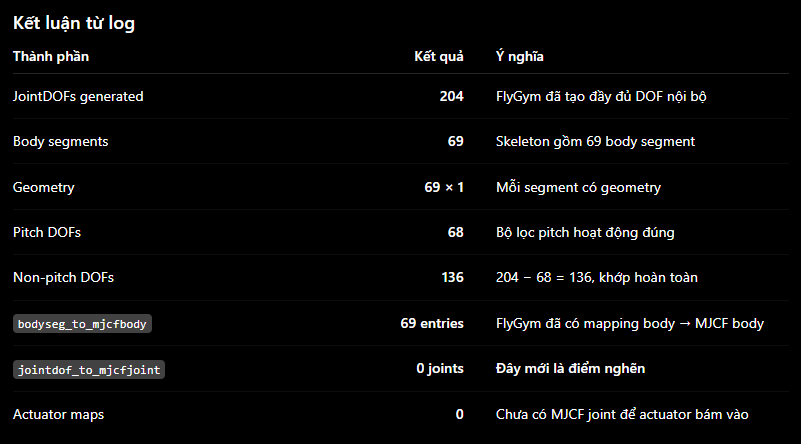

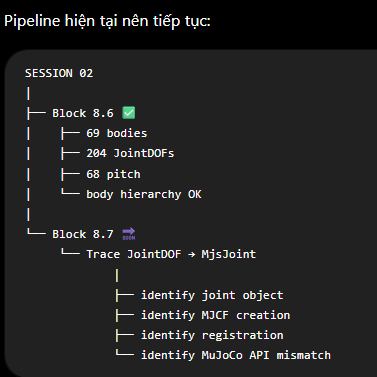

## BLOCK 8.7 — JOINT CONSTRUCTION TRACE

In [29]:
# ============================================================
# BLOCK 8.6.1 — RECOVER / RECREATE FLY OBJECT
# ============================================================

print("=" * 70)
print("BLOCK 8.6.1 — RECOVER / RECREATE FLY OBJECT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check current variables
# ------------------------------------------------------------

print("\n=== CURRENT FLY-LIKE VARIABLES ===")

fly_vars = []

for name, obj in list(globals().items()):

    if name.startswith("_"):
        continue

    name_lower = name.lower()

    if any(k in name_lower for k in [
        "fly",
        "nmf",
        "neuromech",
    ]):

        print(
            f"{name:30s} -> {type(obj)}"
        )

        fly_vars.append(name)


# ------------------------------------------------------------
# 2. If my_first_fly already exists, use it
# ------------------------------------------------------------

if "my_first_fly" in globals():

    print("\n[OK] my_first_fly already exists.")

else:

    print(
        "\n[INFO] my_first_fly does not exist."
    )

    print(
        "[INFO] Looking for an existing FlyGym object..."
    )

    found_fly = None
    found_name = None

    for name, obj in list(globals().items()):

        if name.startswith("_"):
            continue

        cls_name = type(obj).__name__.lower()

        if "neuromechfly" in cls_name:

            found_fly = obj
            found_name = name
            break

    if found_fly is not None:

        my_first_fly = found_fly

        print(
            f"[RECOVERED] {found_name} "
            "→ my_first_fly"
        )

    else:

        print(
            "[NOT FOUND] No existing NeuroMechFly object."
        )


# ------------------------------------------------------------
# 3. If still missing, inspect imports/classes
# ------------------------------------------------------------

if "my_first_fly" not in globals():

    print("\n=== SEARCHING FOR NEUROMECHFLY CLASS ===")

    candidates = []

    for name, obj in list(globals().items()):

        if name.startswith("_"):
            continue

        try:

            if isinstance(obj, type):

                cls_name = name.lower()

                if (
                    "neuromechfly" in cls_name
                    or "neuromech" in cls_name
                ):

                    candidates.append(
                        (name, obj)
                    )

        except Exception:
            pass

    if candidates:

        print(
            "Possible classes found:"
        )

        for name, obj in candidates:

            print(
                f"  {name}: {obj}"
            )

    else:

        print(
            "No NeuroMechFly class found in globals."
        )


# ------------------------------------------------------------
# 4. Final status
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("RECOVERY STATUS")
print("=" * 70)

if "my_first_fly" in globals():

    print(
        "SUCCESS: my_first_fly is available."
    )

    print(
        "Type:",
        type(my_first_fly)
    )

else:

    print(
        "my_first_fly is STILL NOT AVAILABLE."
    )

    print(
        "\nDo NOT recreate the fly blindly yet."
    )

    print(
        "We need to restore the exact construction "
        "environment from the previous blocks."
    )

print("=" * 70)

BLOCK 8.6.1 — RECOVER / RECREATE FLY OBJECT

=== CURRENT FLY-LIKE VARIABLES ===
fly_vars                       -> <class 'list'>
found_fly                      -> <class 'NoneType'>
flygym                         -> <class 'module'>
NeuroMechFly                   -> <class 'abc.ABCMeta'>
flygym_version                 -> <class 'str'>
fly                            -> <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
flygym_root                    -> <class 'str'>
fly_registry                   -> <class 'dict'>
registered_fly                 -> <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
nmf_source                     -> <class 'str'>
diagnostic_fly                 -> <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly_root                       -> <class 'mujoco._specs.MjSpec'>
add_fly_source                 -> <class 'str'>
fly_spec                       -> <class 'mujoco._specs.MjSpec'>
fly_xml                        -> <class 'str'>
fly_model                

In [30]:
# ============================================================
# BLOCK 8.7 — JOINT CONSTRUCTION TRACE
# ============================================================

print("=" * 70)
print("BLOCK 8.7 — JOINT CONSTRUCTION TRACE")
print("=" * 70)

# ------------------------------------------------------------
# 1. BASIC OBJECT
# ------------------------------------------------------------

print("\n=== 1. FLY OBJECT ===")

print("Fly type:", type(my_first_fly))

print("\nRelevant attributes:")

for name in dir(my_first_fly):
    lname = name.lower()

    if any(k in lname for k in [
        "joint",
        "dof",
        "body",
        "mjcf",
        "actuator",
        "segment",
        "model",
    ]):
        print(" ", name)


# ------------------------------------------------------------
# 2. EXISTING MAPS
# ------------------------------------------------------------

print("\n=== 2. EXISTING MAPS ===")

for attr in [
    "bodyseg_to_mjcfbody",
    "jointdof_to_mjcfjoint",
]:

    print(f"\n--- {attr} ---")

    if not hasattr(my_first_fly, attr):
        print("NOT FOUND")
        continue

    try:

        mapping = getattr(my_first_fly, attr)

        print("type :", type(mapping))
        print(
            "len  :",
            len(mapping) if hasattr(mapping, "__len__")
            else "N/A"
        )

        if hasattr(mapping, "items"):

            for i, (key, value) in enumerate(mapping.items()):

                if i >= 10:
                    break

                print(
                    f"[{i:02d}] "
                    f"KEY={repr(key)} "
                    f"VALUE={repr(value)}"
                )

    except Exception as e:

        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )


# ------------------------------------------------------------
# 3. BODY → MJCF NAVIGATION
# ------------------------------------------------------------

print("\n=== 3. BODY → MJCF NAVIGATION ===")

if hasattr(my_first_fly, "bodyseg_to_mjcfbody"):

    mapping = my_first_fly.bodyseg_to_mjcfbody

    print(
        "Body mapping entries:",
        len(mapping)
    )

    for i, (segment, body) in enumerate(mapping.items()):

        if i >= 5:
            break

        print(f"\n--- BODY [{i}] ---")

        print(
            "segment:",
            getattr(segment, "name", repr(segment))
        )

        print(
            "body type:",
            type(body)
        )

        print(
            "body:",
            repr(body)
        )

        print("\nRelevant body attributes:")

        for name in dir(body):

            lname = name.lower()

            if any(k in lname for k in [
                "joint",
                "body",
                "child",
                "parent",
                "geom",
            ]):

                print(" ", name)


# ------------------------------------------------------------
# 4. MJCF ROOT
# ------------------------------------------------------------

print("\n=== 4. MJCF ROOT ===")

for attr in [
    "root",
    "mjcf_root",
    "_root",
    "_mjcf_root",
]:

    if hasattr(my_first_fly, attr):

        try:

            obj = getattr(my_first_fly, attr)

            print(
                f"{attr}:",
                type(obj),
                repr(obj)
            )

        except Exception as e:

            print(
                f"{attr}: ERROR "
                f"{type(e).__name__}: {e}"
            )


# ------------------------------------------------------------
# 5. SEARCH JOINT-RELATED OBJECTS
# ------------------------------------------------------------

print("\n=== 5. JOINT-RELATED OBJECT SEARCH ===")

joint_attrs = []

for name in dir(my_first_fly):

    lname = name.lower()

    if "joint" in lname:

        joint_attrs.append(name)

print(
    "Joint-related attributes:",
    len(joint_attrs)
)

for name in joint_attrs:

    try:

        obj = getattr(my_first_fly, name)

        print(
            f"{name:35s}",
            "type=",
            type(obj),
            "len=",
            (
                len(obj)
                if hasattr(obj, "__len__")
                else "N/A"
            )
        )

    except Exception as e:

        print(
            f"{name:35s}",
            "ERROR=",
            type(e).__name__,
            str(e)
        )


# ------------------------------------------------------------
# 6. JOINTDOF-RELATED OBJECT SEARCH
# ------------------------------------------------------------

print("\n=== 6. JOINTDOF-RELATED OBJECT SEARCH ===")

dof_attrs = []

for name in dir(my_first_fly):

    lname = name.lower()

    if (
        "jointdof" in lname
        or "joint_dof" in lname
        or lname == "dofs"
        or "dof" in lname
    ):

        dof_attrs.append(name)

print(
    "DOF-related attributes:",
    len(dof_attrs)
)

for name in dof_attrs:

    try:

        obj = getattr(my_first_fly, name)

        print(
            f"{name:35s}",
            "type=",
            type(obj),
            "len=",
            (
                len(obj)
                if hasattr(obj, "__len__")
                else "N/A"
            )
        )

    except Exception as e:

        print(
            f"{name:35s}",
            "ERROR=",
            type(e).__name__,
            str(e)
        )


# ------------------------------------------------------------
# 7. DEEP INSPECTION OF BODY OBJECT
# ------------------------------------------------------------

print("\n=== 7. DEEP BODY INSPECTION ===")

if hasattr(my_first_fly, "bodyseg_to_mjcfbody"):

    mapping = my_first_fly.bodyseg_to_mjcfbody

    if len(mapping) > 0:

        segment, body = next(iter(mapping.items()))

        print(
            "First segment:",
            getattr(segment, "name", repr(segment))
        )

        print(
            "Body type:",
            type(body)
        )

        print("\nTrying common joint access patterns:")

        for attr in [
            "joints",
            "joint",
            "children",
            "parent",
            "child",
        ]:

            try:

                exists = hasattr(body, attr)

                print(
                    f"\n{attr}: exists={exists}"
                )

                if exists:

                    value = getattr(body, attr)

                    print(
                        "  type:",
                        type(value)
                    )

                    print(
                        "  repr:",
                        repr(value)
                    )

                    if hasattr(value, "__len__"):

                        print(
                            "  len :",
                            len(value)
                        )

            except Exception as e:

                print(
                    "  ERROR:",
                    type(e).__name__,
                    str(e)
                )


# ------------------------------------------------------------
# 8. SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("BLOCK 8.7 DIAGNOSTIC SUMMARY")
print("=" * 70)

try:
    print(
        "Body segments:",
        len(my_first_fly.bodyseg_to_mjcfbody)
    )
except Exception:
    print(
        "Body segments: UNKNOWN"
    )

try:
    print(
        "JointDOF → MJCF joint:",
        len(my_first_fly.jointdof_to_mjcfjoint)
    )
except Exception:
    print(
        "JointDOF → MJCF joint: UNKNOWN"
    )

print("=" * 70)
print("BLOCK 8.7 COMPLETE")
print("=" * 70)

BLOCK 8.7 — JOINT CONSTRUCTION TRACE

=== 1. FLY OBJECT ===
Fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

Relevant attributes:
  BODY_SEGMENT_CLASS
  JOINT_DOF_CLASS
  _add_one_body_and_geoms
  _all_possible_joint_preset
  _mjcf_root
  add_actuators
  add_joint_sites
  add_joints
  anatomicaljoint_to_mjcfsites
  bodyseg_to_mjcfbody
  bodyseg_to_mjcfgeom
  bodyseg_to_mjcfmesh
  cameraname_to_mjcfcamera
  eyecameraname_to_mjcfcamera
  get_actuated_jointdofs_order
  get_bodysegs_order
  get_jointdofs_order
  jointdof_to_mjcfactuator_by_type
  jointdof_to_mjcfjoint
  jointdof_to_neutralaction_by_type
  jointdof_to_neutralangle
  leg_to_adhesionactuator
  mjcf_root
  root_segment
  sensorname_to_mjcfsensor

=== 2. EXISTING MAPS ===

--- bodyseg_to_mjcfbody ---
type : <class 'dict'>
len  : 69
[00] KEY=BodySegment(name='c_thorax') VALUE=<mujoco._specs.MjsBody object at 0x7a4641a3e1b0>
[01] KEY=BodySegment(name='c_head') VALUE=<mujoco._specs.MjsBody object at 0x7a46418ab1f0

## BLOCK 8.8 — JOINT DISCOVERY FROM MjsBody.joints

In [8]:
# ======================================================================
# BLOCK 8.8 — ENVIRONMENT CHECK BEFORE RECREATING FLY
# ======================================================================

print("=" * 70)
print("BLOCK 8.8 — ENVIRONMENT CHECK")
print("=" * 70)

import sys
import os
import inspect

print("\n=== PYTHON ===")
print(sys.version)

print("\n=== FLYGYM ===")

try:
    import flygym

    print("flygym:", flygym)
    print("flygym file:", flygym.__file__)

except Exception as e:
    print("ERROR importing flygym:", repr(e))


print("\n=== NEUROMECHFLY ===")

try:
    from flygym.compose.fly.neuromechfly import NeuroMechFly

    print("NeuroMechFly:", NeuroMechFly)
    print("module:", NeuroMechFly.__module__)

except Exception as e:
    print("ERROR importing NeuroMechFly:", repr(e))


print("\n=== CONSTRUCTOR ===")

try:

    print(
        inspect.signature(
            NeuroMechFly.__init__
        )
    )

except Exception as e:

    print(
        "Cannot inspect signature:",
        repr(e)
    )


print("\n=== EXISTING GLOBAL CONFIG ===")

for name in [
    "flygym_version",
    "flygym_root",
    "fly_xml",
    "fly_spec",
    "fly_model",
    "BaseFly",
]:

    if name in globals():

        value = globals()[name]

        print(
            f"{name:20s} -> {type(value)}"
        )

    else:

        print(
            f"{name:20s} -> NOT FOUND"
        )


print("\n" + "=" * 70)
print("DO NOT CREATE THE FLY YET")
print("=" * 70)

BLOCK 8.8 — ENVIRONMENT CHECK

=== PYTHON ===
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

=== FLYGYM ===
flygym: <module 'flygym' from '/usr/local/lib/python3.12/dist-packages/flygym/__init__.py'>
flygym file: /usr/local/lib/python3.12/dist-packages/flygym/__init__.py

=== NEUROMECHFLY ===
NeuroMechFly: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
module: flygym.compose.fly.neuromechfly

=== CONSTRUCTOR ===
(self, name: str = 'nmf', *, rigging_config_path: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/rigging.yaml'), mesh_basedir: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/meshes'), mujoco_globals_path: os.PathLike = PosixPath('/usr/local/lib/python3.12/dist-packages/flygym/assets/model/neuromechfly/mujoco_globals.yaml'), root_segment: flygym.anatomy.BodySegment | str = 'c_thorax', mirror_left2right: bool = True, mesh_type: flygym.compose.fly.base_fly.MeshType = 

## BLOCK 8.8 — RECREATE + VERIFY

In [9]:
# ======================================================================
# BLOCK 8.8 — RECREATE NEUROMECHFLY + VERIFY STRUCTURE
# ======================================================================

print("=" * 70)
print("BLOCK 8.8 — RECREATE NEUROMECHFLY")
print("=" * 70)

import inspect

from flygym.compose.fly.neuromechfly import NeuroMechFly


# ----------------------------------------------------------------------
# 1. CREATE FLY
# ----------------------------------------------------------------------

print("\n=== 1. CREATING NEUROMECHFLY ===")

try:

    my_first_fly = NeuroMechFly(
        name="my_first_fly"
    )

    print("[SUCCESS] NeuroMechFly created")

except Exception as e:

    print("[ERROR] Failed to create NeuroMechFly")
    print(type(e))
    print(repr(e))
    raise


# ----------------------------------------------------------------------
# 2. BASIC OBJECT CHECK
# ----------------------------------------------------------------------

print("\n=== 2. BASIC OBJECT ===")

print("Fly type:")
print(type(my_first_fly))

print("\nFly object:")
print(my_first_fly)


# ----------------------------------------------------------------------
# 3. BODY MAP
# ----------------------------------------------------------------------

print("\n=== 3. BODY MAP ===")

body_map = my_first_fly.bodyseg_to_mjcfbody

print("bodyseg_to_mjcfbody:")
print(type(body_map))

print("Number of body segments:")
print(len(body_map))


# ----------------------------------------------------------------------
# 4. BODY NAMES
# ----------------------------------------------------------------------

print("\n=== 4. BODY SEGMENTS ===")

body_names = []

for segment in body_map.keys():

    try:
        name = segment.name
    except Exception:
        name = str(segment)

    body_names.append(name)


for i, name in enumerate(body_names):

    print(
        f"[{i:03d}] {name}"
    )


# ----------------------------------------------------------------------
# 5. MJCF ROOT
# ----------------------------------------------------------------------

print("\n=== 5. MJCF ROOT ===")

print(
    "mjcf_root type:",
    type(my_first_fly.mjcf_root)
)

print(
    "mjcf_root:",
    my_first_fly.mjcf_root
)


# ----------------------------------------------------------------------
# 6. JOINT MAPS
# ----------------------------------------------------------------------

print("\n=== 6. JOINT MAPS ===")

print(
    "jointdof_to_mjcfjoint:",
    type(my_first_fly.jointdof_to_mjcfjoint),
    "len=",
    len(my_first_fly.jointdof_to_mjcfjoint)
)

print(
    "jointdof_to_neutralangle:",
    type(my_first_fly.jointdof_to_neutralangle),
    "len=",
    len(my_first_fly.jointdof_to_neutralangle)
)


# ----------------------------------------------------------------------
# 7. JOINTDOF ORDER
# ----------------------------------------------------------------------

print("\n=== 7. JOINTDOF ORDER ===")

try:

    jointdofs = my_first_fly.get_jointdofs_order()

    print(
        "get_jointdofs_order() type:",
        type(jointdofs)
    )

    print(
        "JointDOF count:",
        len(jointdofs)
    )

    for i, dof in enumerate(jointdofs[:20]):

        print(
            f"[{i:03d}]",
            dof
        )

except Exception as e:

    print(
        "[WARNING] get_jointdofs_order() failed:",
        repr(e)
    )


# ----------------------------------------------------------------------
# 8. DIRECT BODY → JOINT TEST
# ----------------------------------------------------------------------

print("\n=== 8. DIRECT MjsBody.joints TEST ===")

first_segment, first_body = next(
    iter(body_map.items())
)

print(
    "First body segment:",
    first_segment.name
)

print(
    "Body type:",
    type(first_body)
)

print(
    "Has .joints:",
    hasattr(first_body, "joints")
)

if hasattr(first_body, "joints"):

    print(
        "joints type:",
        type(first_body.joints)
    )

    print(
        "joint count:",
        len(first_body.joints)
    )

    for i, joint in enumerate(first_body.joints):

        print(
            f"\nJoint [{i}]"
        )

        print(
            "type:",
            type(joint)
        )

        print(
            "repr:",
            joint
        )

        for attr in [
            "name",
            "type",
            "axis",
            "pos",
            "range",
            "limited",
        ]:

            try:

                print(
                    f"  {attr}:",
                    getattr(joint, attr)
                )

            except Exception:

                pass


# ----------------------------------------------------------------------
# 9. TOTAL MJCF JOINT DISCOVERY
# ----------------------------------------------------------------------

print("\n=== 9. DISCOVER ALL MJCF JOINTS ===")

all_joints = []

for segment, body in body_map.items():

    try:

        joints = body.joints

    except Exception:

        continue

    for joint in joints:

        all_joints.append(
            {
                "segment": segment.name,
                "body": body,
                "joint": joint,
            }
        )


print(
    "Total MJCF joints discovered:",
    len(all_joints)
)


# ----------------------------------------------------------------------
# 10. SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("BLOCK 8.8 — RECREATE SUMMARY")
print("=" * 70)

print(
    "Fly object:",
    type(my_first_fly)
)

print(
    "Body segments:",
    len(body_map)
)

print(
    "JointDOFs:",
    len(jointdofs) if "jointdofs" in locals() else "UNKNOWN"
)

print(
    "Internal joint map:",
    len(my_first_fly.jointdof_to_mjcfjoint)
)

print(
    "Direct MJCF joints:",
    len(all_joints)
)

print("=" * 70)

BLOCK 8.8 — RECREATE NEUROMECHFLY

=== 1. CREATING NEUROMECHFLY ===
[SUCCESS] NeuroMechFly created

=== 2. BASIC OBJECT ===
Fly type:
<class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

Fly object:

=== 3. BODY MAP ===
bodyseg_to_mjcfbody:
<class 'dict'>
Number of body segments:
69

=== 4. BODY SEGMENTS ===
[000] c_thorax
[001] c_head
[002] c_rostrum
[003] c_haustellum
[004] l_eye
[005] r_eye
[006] l_pedicel
[007] l_funiculus
[008] l_arista
[009] r_pedicel
[010] r_funiculus
[011] r_arista
[012] c_abdomen12
[013] c_abdomen3
[014] c_abdomen4
[015] c_abdomen5
[016] c_abdomen6
[017] l_wing
[018] r_wing
[019] l_haltere
[020] r_haltere
[021] lf_coxa
[022] lf_trochanterfemur
[023] lf_tibia
[024] lf_tarsus1
[025] lf_tarsus2
[026] lf_tarsus3
[027] lf_tarsus4
[028] lf_tarsus5
[029] lm_coxa
[030] lm_trochanterfemur
[031] lm_tibia
[032] lm_tarsus1
[033] lm_tarsus2
[034] lm_tarsus3
[035] lm_tarsus4
[036] lm_tarsus5
[037] lh_coxa
[038] lh_trochanterfemur
[039] lh_tibia
[040] lh_tarsus1
[041] lh_

## BLOCK 8.9 — DISCOVER JOINT GENERATION API

In [19]:
# ======================================================================
# BLOCK 8.10 — TRACE SKELETON + JOINT PRESET
# ======================================================================

import inspect
import os
import flygym
import flygym.anatomy as anatomy

Skeleton = anatomy.Skeleton
JointPreset = anatomy.JointPreset
JointDOF = anatomy.JointDOF

print("=" * 70)
print("BLOCK 8.10 — TRACE SKELETON + JOINT PRESET")
print("=" * 70)


# ======================================================================
# 1. CURRENT FLY
# ======================================================================

print("\n=== 1. CURRENT FLY ===")
print("fly:", fly)
print("type:", type(fly))
print("fly.skeleton:", getattr(fly, "skeleton", None))


# ======================================================================
# 2. CLASSES
# ======================================================================

print("\n=== 2. ANATOMY CLASSES ===")

print("Skeleton:", Skeleton)
print("JointPreset:", JointPreset)
print("JointDOF:", JointDOF)


# ======================================================================
# 3. SOURCE FILES
# ======================================================================

print("\n=== 3. SOURCE FILES ===")

for name, obj in [
    ("Skeleton", Skeleton),
    ("JointPreset", JointPreset),
    ("JointDOF", JointDOF),
]:
    print(f"\n--- {name} ---")
    print("module:", inspect.getmodule(obj))
    print("file:", inspect.getsourcefile(obj))


# ======================================================================
# 4. SKELETON SIGNATURE + SOURCE
# ======================================================================

print("\n=== 4. SKELETON SIGNATURE ===")

try:
    print(inspect.signature(Skeleton))
except Exception as e:
    print("ERROR:", repr(e))

print("\n=== 5. SKELETON SOURCE ===")

try:
    print(inspect.getsource(Skeleton))
except Exception as e:
    print("ERROR:", repr(e))


# ======================================================================
# 5. FLY SKELETON METHODS
# ======================================================================

print("\n=== 6. FLY SKELETON METHODS ===")

for name in [
    "_get_base_skeleton",
    "get_jointdofs_order",
    "get_actuated_jointdofs_order",
    "add_joints",
]:

    if hasattr(fly, name):

        obj = getattr(fly, name)

        print("\n---", name, "---")
        print("Object:", obj)

        try:
            print("Signature:", inspect.signature(obj))
        except Exception as e:
            print("Signature ERROR:", repr(e))

        try:
            print("Source:")
            print(inspect.getsource(obj))
        except Exception as e:
            print("Source ERROR:", repr(e))


# ======================================================================
# 6. BASE SKELETON
# ======================================================================

print("\n=== 7. BASE SKELETON ===")

base_skeleton = None

try:

    base_skeleton = fly._get_base_skeleton()

    print("[SUCCESS] Base skeleton obtained")
    print("base_skeleton:", base_skeleton)
    print("type:", type(base_skeleton))
    print("repr:", repr(base_skeleton))

except Exception as e:

    print("[ERROR] _get_base_skeleton() failed")
    print(type(e).__name__, repr(e))


# ======================================================================
# 7. JOINT PRESET
# ======================================================================

print("\n=== 8. JOINT PRESET MEMBERS ===")

for member in JointPreset:
    print(
        "name =", member.name,
        "| value =", member.value
    )


# ======================================================================
# 8. ALL POSSIBLE
# ======================================================================

print("\n=== 9. ALL_POSSIBLE ===")

all_possible = JointPreset.ALL_POSSIBLE

print("Object:", all_possible)
print("type:", type(all_possible))
print("value:", all_possible.value)


# ======================================================================
# 9. JOINT LIST
# ======================================================================

print("\n=== 10. ALL_POSSIBLE.to_joint_list() ===")

joint_list = None

try:

    joint_list = all_possible.to_joint_list()

    print("[SUCCESS]")
    print("type:", type(joint_list))
    print("length:", len(joint_list))

    for i, joint in enumerate(joint_list):
        print(
            f"[{i:03d}]",
            joint,
            "| type =", type(joint)
        )

except Exception as e:

    print("[ERROR]")
    print(type(e).__name__, repr(e))


# ======================================================================
# 10. to_joint_list SOURCE
# ======================================================================

print("\n=== 11. to_joint_list SOURCE ===")

try:
    print(inspect.signature(JointPreset.to_joint_list))
    print(inspect.getsource(JointPreset.to_joint_list))
except Exception as e:
    print("ERROR:", repr(e))


# ======================================================================
# 11. JOINTDOF SOURCE
# ======================================================================

print("\n=== 12. JOINTDOF SOURCE ===")

try:
    print(inspect.signature(JointDOF))
    print(inspect.getsource(JointDOF))
except Exception as e:
    print("ERROR:", repr(e))


# ======================================================================
# 12. PACKAGE SEARCH
# ======================================================================

print("\n=== 13. PACKAGE SOURCE SEARCH ===")

flygym_root = os.path.dirname(flygym.__file__)

print("FlyGym root:", flygym_root)

terms = [
    "_get_base_skeleton",
    "JointPreset.ALL_POSSIBLE",
    "Skeleton(",
    "to_joint_list",
    "iter_jointdofs",
]

for term in terms:

    print("\n" + "-" * 60)
    print("SEARCH:", term)
    print("-" * 60)

    for root, dirs, files in os.walk(flygym_root):

        dirs[:] = [
            d for d in dirs
            if d != "__pycache__"
        ]

        for filename in files:

            if not filename.endswith(".py"):
                continue

            path = os.path.join(root, filename)

            try:

                with open(path, "r", encoding="utf-8") as f:
                    text = f.read()

                if term in text:
                    print(path)

            except Exception:
                pass


# ======================================================================
# FINAL
# ======================================================================

print("\n" + "=" * 70)
print("BLOCK 8.10 COMPLETE")
print("=" * 70)

print("Fly:", type(fly))
print("fly.skeleton:", getattr(fly, "skeleton", None))
print("Skeleton:", Skeleton)
print("JointPreset:", JointPreset)
print("ALL_POSSIBLE:", JointPreset.ALL_POSSIBLE)

if joint_list is not None:
    print("Joint count:", len(joint_list))

print("MJCF joint map:", len(fly.jointdof_to_mjcfjoint))
print("Neutral angle map:", len(fly.jointdof_to_neutralangle))

print("=" * 70)
print("DO NOT CALL add_joints() YET.")

BLOCK 8.10 — TRACE SKELETON + JOINT PRESET

=== 1. CURRENT FLY ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton: None

=== 2. ANATOMY CLASSES ===
Skeleton: <class 'flygym.anatomy.Skeleton'>
JointPreset: <enum 'JointPreset'>
JointDOF: <class 'flygym.anatomy.JointDOF'>

=== 3. SOURCE FILES ===

--- Skeleton ---
module: <module 'flygym.anatomy' from '/usr/local/lib/python3.12/dist-packages/flygym/anatomy.py'>
file: /usr/local/lib/python3.12/dist-packages/flygym/anatomy.py

--- JointPreset ---
module: <module 'flygym.anatomy' from '/usr/local/lib/python3.12/dist-packages/flygym/anatomy.py'>
file: /usr/local/lib/python3.12/dist-packages/flygym/anatomy.py

--- JointDOF ---
module: <module 'flygym.anatomy' from '/usr/local/lib/python3.12/dist-packages/flygym/anatomy.py'>
file: /usr/local/lib/python3.12/dist-packages/flygym/anatomy.py

=== 4. SKELETON SIGNATURE ===
(*, axis_order: flygym.a

## BLOCK 8.11 — TRACE JOINT DOFs + AXIS ORDER

### Mục tiêu của block này:

1. Lấy base_skeleton
2. Chạy iter_jointdofs()
3. Xem toàn bộ JointDOF
4. Đếm tổng DOF
5. Phân nhóm theo:
- chân trái/phải
- coxa
- femur
- tibia
- tarsus
- roll/pitch/yaw
6. Kiểm tra AXIS_ORDER_CLASS
7. Kiểm tra thứ tự DOF mà FlyGym sẽ dùng khi add_joints()

In [20]:
# ======================================================================
# BLOCK 8.11 — TRACE JOINT DOFs + AXIS ORDER
# DO NOT CALL add_joints()
# ======================================================================

import inspect
from collections import Counter, defaultdict

print("=" * 70)
print("BLOCK 8.11 — TRACE JOINT DOFs + AXIS ORDER")
print("=" * 70)

# ======================================================================
# 1. BASE SKELETON
# ======================================================================

print("\n=== 1. BASE SKELETON ===")

if "base_skeleton" not in globals() or base_skeleton is None:
    print("[INFO] base_skeleton chưa tồn tại -> tạo lại")

    base_skeleton = fly._get_base_skeleton()

print("base_skeleton:")
print(base_skeleton)

print("\ntype:")
print(type(base_skeleton))


# ======================================================================
# 2. AXIS ORDER
# ======================================================================

print("\n=== 2. AXIS ORDER ===")

print("base_skeleton.axis_order:")
print(base_skeleton.axis_order)

print("\ntype:")
print(type(base_skeleton.axis_order))

print("\nfly AXIS_ORDER_CLASS:")

if hasattr(fly, "AXIS_ORDER_CLASS"):
    print(fly.AXIS_ORDER_CLASS)
else:
    print("[NOT FOUND]")


# ======================================================================
# 3. ITERATE ALL JOINT DOFs
# ======================================================================

print("\n=== 3. ALL JOINT DOFs ===")

jointdofs = list(
    base_skeleton.iter_jointdofs(
        root=fly.root_segment
    )
)

print("Number of JointDOFs:")
print(len(jointdofs))

print("\nJOINT DOFs:")

for i, dof in enumerate(jointdofs):

    print(
        f"[{i:03d}]",
        "name=", dof.name,
        "| parent=", dof.parent.name,
        "| child=", dof.child.name,
        "| axis=", dof.axis
    )


# ======================================================================
# 4. AXIS DISTRIBUTION
# ======================================================================

print("\n=== 4. AXIS DISTRIBUTION ===")

axis_counter = Counter(
    dof.axis.value
    for dof in jointdofs
)

print(axis_counter)


# ======================================================================
# 5. BODY / LEG DISTRIBUTION
# ======================================================================

print("\n=== 5. LEG DISTRIBUTION ===")

leg_groups = defaultdict(list)

for dof in jointdofs:

    child = dof.child.name

    if child.startswith("lf_"):
        leg = "LF"

    elif child.startswith("lm_"):
        leg = "LM"

    elif child.startswith("lh_"):
        leg = "LH"

    elif child.startswith("rf_"):
        leg = "RF"

    elif child.startswith("rm_"):
        leg = "RM"

    elif child.startswith("rh_"):
        leg = "RH"

    else:
        leg = "NON_LEG"

    leg_groups[leg].append(dof)


for leg, dofs in leg_groups.items():

    print(
        f"{leg:10s}",
        "DOFs =",
        len(dofs)
    )


# ======================================================================
# 6. DETAILED LEG DOFs
# ======================================================================

print("\n=== 6. DETAILED LEG DOFs ===")

for leg in ["LF", "LM", "LH", "RF", "RM", "RH"]:

    if leg not in leg_groups:
        continue

    print("\n---", leg, "---")

    for i, dof in enumerate(leg_groups[leg]):

        print(
            f"{i:02d}",
            dof.name,
            "| axis =", dof.axis.value
        )


# ======================================================================
# 7. JOINT TYPE / SEGMENT TRANSITIONS
# ======================================================================

print("\n=== 7. JOINT TRANSITIONS ===")

transition_counter = Counter()

for dof in jointdofs:

    parent = dof.parent.name
    child = dof.child.name

    transition_counter[
        (parent, child)
    ] += 1


print(
    "Unique anatomical joint pairs:",
    len(transition_counter)
)

for pair, count in transition_counter.items():

    print(
        pair,
        "->",
        count,
        "DOF(s)"
    )


# ======================================================================
# 8. DOFs PER ANATOMICAL JOINT
# ======================================================================

print("\n=== 8. DOFs PER ANATOMICAL JOINT ===")

joint_to_dofs = defaultdict(list)

for dof in jointdofs:

    key = (
        dof.parent.name,
        dof.child.name
    )

    joint_to_dofs[key].append(dof)


distribution = Counter(
    len(v)
    for v in joint_to_dofs.values()
)

print(
    "Distribution:",
    dict(distribution)
)

print("\nExample joints:")

for i, (joint, dofs) in enumerate(joint_to_dofs.items()):

    if i >= 15:
        break

    print(
        joint,
        "=>",
        [d.axis.value for d in dofs]
    )


# ======================================================================
# 9. JOINTDOF NAME ROUND-TRIP
# ======================================================================

print("\n=== 9. JOINTDOF NAME ROUND-TRIP ===")

if jointdofs:

    test_dof = jointdofs[0]

    print("Original:")
    print(test_dof)

    print("\nName:")
    print(test_dof.name)

    reconstructed = JointDOF.from_name(
        test_dof.name
    )

    print("\nReconstructed:")
    print(reconstructed)

    print("\nEqual:")
    print(
        reconstructed == test_dof
    )


# ======================================================================
# 10. FLY CURRENT MAPS
# ======================================================================

print("\n=== 10. CURRENT FLY MAPS ===")

print(
    "jointdof_to_mjcfjoint:",
    len(fly.jointdof_to_mjcfjoint)
)

print(
    "jointdof_to_neutralangle:",
    len(fly.jointdof_to_neutralangle)
)

print(
    "jointdof_to_neutralaction_by_type:"
)

for actuator_type, mapping in (
    fly.jointdof_to_neutralaction_by_type.items()
):

    print(
        " ",
        actuator_type,
        "->",
        len(mapping)
    )


# ======================================================================
# 11. CURRENT SKELETON STATUS
# ======================================================================

print("\n=== 11. CURRENT SKELETON STATUS ===")

print(
    "fly.skeleton:",
    fly.skeleton
)

print(
    "fly.skeleton is None:",
    fly.skeleton is None
)


# ======================================================================
# 12. FINAL SUMMARY
# ======================================================================

print("\n")
print("=" * 70)
print("BLOCK 8.11 COMPLETE")
print("=" * 70)

print(
    "Base Skeleton:",
    type(base_skeleton)
)

print(
    "Axis Order:",
    base_skeleton.axis_order
)

print(
    "Total JointDOFs:",
    len(jointdofs)
)

print(
    "Anatomical joints:",
    len(joint_to_dofs)
)

print(
    "Axis distribution:",
    dict(axis_counter)
)

print(
    "LF/LF... leg groups:"
)

for leg in ["LF", "LM", "LH", "RF", "RM", "RH"]:

    print(
        f"  {leg}:",
        len(leg_groups.get(leg, []))
    )

print(
    "\nfly.skeleton:",
    fly.skeleton
)

print("\nDO NOT CALL add_joints() YET.")
print("SEND FULL OUTPUT OF BLOCK 8.11.")

BLOCK 8.11 — TRACE JOINT DOFs + AXIS ORDER

=== 1. BASE SKELETON ===
base_skeleton:

type:
<class 'flygym.anatomy.Skeleton'>

=== 2. AXIS ORDER ===
base_skeleton.axis_order:
AxisOrder.PITCH_ROLL_YAW

type:
<enum 'AxisOrder'>

fly AXIS_ORDER_CLASS:
<enum 'AxisOrder'>

=== 3. ALL JOINT DOFs ===
Number of JointDOFs:
204

JOINT DOFs:
[000] name= c_thorax-c_head-pitch | parent= c_thorax | child= c_head | axis= RotationAxis.PITCH
[001] name= c_thorax-c_head-roll | parent= c_thorax | child= c_head | axis= RotationAxis.ROLL
[002] name= c_thorax-c_head-yaw | parent= c_thorax | child= c_head | axis= RotationAxis.YAW
[003] name= c_head-c_rostrum-pitch | parent= c_head | child= c_rostrum | axis= RotationAxis.PITCH
[004] name= c_head-c_rostrum-roll | parent= c_head | child= c_rostrum | axis= RotationAxis.ROLL
[005] name= c_head-c_rostrum-yaw | parent= c_head | child= c_rostrum | axis= RotationAxis.YAW
[006] name= c_rostrum-c_haustellum-pitch | parent= c_rostrum | child= c_haustellum | axis= Rotatio

## BLOCK 8.12 — AUDIT JOINTDOF → MJCF / NEUTRAL / ACTUATOR MAPPINGS

In [21]:
# ======================================================================
# BLOCK 8.12 — AUDIT JOINTDOF -> MJCF / NEUTRAL / ACTUATOR MAPPINGS
#
# PURPOSE:
#   Audit the current JointDOF mapping state BEFORE add_joints().
#
# IMPORTANT:
#   DO NOT CALL add_joints() IN THIS BLOCK.
#   DO NOT MODIFY fly.skeleton.
#   DO NOT MODIFY any mapping.
# ======================================================================

from collections import Counter, defaultdict

print("=" * 70)
print("BLOCK 8.12 — AUDIT JOINTDOF -> MJCF / NEUTRAL / ACTUATOR MAPPINGS")
print("=" * 70)

# ======================================================================
# 0. SAFETY CHECK
# ======================================================================

print("\n=== 0. SAFETY CHECK ===")

print("fly:", fly)
print("fly type:", type(fly))

print("\nfly.skeleton:")
print(fly.skeleton)

print("\nfly.skeleton is None:")
print(fly.skeleton is None)

if fly.skeleton is not None:
    print("\n[WARNING] fly.skeleton is already initialized.")
    print("This is unexpected for the intended 8.12 pre-add_joints state.")
else:
    print("\n[PASS] fly.skeleton is still None.")
    print("[PASS] No skeleton mutation detected.")


# ======================================================================
# 1. BASE JOINTDOFs
# ======================================================================

print("\n=== 1. BASE JOINTDOFs ===")

if "base_skeleton" not in globals() or base_skeleton is None:
    print("[INFO] Rebuilding base_skeleton...")
    base_skeleton = fly._get_base_skeleton()

jointdofs_812 = list(
    base_skeleton.iter_jointdofs(
        root=fly.root_segment
    )
)

print("Base skeleton type:")
print(type(base_skeleton))

print("\nAxis order:")
print(base_skeleton.axis_order)

print("\nTotal JointDOFs:")
print(len(jointdofs_812))


# ======================================================================
# 2. JOINTDOF NAME INDEX
# ======================================================================

print("\n=== 2. JOINTDOF NAME INDEX ===")

jointdof_by_name = {
    dof.name: dof
    for dof in jointdofs_812
}

print("Number of indexed JointDOFs:")
print(len(jointdof_by_name))

print("\nFirst 15 JointDOF names:")

for i, name in enumerate(jointdof_by_name.keys()):
    if i >= 15:
        break
    print(f"[{i:03d}] {name}")


# ======================================================================
# 3. CURRENT MJCF JOINT MAPPING
# ======================================================================

print("\n=== 3. CURRENT JOINTDOF -> MJCF JOINT MAPPING ===")

mjcf_map = getattr(
    fly,
    "jointdof_to_mjcfjoint",
    None
)

print("Mapping object:")
print(mjcf_map)

if mjcf_map is None:
    print("\n[INFO] jointdof_to_mjcfjoint attribute not found.")
else:
    print("\nMapping type:")
    print(type(mjcf_map))

    print("\nMapping length:")
    print(len(mjcf_map))

    if len(mjcf_map) == 0:
        print("\n[EXPECTED] Mapping is empty before add_joints().")
    else:
        print("\nFirst mapping entries:")

        for i, (key, value) in enumerate(mjcf_map.items()):
            if i >= 15:
                break

            print(
                f"[{i:03d}]",
                key,
                "->",
                value
            )


# ======================================================================
# 4. CURRENT NEUTRAL ANGLE MAPPING
# ======================================================================

print("\n=== 4. CURRENT JOINTDOF -> NEUTRAL ANGLE MAPPING ===")

neutral_angle_map = getattr(
    fly,
    "jointdof_to_neutralangle",
    None
)

print("Mapping object:")
print(neutral_angle_map)

if neutral_angle_map is None:
    print("\n[INFO] jointdof_to_neutralangle attribute not found.")
else:
    print("\nMapping type:")
    print(type(neutral_angle_map))

    print("\nMapping length:")
    print(len(neutral_angle_map))

    if len(neutral_angle_map) == 0:
        print("\n[EXPECTED] Neutral-angle mapping is empty.")
    else:
        print("\nFirst mapping entries:")

        for i, (key, value) in enumerate(
            neutral_angle_map.items()
        ):
            if i >= 15:
                break

            print(
                f"[{i:03d}]",
                key,
                "->",
                value
            )


# ======================================================================
# 5. CURRENT NEUTRAL ACTION MAPPING
# ======================================================================

print("\n=== 5. CURRENT JOINTDOF -> NEUTRAL ACTION MAPPING ===")

neutral_action_maps = getattr(
    fly,
    "jointdof_to_neutralaction_by_type",
    None
)

print("Container:")
print(neutral_action_maps)

if neutral_action_maps is None:
    print(
        "\n[INFO] jointdof_to_neutralaction_by_type "
        "attribute not found."
    )
else:

    print("\nContainer type:")
    print(type(neutral_action_maps))

    print("\nActuator types:")

    for actuator_type, mapping in neutral_action_maps.items():

        print(
            " ",
            actuator_type,
            "->",
            "mapping type:",
            type(mapping),
            "| length:",
            len(mapping)
        )

        if len(mapping) > 0:

            print("    First entries:")

            for i, (key, value) in enumerate(
                mapping.items()
            ):

                if i >= 5:
                    break

                print(
                    "   ",
                    f"[{i:02d}]",
                    key,
                    "->",
                    value
                )


# ======================================================================
# 6. MAPPING COVERAGE SUMMARY
# ======================================================================

print("\n=== 6. MAPPING COVERAGE SUMMARY ===")

total_jointdofs = len(jointdofs_812)

mjcf_count = (
    len(mjcf_map)
    if mjcf_map is not None
    else 0
)

neutral_angle_count = (
    len(neutral_angle_map)
    if neutral_angle_map is not None
    else 0
)

print(
    "Total base JointDOFs:",
    total_jointdofs
)

print(
    "MJCF mapping entries:",
    mjcf_count
)

print(
    "Neutral-angle entries:",
    neutral_angle_count
)

if neutral_action_maps is not None:

    print("\nNeutral-action coverage:")

    for actuator_type, mapping in neutral_action_maps.items():

        print(
            " ",
            actuator_type,
            "->",
            len(mapping)
        )


# ======================================================================
# 7. CHECK WHETHER MAPPINGS ARE PRE-INITIALIZED
# ======================================================================

print("\n=== 7. PRE-INITIALIZATION STATE ===")

mapping_states = {
    "jointdof_to_mjcfjoint": mjcf_count,
    "jointdof_to_neutralangle": neutral_angle_count,
}

for name, count in mapping_states.items():

    if count == 0:
        print(
            f"[EXPECTED EMPTY] {name}: {count}"
        )
    else:
        print(
            f"[NON-EMPTY] {name}: {count}"
        )

if neutral_action_maps is not None:

    for actuator_type, mapping in neutral_action_maps.items():

        if len(mapping) == 0:
            print(
                "[EXPECTED EMPTY]",
                f"neutralaction[{actuator_type}]: 0"
            )
        else:
            print(
                "[NON-EMPTY]",
                f"neutralaction[{actuator_type}]:",
                len(mapping)
            )


# ======================================================================
# 8. VERIFY JOINTDOF NAME ROUND-TRIP AGAIN
# ======================================================================

print("\n=== 8. JOINTDOF NAME ROUND-TRIP ===")

if jointdofs_812:

    test_dof = jointdofs_812[0]

    print("Original:")
    print(test_dof)

    print("\nName:")
    print(test_dof.name)

    reconstructed = JointDOF.from_name(
        test_dof.name
    )

    print("\nReconstructed:")
    print(reconstructed)

    print("\nEqual:")
    print(
        reconstructed == test_dof
    )

    if reconstructed == test_dof:
        print(
            "[PASS] JointDOF name round-trip is valid."
        )
    else:
        print(
            "[FAIL] JointDOF name round-trip mismatch."
        )


# ======================================================================
# 9. LEG DOF COVERAGE
# ======================================================================

print("\n=== 9. LEG JointDOF COVERAGE ===")

leg_groups_812 = defaultdict(list)

for dof in jointdofs_812:

    child = dof.child.name

    if child.startswith("lf_"):
        leg = "LF"

    elif child.startswith("lm_"):
        leg = "LM"

    elif child.startswith("lh_"):
        leg = "LH"

    elif child.startswith("rf_"):
        leg = "RF"

    elif child.startswith("rm_"):
        leg = "RM"

    elif child.startswith("rh_"):
        leg = "RH"

    else:
        leg = "NON_LEG"

    leg_groups_812[leg].append(dof)


for leg in [
    "LF",
    "LM",
    "LH",
    "RF",
    "RM",
    "RH",
    "NON_LEG"
]:

    print(
        f"{leg:10s}:",
        len(leg_groups_812.get(leg, [])),
        "DOFs"
    )


# ======================================================================
# 10. INTEGRITY CHECKS
# ======================================================================

print("\n=== 10. INTEGRITY CHECKS ===")

checks = {}

checks["base_skeleton_exists"] = (
    base_skeleton is not None
)

checks["jointdof_count_204"] = (
    len(jointdofs_812) == 204
)

checks["jointdof_names_unique"] = (
    len(jointdof_by_name) == len(jointdofs_812)
)

checks["axis_order_valid"] = (
    str(base_skeleton.axis_order)
    == "AxisOrder.PITCH_ROLL_YAW"
)

checks["six_leg_groups"] = all(
    len(leg_groups_812.get(leg, [])) == 24
    for leg in [
        "LF",
        "LM",
        "LH",
        "RF",
        "RM",
        "RH"
    ]
)

checks["fly_skeleton_not_initialized"] = (
    fly.skeleton is None
)

for name, result in checks.items():

    print(
        f"{name:35s}:",
        "PASS" if result else "FAIL"
    )


# ======================================================================
# 11. FINAL STATUS
# ======================================================================

print("\n")
print("=" * 70)
print("BLOCK 8.12 COMPLETE")
print("=" * 70)

print("\nBase Skeleton:")
print(type(base_skeleton))

print("\nAxis Order:")
print(base_skeleton.axis_order)

print("\nTotal JointDOFs:")
print(len(jointdofs_812))

print("\nUnique JointDOF names:")
print(len(jointdof_by_name))

print("\nMJCF mapping:")
print(mjcf_count)

print("\nNeutral angle mapping:")
print(neutral_angle_count)

print("\nfly.skeleton:")
print(fly.skeleton)

print("\nIntegrity:")
print(
    all(checks.values())
)

print("\nIMPORTANT:")
print("DO NOT CALL add_joints() YET.")
print("SEND FULL OUTPUT OF BLOCK 8.12.")

BLOCK 8.12 — AUDIT JOINTDOF -> MJCF / NEUTRAL / ACTUATOR MAPPINGS

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

fly.skeleton:
None

fly.skeleton is None:
True

[PASS] fly.skeleton is still None.
[PASS] No skeleton mutation detected.

=== 1. BASE JOINTDOFs ===
Base skeleton type:
<class 'flygym.anatomy.Skeleton'>

Axis order:
AxisOrder.PITCH_ROLL_YAW

Total JointDOFs:
204

=== 2. JOINTDOF NAME INDEX ===
Number of indexed JointDOFs:
204

First 15 JointDOF names:
[000] c_thorax-c_head-pitch
[001] c_thorax-c_head-roll
[002] c_thorax-c_head-yaw
[003] c_head-c_rostrum-pitch
[004] c_head-c_rostrum-roll
[005] c_head-c_rostrum-yaw
[006] c_rostrum-c_haustellum-pitch
[007] c_rostrum-c_haustellum-roll
[008] c_rostrum-c_haustellum-yaw
[009] c_head-l_eye-pitch
[010] c_head-l_eye-roll
[011] c_head-l_eye-yaw
[012] c_head-r_eye-pitch
[013] c_head-r_eye-roll
[014] c_head-r_eye-yaw

=

## Block 8.12 đã PASS hoàn toàn và trạng thái hiện tại rất sạch:

- 204 JointDOFs
- PITCH_ROLL_YAW
- 6 chân × 24 DOFs
- 60 NON_LEG
- JointDOF name round-trip: PASS
- Mapping MJCF / neutral / actuator đều 0 → đúng vì chưa add_joints()
- fly.skeleton is None → đúng
- Integrity: True

In [22]:
# ======================================================================
# BLOCK 8.13 — READ-ONLY AUDIT JOINTDOF -> MJCF JOINT STRUCTURE
# IMPORTANT:
#   - DO NOT call add_joints()
#   - DO NOT create fly.skeleton
#   - DO NOT mutate fly
#   - This block only introspects the currently loaded FlyGym objects
# ======================================================================

import inspect
import types

print("=" * 70)
print("BLOCK 8.13 — READ-ONLY JOINTDOF -> MJCF AUDIT")
print("=" * 70)


# ======================================================================
# 0. SAFETY CHECK
# ======================================================================

print("\n=== 0. SAFETY CHECK ===")

assert fly is not None, "[FAIL] fly does not exist."

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton:", getattr(fly, "skeleton", "<ATTRIBUTE NOT FOUND>"))

if getattr(fly, "skeleton", None) is None:
    print("[PASS] fly.skeleton is None.")
else:
    print("[WARNING] fly.skeleton is already initialized!")

print("[PASS] Block 8.13 will NOT call add_joints().")
print("[PASS] No skeleton mutation will be performed.")


# ======================================================================
# 1. OBJECT / CLASS INFORMATION
# ======================================================================

print("\n=== 1. OBJECT / CLASS INFORMATION ===")

fly_cls = type(fly)

print("Fly class:")
print(" ", fly_cls)

print("\nFly module:")
print(" ", getattr(fly_cls, "__module__", "<unknown>"))

print("\nFly class MRO:")
for cls in inspect.getmro(fly_cls):
    print(" ", cls)


# ======================================================================
# 2. SEARCH POSSIBLE JOINT / MJCF / MAPPING ATTRIBUTES
# ======================================================================

print("\n=== 2. POSSIBLE JOINT / MJCF / MAPPING ATTRIBUTES ===")

keywords = (
    "joint",
    "dof",
    "mjcf",
    "neutral",
    "actuator",
    "skeleton",
    "model",
    "xml",
)

attrs = sorted(set(dir(fly)))

interesting_attrs = [
    name for name in attrs
    if any(k in name.lower() for k in keywords)
]

print("Number of interesting attributes:", len(interesting_attrs))

for name in interesting_attrs:
    try:
        value = getattr(fly, name)
        print(f"\n[{name}]")
        print("  type:", type(value))
        print("  repr:", repr(value)[:500])
    except Exception as e:
        print(f"\n[{name}]")
        print("  <cannot read:", repr(e), ">")


# ======================================================================
# 3. SEARCH METHODS RELATED TO JOINT / MJCF
# ======================================================================

print("\n=== 3. JOINT / MJCF RELATED METHODS ===")

method_candidates = []

for name in attrs:
    if any(k in name.lower() for k in keywords):
        try:
            value = getattr(fly, name)
            if callable(value):
                method_candidates.append(name)
        except Exception:
            pass

print("Callable candidates:", len(method_candidates))

for name in method_candidates:
    print(f"\n--- {name} ---")

    try:
        method = getattr(fly, name)
        print("Signature:")

        try:
            print(" ", inspect.signature(method))
        except Exception as e:
            print("  <signature unavailable:", repr(e), ">")

        print("\nDocstring:")
        doc = inspect.getdoc(method)

        if doc:
            print(doc[:2000])
        else:
            print("  <no docstring>")

    except Exception as e:
        print("  <inspection failed:", repr(e), ">")


# ======================================================================
# 4. INSPECT BASE SKELETON
# ======================================================================

print("\n=== 4. BASE SKELETON INSPECTION ===")

base_skeleton = None

# Try to locate skeleton-like objects without creating one.
for candidate_name in (
    "base_skeleton",
    "_base_skeleton",
    "skeleton",
    "_skeleton",
):
    if hasattr(fly, candidate_name):
        try:
            candidate = getattr(fly, candidate_name)

            if candidate is not None:
                base_skeleton = candidate
                print(
                    f"[FOUND] {candidate_name} -> "
                    f"{type(candidate)}"
                )
                break

        except Exception:
            pass

if base_skeleton is None:
    print("[INFO] No skeleton object found on fly.")
    print("[INFO] This is expected because fly.skeleton is None.")

else:
    print("Base skeleton:", base_skeleton)
    print("Type:", type(base_skeleton))

    skeleton_attrs = sorted(dir(base_skeleton))

    skeleton_interesting = [
        name for name in skeleton_attrs
        if any(
            k in name.lower()
            for k in (
                "joint",
                "dof",
                "body",
                "segment",
                "axis",
            )
        )
    ]

    print("\nSkeleton-related attributes:")

    for name in skeleton_interesting:
        try:
            value = getattr(base_skeleton, name)
            print(
                f"  {name}: "
                f"type={type(value)}, "
                f"repr={repr(value)[:300]}"
            )
        except Exception as e:
            print(
                f"  {name}: "
                f"<read failed: {repr(e)}>"
            )


# ======================================================================
# 5. INSPECT CURRENT MJCF ROOT
# ======================================================================

print("\n=== 5. MJCF ROOT INSPECTION ===")

mjcf_candidates = (
    "root",
    "mjcf_root",
    "_root",
    "model",
    "mjcf",
    "_mjcf",
)

found_mjcf = False

for candidate_name in mjcf_candidates:

    if not hasattr(fly, candidate_name):
        continue

    try:
        candidate = getattr(fly, candidate_name)

        if candidate is None:
            continue

        print(
            f"[FOUND] fly.{candidate_name}"
        )
        print(
            "  type:",
            type(candidate)
        )
        print(
            "  repr:",
            repr(candidate)[:500]
        )

        found_mjcf = True

    except Exception as e:
        print(
            f"[READ ERROR] fly.{candidate_name}:",
            repr(e)
        )

if not found_mjcf:
    print("[INFO] No obvious MJCF root attribute found.")
    print("[INFO] This is NOT automatically an error.")


# ======================================================================
# 6. LOOK FOR EXISTING MJCF JOINT CONTAINERS
# ======================================================================

print("\n=== 6. POSSIBLE MJCF JOINT CONTAINERS ===")

objects_to_check = [
    ("fly", fly),
]

if base_skeleton is not None:
    objects_to_check.append(
        ("base_skeleton", base_skeleton)
    )

for obj_name, obj in objects_to_check:

    print(f"\n--- Inspecting {obj_name} ---")

    for attr_name in sorted(dir(obj)):

        if "joint" not in attr_name.lower():
            continue

        try:
            value = getattr(obj, attr_name)

            print(
                f"{attr_name}: "
                f"type={type(value)}, "
                f"repr={repr(value)[:400]}"
            )

        except Exception as e:
            print(
                f"{attr_name}: "
                f"<read failed: {repr(e)}>"
            )


# ======================================================================
# 7. CHECK ADD_JOINTS API — SIGNATURE ONLY
# ======================================================================

print("\n=== 7. add_joints() API — SIGNATURE ONLY ===")

if hasattr(fly, "add_joints"):

    add_joints = getattr(fly, "add_joints")

    print("[FOUND] fly.add_joints")

    try:
        print("Signature:")
        print(" ", inspect.signature(add_joints))
    except Exception as e:
        print(
            "[INFO] Could not inspect signature:",
            repr(e)
        )

    doc = inspect.getdoc(add_joints)

    print("\nDocstring:")

    if doc:
        print(doc[:4000])
    else:
        print("  <no docstring>")

    print("\n[IMPORTANT]")
    print("  add_joints() was NOT called.")

else:

    print(
        "[INFO] fly.add_joints does not exist "
        "as a direct attribute."
    )


# ======================================================================
# 8. CHECK FOR MAPPING OBJECTS WITHOUT CREATING THEM
# ======================================================================

print("\n=== 8. EXISTING MAPPING OBJECTS ===")

mapping_keywords = (
    "mapping",
    "jointdof",
    "neutralaction",
    "neutral_angle",
    "neutralangle",
)

mapping_attrs = [
    name
    for name in sorted(dir(fly))
    if any(
        k in name.lower()
        for k in mapping_keywords
    )
]

if not mapping_attrs:

    print("[INFO] No mapping-related attributes found on fly.")

else:

    for name in mapping_attrs:

        try:

            value = getattr(fly, name)

            print(
                f"\n{name}:"
            )
            print(
                "  type:",
                type(value)
            )
            print(
                "  repr:",
                repr(value)[:1000]
            )

        except Exception as e:

            print(
                f"\n{name}:"
            )
            print(
                "  <read failed:",
                repr(e),
                ">"
            )


# ======================================================================
# 9. FINAL SAFETY VERIFICATION
# ======================================================================

print("\n=== 9. FINAL SAFETY VERIFICATION ===")

final_skeleton = getattr(
    fly,
    "skeleton",
    None
)

print(
    "fly.skeleton after Block 8.13:",
    final_skeleton
)

if final_skeleton is None:

    print(
        "[PASS] fly.skeleton remains None."
    )

else:

    print(
        "[WARNING] fly.skeleton is initialized."
    )

print(
    "[PASS] Block 8.13 performed read-only inspection."
)

print(
    "[PASS] add_joints() was NOT called."
)


# ======================================================================
# 10. FINAL STATUS
# ======================================================================

print("\n" + "=" * 70)
print("BLOCK 8.13 COMPLETE")
print("=" * 70)

print(
    "Purpose: Read-only audit of JointDOF / MJCF / "
    "mapping API structure."
)

print(
    "Mutation: NONE"
)

print(
    "add_joints(): NOT CALLED"
)

print(
    "fly.skeleton:",
    getattr(fly, "skeleton", None)
)

print("=" * 70)

BLOCK 8.13 — READ-ONLY JOINTDOF -> MJCF AUDIT

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton: None
[PASS] fly.skeleton is None.
[PASS] Block 8.13 will NOT call add_joints().
[PASS] No skeleton mutation will be performed.

=== 1. OBJECT / CLASS INFORMATION ===
Fly class:
  <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

Fly module:
  flygym.compose.fly.neuromechfly

Fly class MRO:
  <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
  <class 'flygym.compose.fly.base_fly.BaseFly'>
  <class 'flygym.compose.base.BaseCompositionElement'>
  <class 'abc.ABC'>
  <class 'object'>

=== 2. POSSIBLE JOINT / MJCF / MAPPING ATTRIBUTES ===
Number of interesting attributes: 30

[BASE_SKELETON_CLASS]
  type: <class 'type'>
  repr: <class 'flygym.anatomy.Skeleton'>

[JOINT_DOF_CLASS]
  type: <class 'type'>
  repr: <class 'flygym.anatomy.JointDOF'>

[_all_possib

In [23]:
# ======================================================================
# BLOCK 8.14 — READ-ONLY BASE SKELETON -> EXPECTED MJCF JOINT AUDIT
#
# IMPORTANT:
#   - DO NOT call add_joints()
#   - DO NOT assign fly.skeleton
#   - DO NOT mutate MJCF
#   - Materialize ONLY a local Skeleton object through _get_base_skeleton()
# ======================================================================

import inspect
import json
from collections import Counter, defaultdict

print("=" * 78)
print("BLOCK 8.14 — READ-ONLY BASE SKELETON -> EXPECTED MJCF JOINT AUDIT")
print("=" * 78)


# ======================================================================
# 0. SAFETY CHECK
# ======================================================================

print("\n=== 0. SAFETY CHECK ===")

assert fly is not None, "[FAIL] fly does not exist."

print("fly:", fly)
print("fly type:", type(fly))

print("fly.skeleton BEFORE:", getattr(fly, "skeleton", None))

assert getattr(fly, "skeleton", None) is None, (
    "[STOP] fly.skeleton is already initialized. "
    "Do not continue this read-only block."
)

print("[PASS] fly.skeleton is None.")
print("[PASS] No add_joints() call will be performed.")
print("[PASS] No assignment to fly.skeleton will be performed.")


# ======================================================================
# 1. GET BASE SKELETON LOCALLY
# ======================================================================

print("\n=== 1. GET BASE SKELETON LOCALLY ===")

assert hasattr(fly, "_get_base_skeleton"), (
    "[FAIL] Current FlyGym API does not expose _get_base_skeleton()."
)

print("Method:", fly._get_base_skeleton)

try:
    print("Signature:", inspect.signature(fly._get_base_skeleton))
except Exception:
    print("Signature: <unavailable>")

base_skeleton = fly._get_base_skeleton()

print("\nLocal base_skeleton:")
print(" ", base_skeleton)

print("Type:")
print(" ", type(base_skeleton))

print("\nfly.skeleton AFTER _get_base_skeleton():")
print(" ", getattr(fly, "skeleton", None))

assert getattr(fly, "skeleton", None) is None, (
    "[FAIL] _get_base_skeleton() unexpectedly changed fly.skeleton."
)

print("[PASS] Local skeleton obtained.")
print("[PASS] fly.skeleton remains None.")


# ======================================================================
# 2. SKELETON STRUCTURE
# ======================================================================

print("\n=== 2. SKELETON STRUCTURE ===")

print("Skeleton attributes related to joints / DOFs:")

skeleton_attrs = sorted(dir(base_skeleton))

for name in skeleton_attrs:
    lname = name.lower()

    if any(
        key in lname
        for key in (
            "joint",
            "dof",
            "body",
            "segment",
            "axis",
            "order",
        )
    ):
        try:
            value = getattr(base_skeleton, name)

            print(
                f"  {name}: "
                f"type={type(value)}, "
                f"repr={repr(value)[:500]}"
            )

        except Exception as e:
            print(
                f"  {name}: "
                f"<read failed: {repr(e)}>"
            )


# ======================================================================
# 3. GET JOINTDOF LIST FROM LOCAL SKELETON
# ======================================================================

print("\n=== 3. LOCAL SKELETON JOINTDOF EXTRACTION ===")

jointdofs = None

# Try known likely containers first.
candidate_names = (
    "jointdofs",
    "joint_dofs",
    "jointdof",
    "dofs",
    "joint_dof",
)

for name in candidate_names:

    if not hasattr(base_skeleton, name):
        continue

    try:
        value = getattr(base_skeleton, name)

        if value is not None:
            print(
                f"[FOUND] base_skeleton.{name}"
            )
            print(
                "  type:",
                type(value)
            )
            print(
                "  length:",
                len(value) if hasattr(value, "__len__") else "<no len>"
            )

            jointdofs = list(value)
            break

    except Exception as e:
        print(
            f"[READ ERROR] {name}:",
            repr(e)
        )


# If no direct container exists, inspect callable methods.
if jointdofs is None:

    print(
        "[INFO] No direct JointDOF container found."
    )

    skeleton_methods = [
        name
        for name in skeleton_attrs
        if callable(getattr(base_skeleton, name, None))
        and (
            "joint" in name.lower()
            or "dof" in name.lower()
            or "order" in name.lower()
        )
    ]

    print(
        "Candidate skeleton methods:",
        skeleton_methods
    )

    for name in skeleton_methods:

        method = getattr(base_skeleton, name)

        try:
            sig = inspect.signature(method)
        except Exception:
            sig = None

        print(
            f"\n--- {name} ---"
        )
        print(
            "signature:",
            sig
        )

        doc = inspect.getdoc(method)

        if doc:
            print(
                "doc:",
                doc[:1000]
            )


# ======================================================================
# 4. USE KNOWN BASE SKELETON API IF AVAILABLE
# ======================================================================

if jointdofs is None:

    # Some versions expose the actual structure through attributes
    # that are not named exactly as expected. Inspect the object without
    # mutating anything.
    print(
        "\n[INFO] Could not automatically extract JointDOFs."
    )
    print(
        "[INFO] STOPPING before any mutation."
    )

else:

    print(
        "\n[PASS] Local JointDOF collection extracted."
    )

    print(
        "Number of local JointDOFs:",
        len(jointdofs)
    )


# ======================================================================
# 5. JOINTDOF DETAILS
# ======================================================================

if jointdofs is not None:

    print("\n=== 5. JOINTDOF DETAILS ===")

    print(
        f"{'IDX':>5} | {'PARENT':<25} | "
        f"{'CHILD':<25} | {'AXIS':<10} | NAME"
    )

    print("-" * 110)

    for i, jdof in enumerate(jointdofs):

        parent = getattr(
            getattr(jdof, "parent", None),
            "name",
            str(getattr(jdof, "parent", None))
        )

        child = getattr(
            getattr(jdof, "child", None),
            "name",
            str(getattr(jdof, "child", None))
        )

        axis_obj = getattr(
            jdof,
            "axis",
            None
        )

        axis = getattr(
            axis_obj,
            "value",
            str(axis_obj)
        )

        try:
            name = jdof.name
        except Exception:
            name = (
                f"{parent}-{child}-{axis}"
            )

        print(
            f"{i:5d} | "
            f"{parent:<25} | "
            f"{child:<25} | "
            f"{axis:<10} | "
            f"{name}"
        )


# ======================================================================
# 6. AXIS COUNTS
# ======================================================================

if jointdofs is not None:

    print("\n=== 6. AXIS DISTRIBUTION ===")

    axis_counts = Counter()

    for jdof in jointdofs:

        axis_obj = getattr(jdof, "axis", None)

        axis = getattr(
            axis_obj,
            "value",
            str(axis_obj)
        )

        axis_counts[axis] += 1

    for axis, count in sorted(axis_counts.items()):

        print(
            f"{axis:<10}: {count}"
        )


# ======================================================================
# 7. LEG COVERAGE
# ======================================================================

if jointdofs is not None:

    print("\n=== 7. LEG COVERAGE ===")

    leg_prefixes = (
        "l_front",
        "l_middle",
        "l_hind",
        "r_front",
        "r_middle",
        "r_hind",
    )

    leg_groups = defaultdict(list)
    non_leg = []

    for jdof in jointdofs:

        parent = getattr(
            getattr(jdof, "parent", None),
            "name",
            ""
        )

        child = getattr(
            getattr(jdof, "child", None),
            "name",
            ""
        )

        combined = (
            str(parent) + " " + str(child)
        ).lower()

        matched = False

        for leg in leg_prefixes:

            if leg in combined:
                leg_groups[leg].append(jdof)
                matched = True
                break

        if not matched:
            non_leg.append(jdof)

    for leg in leg_prefixes:

        print(
            f"{leg:<12}: "
            f"{len(leg_groups[leg]):>3} DOFs"
        )

    print(
        f"{'NON_LEG':<12}: "
        f"{len(non_leg):>3} DOFs"
    )


# ======================================================================
# 8. BODYSEGMENT -> MJCF BODY COVERAGE
# ======================================================================

print("\n=== 8. BODYSEGMENT -> MJCF BODY COVERAGE ===")

body_mapping = getattr(
    fly,
    "bodyseg_to_mjcfbody",
    {}
)

print(
    "Mapping type:",
    type(body_mapping)
)

print(
    "Mapping length:",
    len(body_mapping)
)

if body_mapping:

    body_names = []

    for bodyseg, mjcf_body in body_mapping.items():

        body_name = getattr(
            bodyseg,
            "name",
            str(bodyseg)
        )

        mjcf_name = getattr(
            mjcf_body,
            "name",
            "<name unavailable>"
        )

        body_names.append(
            (
                str(body_name),
                str(mjcf_name)
            )
        )

    print(
        "\nFirst 30 BodySegment -> MJCF body entries:"
    )

    for parent, child in body_names[:30]:

        print(
            f"  {parent:<30} -> {child}"
        )

    print(
        "\n[PASS] Existing body mapping is available."
    )

else:

    print(
        "[WARNING] bodyseg_to_mjcfbody is empty."
    )


# ======================================================================
# 9. PREDICTED JOINT STRUCTURE
# ======================================================================

if jointdofs is not None:

    print("\n=== 9. PREDICTED JOINT STRUCTURE ===")

    print(
        "For every JointDOF, expected MJCF structure is:"
    )

    print(
        "  parent BodySegment"
        " -> child BodySegment"
        " -> hinge joint"
        " -> axis = JointDOF.axis"
    )

    print(
        "\nThis section does NOT create any MJCF joint."
    )

    print(
        "It only verifies that parent/child bodies exist."
    )

    missing_parent = []
    missing_child = []

    mapped_body_segments = set(
        body_mapping.keys()
    )

    for jdof in jointdofs:

        parent = getattr(
            jdof,
            "parent",
            None
        )

        child = getattr(
            jdof,
            "child",
            None
        )

        if parent not in mapped_body_segments:
            missing_parent.append(jdof)

        if child not in mapped_body_segments:
            missing_child.append(jdof)

    print(
        "\nMissing parent BodySegments:",
        len(missing_parent)
    )

    print(
        "Missing child BodySegments:",
        len(missing_child)
    )

    if not missing_parent and not missing_child:

        print(
            "[PASS] Every JointDOF parent/child "
            "BodySegment has an MJCF body mapping."
        )

    else:

        print(
            "[WARNING] Some JointDOF body references "
            "do not have an MJCF body mapping."
        )


# ======================================================================
# 10. CURRENT MAPPING MUST STILL BE EMPTY
# ======================================================================

print("\n=== 10. CURRENT MAPPING STATE ===")

joint_to_mjcf = getattr(
    fly,
    "jointdof_to_mjcfjoint",
    {}
)

joint_to_neutral = getattr(
    fly,
    "jointdof_to_neutralangle",
    {}
)

print(
    "jointdof_to_mjcfjoint:",
    len(joint_to_mjcf)
)

print(
    "jointdof_to_neutralangle:",
    len(joint_to_neutral)
)

assert len(joint_to_mjcf) == 0, (
    "[FAIL] MJCF joint mapping changed."
)

assert len(joint_to_neutral) == 0, (
    "[FAIL] Neutral angle mapping changed."
)

print(
    "[PASS] Joint mappings remain empty."
)


# ======================================================================
# 11. FINAL SAFETY CHECK
# ======================================================================

print("\n=== 11. FINAL SAFETY CHECK ===")

print(
    "fly.skeleton AFTER BLOCK 8.14:",
    getattr(fly, "skeleton", None)
)

assert getattr(fly, "skeleton", None) is None, (
    "[FAIL] fly.skeleton was mutated."
)

print(
    "[PASS] fly.skeleton remains None."
)

print(
    "[PASS] add_joints() was NOT called."
)

print(
    "[PASS] No MJCF joints were intentionally created."
)


# ======================================================================
# 12. FINAL SUMMARY
# ======================================================================

print("\n" + "=" * 78)
print("BLOCK 8.14 COMPLETE")
print("=" * 78)

if jointdofs is not None:

    print(
        "Local base JointDOFs:",
        len(jointdofs)
    )

print(
    "Existing MJCF body mappings:",
    len(body_mapping)
)

print(
    "Existing JointDOF -> MJCF joint mappings:",
    len(joint_to_mjcf)
)

print(
    "Existing JointDOF -> neutral angle mappings:",
    len(joint_to_neutral)
)

print(
    "fly.skeleton:",
    getattr(fly, "skeleton", None)
)

print(
    "Mutation:",
    "NONE"
)

print("=" * 78)

BLOCK 8.14 — READ-ONLY BASE SKELETON -> EXPECTED MJCF JOINT AUDIT

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton BEFORE: None
[PASS] fly.skeleton is None.
[PASS] No add_joints() call will be performed.
[PASS] No assignment to fly.skeleton will be performed.

=== 1. GET BASE SKELETON LOCALLY ===
Method: <bound method BaseFly._get_base_skeleton of <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>>
Signature: () -> flygym.anatomy.Skeleton

Local base_skeleton:
Type:
  <class 'flygym.anatomy.Skeleton'>

fly.skeleton AFTER _get_base_skeleton():
  None
[PASS] Local skeleton obtained.
[PASS] fly.skeleton remains None.

=== 2. SKELETON STRUCTURE ===
Skeleton attributes related to joints / DOFs:
  anatomical_joints: type=<class 'list'>, repr=[AnatomicalJoint(parent=BodySegment(name='c_thorax'), child=BodySegment(name='c_head'), axes=AxesSet({

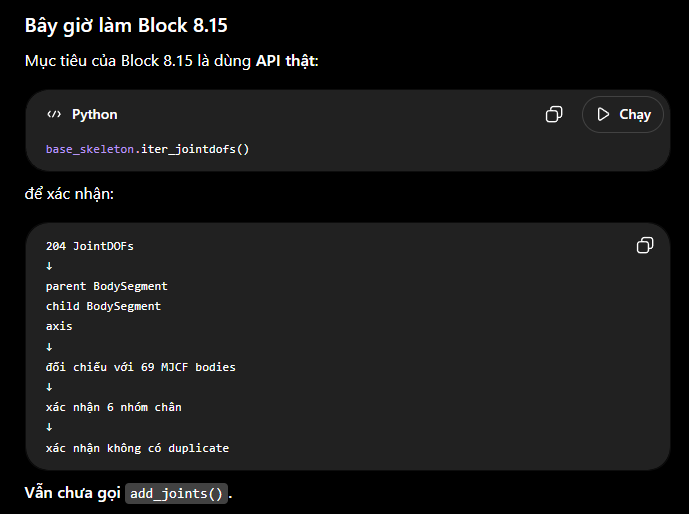

In [24]:
# ======================================================================
# BLOCK 8.15 — COMPLETE READ-ONLY JOINTDOF -> MJCF STRUCTURAL AUDIT
#
# IMPORTANT:
#   - Uses the confirmed API: Skeleton.iter_jointdofs()
#   - DOES NOT call add_joints()
#   - DOES NOT assign fly.skeleton
#   - DOES NOT mutate MJCF
# ======================================================================

import json
from collections import Counter, defaultdict

print("=" * 78)
print("BLOCK 8.15 — COMPLETE READ-ONLY JOINTDOF -> MJCF STRUCTURAL AUDIT")
print("=" * 78)


# ======================================================================
# 0. SAFETY CHECK
# ======================================================================

print("\n=== 0. SAFETY CHECK ===")

assert fly is not None

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton BEFORE:", getattr(fly, "skeleton", None))

assert getattr(fly, "skeleton", None) is None, (
    "[STOP] fly.skeleton is already initialized."
)

print("[PASS] fly.skeleton is None.")
print("[PASS] add_joints() will NOT be called.")
print("[PASS] No fly.skeleton assignment.")


# ======================================================================
# 1. GET LOCAL BASE SKELETON
# ======================================================================

print("\n=== 1. LOCAL BASE SKELETON ===")

base_skeleton = fly._get_base_skeleton()

print("base_skeleton:", base_skeleton)
print("type:", type(base_skeleton))

assert getattr(fly, "skeleton", None) is None

print("[PASS] Local Skeleton obtained.")
print("[PASS] fly.skeleton remains None.")


# ======================================================================
# 2. SKELETON METADATA
# ======================================================================

print("\n=== 2. SKELETON METADATA ===")

axis_order = getattr(
    base_skeleton,
    "axis_order",
    None
)

body_segments = getattr(
    base_skeleton,
    "body_segments",
    []
)

anatomical_joints = getattr(
    base_skeleton,
    "anatomical_joints",
    []
)

print("Axis order:")
print(" ", axis_order)

print("Body segments:")
print(" ", len(body_segments))

print("Anatomical joints:")
print(" ", len(anatomical_joints))

print(
    "[PASS] Axis order:",
    axis_order
)

print(
    "[INFO] BodySegment count:",
    len(body_segments)
)

print(
    "[INFO] AnatomicalJoint count:",
    len(anatomical_joints)
)


# ======================================================================
# 3. EXTRACT ALL JOINTDOFs USING CONFIRMED API
# ======================================================================

print("\n=== 3. EXTRACT ALL JOINTDOFs ===")

assert hasattr(
    base_skeleton,
    "iter_jointdofs"
), (
    "[FAIL] iter_jointdofs() not available."
)

print(
    "API:",
    base_skeleton.iter_jointdofs
)

jointdofs = list(
    base_skeleton.iter_jointdofs()
)

print(
    "Total JointDOFs:",
    len(jointdofs)
)

assert len(jointdofs) == 204, (
    f"[FAIL] Expected 204 JointDOFs, "
    f"got {len(jointdofs)}"
)

print("[PASS] Exactly 204 JointDOFs found.")


# ======================================================================
# 4. JOINTDOF NAME / STRUCTURE AUDIT
# ======================================================================

print("\n=== 4. JOINTDOF STRUCTURE AUDIT ===")

jointdof_records = []

for idx, jdof in enumerate(jointdofs):

    parent_obj = getattr(
        jdof,
        "parent",
        None
    )

    child_obj = getattr(
        jdof,
        "child",
        None
    )

    axis_obj = getattr(
        jdof,
        "axis",
        None
    )

    parent_name = getattr(
        parent_obj,
        "name",
        str(parent_obj)
    )

    child_name = getattr(
        child_obj,
        "name",
        str(child_obj)
    )

    axis_name = getattr(
        axis_obj,
        "value",
        str(axis_obj)
    )

    try:
        jdof_name = jdof.name
    except Exception:
        jdof_name = (
            f"{parent_name}-{child_name}-{axis_name}"
        )

    jointdof_records.append({
        "index": idx,
        "name": str(jdof_name),
        "parent": str(parent_name),
        "child": str(child_name),
        "axis": str(axis_name),
        "object": jdof,
    })


print(
    f"{'IDX':>5} | "
    f"{'PARENT':<25} | "
    f"{'CHILD':<25} | "
    f"{'AXIS':<10} | NAME"
)

print("-" * 115)

for record in jointdof_records[:30]:

    print(
        f"{record['index']:5d} | "
        f"{record['parent']:<25} | "
        f"{record['child']:<25} | "
        f"{record['axis']:<10} | "
        f"{record['name']}"
    )

print(
    "\n[INFO] Showing first 30 of 204 JointDOFs."
)


# ======================================================================
# 5. UNIQUE NAME CHECK
# ======================================================================

print("\n=== 5. UNIQUE JointDOF NAME CHECK ===")

names = [
    r["name"]
    for r in jointdof_records
]

unique_names = set(names)

print(
    "Total names:",
    len(names)
)

print(
    "Unique names:",
    len(unique_names)
)

if len(names) == len(unique_names):

    print(
        "[PASS] All JointDOF names are unique."
    )

else:

    duplicates = [
        name
        for name, count in Counter(names).items()
        if count > 1
    ]

    print(
        "[FAIL] Duplicate JointDOF names:"
    )

    for name in duplicates:
        print(
            " ",
            name
        )

    raise AssertionError(
        "Duplicate JointDOF names detected."
    )


# ======================================================================
# 6. AXIS DISTRIBUTION
# ======================================================================

print("\n=== 6. AXIS DISTRIBUTION ===")

axis_counts = Counter(
    r["axis"]
    for r in jointdof_records
)

for axis, count in sorted(
    axis_counts.items()
):

    print(
        f"{axis:<10}: {count}"
    )

print(
    "Total:",
    sum(axis_counts.values())
)


# ======================================================================
# 7. PARENT -> CHILD STRUCTURAL UNIQUENESS
# ======================================================================

print("\n=== 7. ANATOMICAL JOINT / AXIS STRUCTURE ===")

pair_to_axes = defaultdict(list)

for r in jointdof_records:

    pair = (
        r["parent"],
        r["child"]
    )

    pair_to_axes[pair].append(
        r["axis"]
    )

print(
    "Unique parent -> child anatomical pairs:",
    len(pair_to_axes)
)

multi_axis_count = 0

for pair, axes in pair_to_axes.items():

    if len(axes) > 1:

        multi_axis_count += 1

print(
    "Parent-child pairs with multiple rotational DOFs:",
    multi_axis_count
)

print(
    "\nFirst 20 anatomical joint pairs:"
)

for i, (pair, axes) in enumerate(
    list(pair_to_axes.items())[:20]
):

    print(
        f"  {i:02d}. "
        f"{pair[0]} -> {pair[1]} : "
        f"{axes}"
    )


# ======================================================================
# 8. BODYSEGMENT -> MJCF BODY COVERAGE
# ======================================================================

print("\n=== 8. BODYSEGMENT -> MJCF BODY COVERAGE ===")

body_mapping = getattr(
    fly,
    "bodyseg_to_mjcfbody",
    {}
)

print(
    "MJCF body mapping length:",
    len(body_mapping)
)

assert len(body_mapping) == 69, (
    f"[FAIL] Expected 69 MJCF body mappings, "
    f"got {len(body_mapping)}"
)

print(
    "[PASS] 69 BodySegments have MJCF body mappings."
)


# ======================================================================
# 9. EVERY JointDOF PARENT/CHILD MUST MAP TO MJCF BODY
# ======================================================================

print("\n=== 9. JointDOF -> MJCF BODY COVERAGE ===")

mapped_body_segments = set(
    body_mapping.keys()
)

missing_parent = []
missing_child = []

for r in jointdof_records:

    jdof = r["object"]

    parent_obj = getattr(
        jdof,
        "parent",
        None
    )

    child_obj = getattr(
        jdof,
        "child",
        None
    )

    if parent_obj not in mapped_body_segments:

        missing_parent.append(
            r
        )

    if child_obj not in mapped_body_segments:

        missing_child.append(
            r
        )

print(
    "Missing parent MJCF bodies:",
    len(missing_parent)
)

print(
    "Missing child MJCF bodies:",
    len(missing_child)
)

assert len(missing_parent) == 0, (
    "[FAIL] Some JointDOF parents have no MJCF body."
)

assert len(missing_child) == 0, (
    "[FAIL] Some JointDOF children have no MJCF body."
)

print(
    "[PASS] Every JointDOF parent has an MJCF body."
)

print(
    "[PASS] Every JointDOF child has an MJCF body."
)


# ======================================================================
# 10. LEG GROUPING
# ======================================================================

print("\n=== 10. SIX-LEG JointDOF COVERAGE ===")

leg_patterns = {
    "LF": ("lf_",),
    "LM": ("lm_",),
    "LH": ("lh_",),
    "RF": ("rf_",),
    "RM": ("rm_",),
    "RH": ("rh_",),
}

leg_groups = defaultdict(list)
non_leg = []

for r in jointdof_records:

    parent = r["parent"].lower()
    child = r["child"].lower()

    combined = (
        parent + " " + child
    )

    matched_leg = None

    for leg_name, patterns in leg_patterns.items():

        if any(
            pattern in combined
            for pattern in patterns
        ):

            matched_leg = leg_name
            break

    if matched_leg is None:

        non_leg.append(r)

    else:

        leg_groups[
            matched_leg
        ].append(r)


for leg_name in (
    "LF",
    "LM",
    "LH",
    "RF",
    "RM",
    "RH",
):

    print(
        f"{leg_name:<5}: "
        f"{len(leg_groups[leg_name]):>3} DOFs"
    )

print(
    f"{'NON_LEG':<5}: "
    f"{len(non_leg):>3} DOFs"
)

leg_total = sum(
    len(v)
    for v in leg_groups.values()
)

print(
    "\nLeg total:",
    leg_total
)

print(
    "Leg + non-leg:",
    leg_total + len(non_leg)
)


# ======================================================================
# 11. EXPECTED 24 DOF / LEG CHECK
# ======================================================================

print("\n=== 11. PER-LEG 24 DOF CHECK ===")

all_legs_24 = True

for leg_name in (
    "LF",
    "LM",
    "LH",
    "RF",
    "RM",
    "RH",
):

    count = len(
        leg_groups[leg_name]
    )

    if count == 24:

        print(
            f"[PASS] {leg_name}: 24 DOFs"
        )

    else:

        print(
            f"[WARNING] {leg_name}: "
            f"{count} DOFs"
        )

        all_legs_24 = False


if all_legs_24:

    print(
        "[PASS] All six legs contain exactly 24 DOFs."
    )


# ======================================================================
# 12. RECONSTRUCT JointDOF NAMES
# ======================================================================

print("\n=== 12. JointDOF NAME ROUND-TRIP ===")

roundtrip_failures = []

for r in jointdof_records:

    expected = (
        f"{r['parent']}-"
        f"{r['child']}-"
        f"{r['axis']}"
    )

    if r["name"] != expected:

        roundtrip_failures.append(
            (
                r["index"],
                r["name"],
                expected
            )
        )


print(
    "Round-trip failures:",
    len(roundtrip_failures)
)

if not roundtrip_failures:

    print(
        "[PASS] All JointDOF names match "
        "parent-child-axis structure."
    )

else:

    print(
        "[WARNING] Some JointDOF names differ "
        "from reconstructed form."
    )

    for item in roundtrip_failures[:20]:

        print(
            " ",
            item
        )


# ======================================================================
# 13. CURRENT MJCF JOINT MAPPING MUST REMAIN EMPTY
# ======================================================================

print("\n=== 13. PRE-MATERIALIZATION MAPPING CHECK ===")

joint_to_mjcf = getattr(
    fly,
    "jointdof_to_mjcfjoint",
    {}
)

joint_to_neutral = getattr(
    fly,
    "jointdof_to_neutralangle",
    {}
)

actuator_mapping = getattr(
    fly,
    "jointdof_to_mjcfactuator_by_type",
    {}
)

print(
    "JointDOF -> MJCF joint:",
    len(joint_to_mjcf)
)

print(
    "JointDOF -> neutral angle:",
    len(joint_to_neutral)
)

print(
    "Actuator mapping:"
)

for actuator_type, mapping in actuator_mapping.items():

    print(
        f"  {actuator_type}: {len(mapping)}"
    )

assert len(joint_to_mjcf) == 0
assert len(joint_to_neutral) == 0

print(
    "[PASS] No joints have been materialized."
)

print(
    "[PASS] No neutral-angle mapping exists yet."
)


# ======================================================================
# 14. FINAL SAFETY CHECK
# ======================================================================

print("\n=== 14. FINAL SAFETY CHECK ===")

print(
    "fly.skeleton AFTER:",
    getattr(fly, "skeleton", None)
)

assert getattr(fly, "skeleton", None) is None

print(
    "[PASS] fly.skeleton remains None."
)

print(
    "[PASS] add_joints() was NOT called."
)

print(
    "[PASS] No intentional MJCF mutation occurred."
)


# ======================================================================
# 15. FINAL SUMMARY
# ======================================================================

print("\n" + "=" * 78)
print("BLOCK 8.15 COMPLETE")
print("=" * 78)

print(
    "Base Skeleton:",
    type(base_skeleton)
)

print(
    "Axis Order:",
    axis_order
)

print(
    "BodySegments:",
    len(body_segments)
)

print(
    "AnatomicalJoints:",
    len(anatomical_joints)
)

print(
    "JointDOFs:",
    len(jointdofs)
)

print(
    "MJCF Body mappings:",
    len(body_mapping)
)

print(
    "MJCF Joint mappings:",
    len(joint_to_mjcf)
)

print(
    "Neutral mappings:",
    len(joint_to_neutral)
)

print(
    "fly.skeleton:",
    getattr(fly, "skeleton", None)
)

print(
    "Integrity:",
    (
        len(jointdofs) == 204
        and len(body_mapping) == 69
        and len(joint_to_mjcf) == 0
        and len(joint_to_neutral) == 0
        and getattr(fly, "skeleton", None) is None
        and len(missing_parent) == 0
        and len(missing_child) == 0
    )
)

print("=" * 78)

BLOCK 8.15 — COMPLETE READ-ONLY JOINTDOF -> MJCF STRUCTURAL AUDIT

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton BEFORE: None
[PASS] fly.skeleton is None.
[PASS] add_joints() will NOT be called.
[PASS] No fly.skeleton assignment.

=== 1. LOCAL BASE SKELETON ===
base_skeleton: <flygym.anatomy.Skeleton object at 0x7a9d4fea08f0>
type: <class 'flygym.anatomy.Skeleton'>
[PASS] Local Skeleton obtained.
[PASS] fly.skeleton remains None.

=== 2. SKELETON METADATA ===
Axis order:
  AxisOrder.PITCH_ROLL_YAW
Body segments:
  69
Anatomical joints:
  68
[PASS] Axis order: AxisOrder.PITCH_ROLL_YAW
[INFO] BodySegment count: 69
[INFO] AnatomicalJoint count: 68

=== 3. EXTRACT ALL JOINTDOFs ===
API: <bound method Skeleton.iter_jointdofs of <flygym.anatomy.Skeleton object at 0x7a9d4fea08f0>>
Total JointDOFs: 204
[PASS] Exactly 204 JointDOFs found.

=== 4. JOINTDOF STRUCTUR

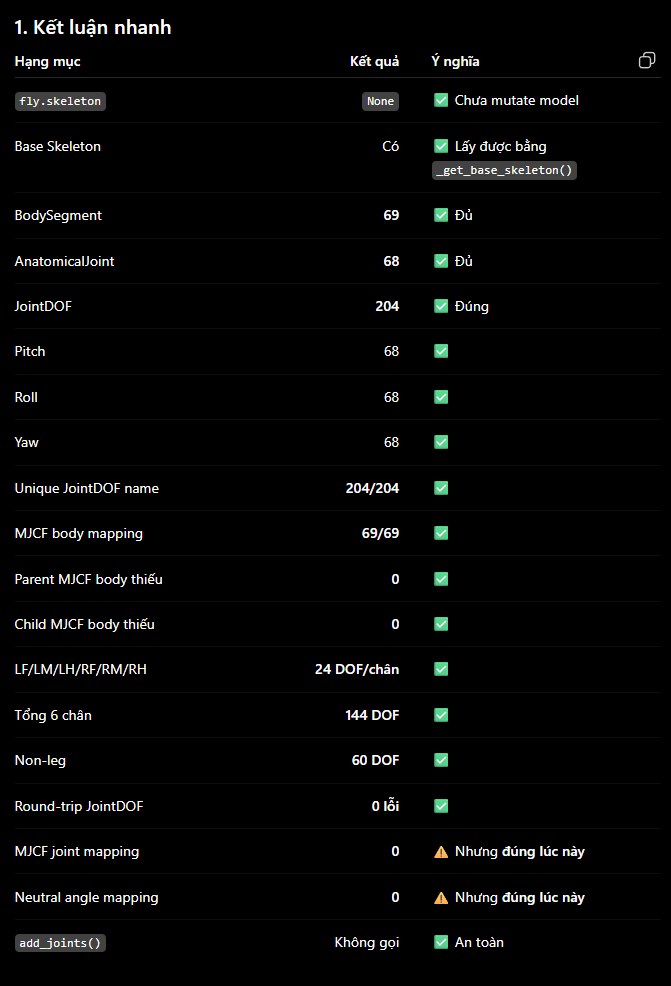

## BLOCK 8.16 — READ-ONLY TRACE: JointDOF → MJCF JOINT CREATION PATH

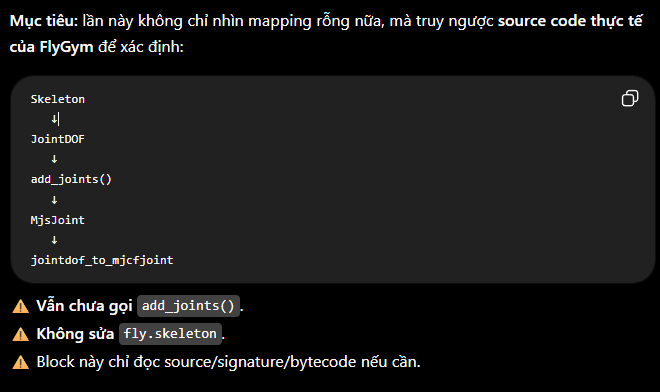

In [25]:
# ================================================================
# BLOCK 8.16 — READ-ONLY TRACE:
# JointDOF -> MJCF JOINT CREATION PATH
# ================================================================

import inspect
import dis
import textwrap

print("=" * 72)
print("BLOCK 8.16 — READ-ONLY TRACE: JointDOF -> MJCF JOINT PATH")
print("=" * 72)

# ================================================================
# 0. SAFETY CHECK
# ================================================================

print("\n=== 0. SAFETY CHECK ===")

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton BEFORE:", getattr(fly, "skeleton", "<MISSING>"))

if getattr(fly, "skeleton", "<MISSING>") is not None:
    raise RuntimeError(
        "SAFETY STOP: fly.skeleton is not None. "
        "Block 8.16 requires pre-materialization state."
    )

print("[PASS] fly.skeleton is None.")
print("[PASS] This block will NOT call add_joints().")
print("[PASS] This block will NOT assign fly.skeleton.")
print("[PASS] This block will NOT mutate MJCF.")

# ================================================================
# 1. IDENTIFY BASE FLY CLASS
# ================================================================

print("\n=== 1. BASE FLY CLASS ===")

fly_cls = type(fly)

print("Fly class:")
print(fly_cls)

print("\nMRO:")
for cls in fly_cls.__mro__:
    print("  ", cls)

# Find class defining add_joints
add_joints_owner = None

for cls in fly_cls.__mro__:
    if "add_joints" in cls.__dict__:
        add_joints_owner = cls
        break

print("\nadd_joints owner:")
print(add_joints_owner)

if add_joints_owner is None:
    raise RuntimeError("Could not locate add_joints() in MRO.")

print("[PASS] add_joints() owner located.")

# ================================================================
# 2. INSPECT add_joints() SIGNATURE
# ================================================================

print("\n=== 2. add_joints() SIGNATURE ===")

add_joints_method = getattr(add_joints_owner, "add_joints")

print("Object:")
print(add_joints_method)

try:
    print("\nSignature:")
    print(inspect.signature(add_joints_method))
except Exception as e:
    print("Signature inspection failed:", repr(e))

# ================================================================
# 3. SOURCE CODE OF add_joints()
# ================================================================

print("\n=== 3. add_joints() SOURCE CODE ===")

try:
    source = inspect.getsource(add_joints_method)

    print(source)

    print("\n[PASS] Source code retrieved.")

except Exception as e:
    print("[WARN] Could not retrieve source code.")
    print("Reason:", repr(e))

# ================================================================
# 4. LOCATE IMPORTANT TOKENS IN SOURCE
# ================================================================

print("\n=== 4. SOURCE TOKEN AUDIT ===")

try:
    source_lower = source.lower()

    tokens = [
        "jointdof",
        "mjsjoint",
        "jointdof_to_mjcfjoint",
        "jointdof_to_neutralangle",
        "mjcf",
        "add_joint",
        "hinge",
        "axis",
        "parent",
        "child",
        "neutral",
    ]

    for token in tokens:
        count = source_lower.count(token.lower())
        print(f"{token:35s}: {count}")

except Exception as e:
    print("[WARN] Source token audit unavailable:", repr(e))

# ================================================================
# 5. DISASSEMBLE add_joints()
# ================================================================

print("\n=== 5. BYTECODE AUDIT ===")

try:
    dis.dis(add_joints_method)
    print("\n[PASS] Bytecode disassembly completed.")

except Exception as e:
    print("[WARN] Bytecode disassembly failed:")
    print(repr(e))

# ================================================================
# 6. INSPECT RELATED METHODS
# ================================================================

print("\n=== 6. RELATED METHOD SIGNATURES ===")

related_methods = [
    "_get_base_skeleton",
    "get_jointdofs_order",
    "get_actuated_jointdofs_order",
    "add_joint_sites",
    "add_actuators",
    "_rebuild_neutral_keyframe",
    "_get_neutral_qpos",
    "_get_neutral_ctrl",
]

for name in related_methods:

    print("\n---", name, "---")

    owner = None
    method = None

    for cls in fly_cls.__mro__:
        if name in cls.__dict__:
            owner = cls
            method = cls.__dict__[name]
            break

    print("Owner:", owner)

    if method is None:
        print("[NOT FOUND]")
        continue

    try:
        print("Signature:", inspect.signature(method))
    except Exception as e:
        print("Signature: <unavailable>", repr(e))

# ================================================================
# 7. INSPECT MJCF ROOT TYPE
# ================================================================

print("\n=== 7. MJCF ROOT TYPE ===")

mjcf_root = getattr(fly, "mjcf_root", None)

print("fly.mjcf_root:")
print(mjcf_root)

print("Type:")
print(type(mjcf_root))

print("\nRelevant MjSpec methods/attributes:")

if mjcf_root is not None:

    names = [
        name
        for name in dir(mjcf_root)
        if any(
            keyword in name.lower()
            for keyword in [
                "joint",
                "body",
                "find",
                "add",
                "attach",
            ]
        )
    ]

    for name in sorted(names):
        try:
            value = getattr(mjcf_root, name)

            if callable(value):
                try:
                    sig = inspect.signature(value)
                except Exception:
                    sig = "<signature unavailable>"

                print(f"{name:35s} CALLABLE {sig}")

            else:
                print(f"{name:35s} {type(value)}")

        except Exception as e:
            print(f"{name:35s} <inspection failed: {e!r}>")

# ================================================================
# 8. EXISTING MAPPING STATE
# ================================================================

print("\n=== 8. CURRENT MAPPING STATE ===")

mapping = getattr(fly, "jointdof_to_mjcfjoint", None)

print("jointdof_to_mjcfjoint:")
print(mapping)

if mapping is not None:
    print("Type:", type(mapping))
    print("Length:", len(mapping))

neutral_mapping = getattr(fly, "jointdof_to_neutralangle", None)

print("\njointdof_to_neutralangle:")
print(neutral_mapping)

if neutral_mapping is not None:
    print("Type:", type(neutral_mapping))
    print("Length:", len(neutral_mapping))

# ================================================================
# 9. DO NOT MATERIALIZE — VERIFY PRE-MATERIALIZATION STATE
# ================================================================

print("\n=== 9. PRE-MATERIALIZATION VERIFICATION ===")

if getattr(fly, "skeleton", None) is not None:
    raise RuntimeError(
        "SAFETY FAILURE: fly.skeleton changed during Block 8.16."
    )

print("fly.skeleton:", fly.skeleton)

print("[PASS] fly.skeleton remains None.")

if mapping is not None and len(mapping) != 0:
    print(
        "[WARNING] jointdof_to_mjcfjoint is no longer empty."
    )
else:
    print(
        "[PASS] jointdof_to_mjcfjoint remains empty."
    )

if neutral_mapping is not None and len(neutral_mapping) != 0:
    print(
        "[WARNING] jointdof_to_neutralangle is no longer empty."
    )
else:
    print(
        "[PASS] jointdof_to_neutralangle remains empty."
    )

print("\n[PASS] No add_joints() call was performed.")
print("[PASS] No fly.skeleton assignment was performed.")
print("[PASS] Block 8.16 is read-only.")

print("\n" + "=" * 72)
print("BLOCK 8.16 COMPLETE")
print("=" * 72)

BLOCK 8.16 — READ-ONLY TRACE: JointDOF -> MJCF JOINT PATH

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton BEFORE: None
[PASS] fly.skeleton is None.
[PASS] This block will NOT call add_joints().
[PASS] This block will NOT assign fly.skeleton.
[PASS] This block will NOT mutate MJCF.

=== 1. BASE FLY CLASS ===
Fly class:
<class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

MRO:
   <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
   <class 'flygym.compose.fly.base_fly.BaseFly'>
   <class 'flygym.compose.base.BaseCompositionElement'>
   <class 'abc.ABC'>
   <class 'object'>

add_joints owner:
<class 'flygym.compose.fly.base_fly.BaseFly'>
[PASS] add_joints() owner located.

=== 2. add_joints() SIGNATURE ===
Object:
<function BaseFly.add_joints at 0x7a9d5dfba700>

Signature:
(self, skeleton: flygym.anatomy.Skeleton, neutral_pose: flygym.compose.pose.Kine

## BLOCK 8.17 — READ-ONLY TRACE: JointDOF → ACTUATOR

In [26]:
# ================================================================
# BLOCK 8.17 — READ-ONLY TRACE: JointDOF -> ACTUATOR PATH
# ================================================================

import inspect
import dis
import re

print("=" * 80)
print("BLOCK 8.17 — READ-ONLY TRACE: JointDOF -> ACTUATOR PATH")
print("=" * 80)


# ================================================================
# 0. SAFETY CHECK
# ================================================================

print("\n=== 0. SAFETY CHECK ===")

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton BEFORE:", fly.skeleton)

assert fly.skeleton is None

print("[PASS] fly.skeleton is None.")
print("[PASS] This block will NOT call add_joints().")
print("[PASS] This block will NOT call add_actuators().")
print("[PASS] This block will NOT assign fly.skeleton.")
print("[PASS] This block will NOT mutate MJCF.")


# ================================================================
# 1. LOCATE add_actuators()
# ================================================================

print("\n=== 1. add_actuators() OWNER ===")

fly_cls = type(fly)

add_actuators_owner = None

for cls in inspect.getmro(fly_cls):
    if "add_actuators" in cls.__dict__:
        add_actuators_owner = cls
        break

print("Fly class:", fly_cls)
print("MRO:")

for cls in inspect.getmro(fly_cls):
    print("   ", cls)

print("add_actuators owner:", add_actuators_owner)

assert add_actuators_owner is not None

print("[PASS] add_actuators() owner located.")


# ================================================================
# 2. SIGNATURE
# ================================================================

print("\n=== 2. add_actuators() SIGNATURE ===")

add_actuators = add_actuators_owner.__dict__["add_actuators"]

print("Object:", add_actuators)
print("Signature:", inspect.signature(add_actuators))

print("\nDocstring:")
print(inspect.getdoc(add_actuators))


# ================================================================
# 3. SOURCE CODE
# ================================================================

print("\n=== 3. add_actuators() SOURCE CODE ===")

try:
    source = inspect.getsource(add_actuators)
    print(source)

    print("[PASS] Source code retrieved.")

except Exception as e:
    source = None
    print("[WARN] Could not retrieve source.")
    print("Reason:", repr(e))


# ================================================================
# 4. SOURCE TOKEN AUDIT
# ================================================================

print("\n=== 4. SOURCE TOKEN AUDIT ===")

if source is not None:

    tokens = [
        "jointdof",
        "actuator",
        "ActuatorType",
        "jointdof_to_neutralaction_by_type",
        "jointdof_to_mjcfjoint",
        "add_actuator",
        "ctrlrange",
        "forcelimited",
        "forcerange",
        "neutral_input",
        "neutral_action",
        "joint",
        "gear",
        "gain",
        "bias",
        "type",
    ]

    for token in tokens:
        count = source.lower().count(token.lower())
        print(f"{token:35s}: {count}")

else:
    print("[INFO] Source unavailable; skipping token audit.")


# ================================================================
# 5. BYTECODE AUDIT
# ================================================================

print("\n=== 5. BYTECODE AUDIT ===")

try:
    dis.dis(add_actuators)
    print("[PASS] Bytecode disassembly completed.")

except Exception as e:
    print("[WARN] Bytecode disassembly failed.")
    print("Reason:", repr(e))


# ================================================================
# 6. RELATED METHOD SIGNATURES
# ================================================================

print("\n=== 6. RELATED METHOD SIGNATURES ===")

related_methods = [
    "get_actuated_jointdofs_order",
    "_get_neutral_ctrl",
    "_get_neutral_qpos",
    "_rebuild_neutral_keyframe",
    "add_joints",
]

for method_name in related_methods:

    print(f"\n--- {method_name} ---")

    owner = None
    method = None

    for cls in inspect.getmro(fly_cls):
        if method_name in cls.__dict__:
            owner = cls
            method = cls.__dict__[method_name]
            break

    if method is None:
        print("[INFO] Method not found.")
        continue

    print("Owner:", owner)
    print("Object:", method)

    try:
        print("Signature:", inspect.signature(method))
    except Exception as e:
        print("Signature unavailable:", repr(e))


# ================================================================
# 7. CURRENT ACTUATOR MAPPING STATE
# ================================================================

print("\n=== 7. CURRENT ACTUATOR MAPPING STATE ===")

mapping_name = "jointdof_to_neutralaction_by_type"

if hasattr(fly, mapping_name):

    mapping = getattr(fly, mapping_name)

    print(f"{mapping_name}:")
    print(mapping)

    print("Type:", type(mapping))

    if hasattr(mapping, "items"):

        total_entries = 0

        for actuator_type, submap in mapping.items():

            try:
                n = len(submap)
            except Exception:
                n = "UNKNOWN"

            print(
                f"{actuator_type}: "
                f"type={type(submap)}, "
                f"length={n}"
            )

            if isinstance(n, int):
                total_entries += n

        print("Total actuator mapping entries:", total_entries)

else:

    print(f"[INFO] {mapping_name} does not exist.")


# ================================================================
# 8. JOINTDOF -> MJCF JOINT STATE
# ================================================================

print("\n=== 8. JOINTDOF -> MJCF JOINT STATE ===")

joint_mapping = getattr(
    fly,
    "jointdof_to_mjcfjoint",
    None
)

neutral_mapping = getattr(
    fly,
    "jointdof_to_neutralangle",
    None
)

print(
    "jointdof_to_mjcfjoint:",
    joint_mapping
)

print(
    "jointdof_to_neutralangle:",
    neutral_mapping
)

if isinstance(joint_mapping, dict):
    print(
        "JointDOF -> MJCF joint length:",
        len(joint_mapping)
    )

if isinstance(neutral_mapping, dict):
    print(
        "JointDOF -> neutral angle length:",
        len(neutral_mapping)
    )


# ================================================================
# 9. ACTUATOR TYPES
# ================================================================

print("\n=== 9. ACTUATOR TYPE ENUMERATION ===")

try:

    actuator_enum = getattr(
        add_actuators_owner,
        "ActuatorType",
        None
    )

    if actuator_enum is not None:

        print("ActuatorType found on owner:")
        print(actuator_enum)

    else:

        # Search module globals / class attributes
        module = inspect.getmodule(add_actuators)

        if module is not None:

            actuator_enum = getattr(
                module,
                "ActuatorType",
                None
            )

        print("ActuatorType:", actuator_enum)

    if actuator_enum is not None:

        try:

            for item in actuator_enum:

                print(
                    f"{item!r} -> "
                    f"name={getattr(item, 'name', None)}, "
                    f"value={getattr(item, 'value', None)}"
                )

        except Exception as e:

            print(
                "[WARN] Could not iterate ActuatorType:",
                repr(e)
            )

except Exception as e:

    print(
        "[WARN] ActuatorType inspection failed:",
        repr(e)
    )


# ================================================================
# 10. MJCF ROOT ACTUATOR STATE
# ================================================================

print("\n=== 10. MJCF ROOT ACTUATOR STATE ===")

mjcf_root = getattr(fly, "mjcf_root", None)

print("fly.mjcf_root:", mjcf_root)
print("type:", type(mjcf_root))

if mjcf_root is not None:

    print(
        "Has 'actuators' attribute:",
        hasattr(mjcf_root, "actuators")
    )

    if hasattr(mjcf_root, "actuators"):

        try:
            actuators = mjcf_root.actuators

            print(
                "mjcf_root.actuators:",
                actuators
            )

            print(
                "type:",
                type(actuators)
            )

            try:
                print(
                    "length:",
                    len(actuators)
                )
            except Exception:
                print(
                    "length: <unavailable>"
                )

        except Exception as e:

            print(
                "[WARN] Could not inspect actuators:",
                repr(e)
            )

else:

    print("[INFO] mjcf_root unavailable.")


# ================================================================
# 11. FINAL SAFETY CHECK
# ================================================================

print("\n=== 11. FINAL SAFETY CHECK ===")

print("fly.skeleton AFTER:", fly.skeleton)

assert fly.skeleton is None

print("[PASS] fly.skeleton remains None.")
print("[PASS] No add_joints() call was performed.")
print("[PASS] No add_actuators() call was performed.")
print("[PASS] No fly.skeleton assignment was performed.")
print("[PASS] Block 8.17 is read-only.")

print("\n" + "=" * 80)
print("BLOCK 8.17 COMPLETE")
print("=" * 80)

BLOCK 8.17 — READ-ONLY TRACE: JointDOF -> ACTUATOR PATH

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton BEFORE: None
[PASS] fly.skeleton is None.
[PASS] This block will NOT call add_joints().
[PASS] This block will NOT call add_actuators().
[PASS] This block will NOT assign fly.skeleton.
[PASS] This block will NOT mutate MJCF.

=== 1. add_actuators() OWNER ===
Fly class: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
MRO:
    <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
    <class 'flygym.compose.fly.base_fly.BaseFly'>
    <class 'flygym.compose.base.BaseCompositionElement'>
    <class 'abc.ABC'>
    <class 'object'>
add_actuators owner: <class 'flygym.compose.fly.base_fly.BaseFly'>
[PASS] add_actuators() owner located.

=== 2. add_actuators() SIGNATURE ===
Object: <function BaseFly.add_actuators at 0x7a9d5dfba840>
Signature: (self, joint

## BLOCK 8.18 — READ-ONLY AUDIT: EXISTING MJCF JOINT INVENTORY vs SKELETON JointDOFs

In [27]:
# ================================================================
# BLOCK 8.18
# READ-ONLY AUDIT:
# EXISTING MJCF JOINT INVENTORY vs SKELETON JointDOFs
#
# SAFETY:
# - DO NOT call fly.add_joints()
# - DO NOT call fly.add_actuators()
# - DO NOT assign fly.skeleton
# - DO NOT mutate MJCF
# ================================================================

import inspect
from collections import Counter, defaultdict

print("=" * 80)
print("BLOCK 8.18 — READ-ONLY AUDIT: MJCF JOINT INVENTORY vs SKELETON JointDOFs")
print("=" * 80)


# ================================================================
# 0. SAFETY CHECK
# ================================================================

print("\n=== 0. SAFETY CHECK ===")

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton BEFORE:", fly.skeleton)

assert fly.skeleton is None, (
    "SAFETY FAILURE: fly.skeleton is not None!"
)

print("[PASS] fly.skeleton is None.")
print("[PASS] This block will NOT call add_joints().")
print("[PASS] This block will NOT call add_actuators().")
print("[PASS] This block will NOT assign fly.skeleton.")
print("[PASS] This block will NOT mutate MJCF.")


# ================================================================
# 1. LOCAL BASE SKELETON
# ================================================================

print("\n=== 1. LOCAL BASE SKELETON ===")

base_skeleton = fly._get_base_skeleton()

print("base_skeleton:", base_skeleton)
print("type:", type(base_skeleton))

assert base_skeleton is not None
print("[PASS] Local base Skeleton obtained.")
print("[PASS] fly.skeleton remains None.")


# ================================================================
# 2. EXTRACT SKELETON JointDOFs
# ================================================================

print("\n=== 2. SKELETON JointDOF INVENTORY ===")

skeleton_jointdofs = list(
    base_skeleton.iter_jointdofs(fly.root_segment)
)

skeleton_jointdof_names = [
    jd.name for jd in skeleton_jointdofs
]

print("Skeleton JointDOFs:", len(skeleton_jointdofs))
print("Unique JointDOF names:", len(set(skeleton_jointdof_names)))

assert len(skeleton_jointdofs) == 204
assert len(set(skeleton_jointdof_names)) == 204

print("[PASS] Skeleton contains exactly 204 unique JointDOFs.")


# ================================================================
# 3. MJCF ROOT
# ================================================================

print("\n=== 3. MJCF ROOT ===")

mjcf_root = fly.mjcf_root

print("mjcf_root:", mjcf_root)
print("type:", type(mjcf_root))

assert mjcf_root is not None

print("[PASS] MjSpec obtained.")


# ================================================================
# 4. EXISTING MJCF JOINT INVENTORY
# ================================================================

print("\n=== 4. EXISTING MJCF JOINT INVENTORY ===")

mjcf_joints = list(getattr(mjcf_root, "joints", []))

print("MJCF root joints:", len(mjcf_joints))

print("\nFirst MJCF joints:")

for i, joint in enumerate(mjcf_joints[:30]):

    # MjsJoint normally exposes name/type/axis.
    # Use safe getattr so this audit remains read-only
    # even if a particular MuJoCo build exposes fields differently.

    name = getattr(joint, "name", "<NO_NAME>")
    joint_type = getattr(joint, "type", "<NO_TYPE>")
    axis = getattr(joint, "axis", "<NO_AXIS>")

    print(
        f"[{i:03d}] "
        f"name={name!r} | "
        f"type={joint_type!r} | "
        f"axis={axis!r}"
    )

if len(mjcf_joints) > 30:
    print(
        f"\n[INFO] Showing first 30 of "
        f"{len(mjcf_joints)} MJCF joints."
    )


# ================================================================
# 5. MJCF JOINT NAMES
# ================================================================

print("\n=== 5. MJCF JOINT NAME ANALYSIS ===")

mjcf_joint_names = [
    getattr(joint, "name", None)
    for joint in mjcf_joints
]

named_mjcf_joint_names = [
    name for name in mjcf_joint_names
    if name is not None
]

print("Total MJCF joint objects:", len(mjcf_joints))
print("MJCF joints with names:", len(named_mjcf_joint_names))
print(
    "Unique named MJCF joint names:",
    len(set(named_mjcf_joint_names))
)

duplicate_mjcf_names = [
    name
    for name, count in Counter(named_mjcf_joint_names).items()
    if count > 1
]

print(
    "Duplicate MJCF joint names:",
    len(duplicate_mjcf_names)
)

if duplicate_mjcf_names:
    print("[WARN] Duplicate MJCF joint names detected:")
    for name in duplicate_mjcf_names:
        print("   ", name)
else:
    print("[PASS] No duplicate named MJCF joints detected.")


# ================================================================
# 6. DIRECT NAME OVERLAP:
#    MJCF JOINTS vs SKELETON JointDOFs
# ================================================================

print("\n=== 6. NAME OVERLAP: MJCF JOINTS vs SKELETON JointDOFs ===")

skeleton_name_set = set(skeleton_jointdof_names)
mjcf_name_set = set(named_mjcf_joint_names)

overlap = sorted(
    skeleton_name_set.intersection(mjcf_name_set)
)

skeleton_only = sorted(
    skeleton_name_set - mjcf_name_set
)

mjcf_only = sorted(
    mjcf_name_set - skeleton_name_set
)

print("Skeleton JointDOF names:", len(skeleton_name_set))
print("MJCF named joint names:", len(mjcf_name_set))
print("Direct name overlap:", len(overlap))

if overlap:
    print("\n[INFO] Overlapping names:")
    for name in overlap[:50]:
        print("   ", name)

    if len(overlap) > 50:
        print(
            f"   ... and {len(overlap) - 50} more."
        )
else:
    print(
        "[INFO] No direct name overlap between current "
        "MJCF joints and Skeleton JointDOFs."
    )


# ================================================================
# 7. SKELETON-ONLY JOINTDOFs
# ================================================================

print("\n=== 7. SKELETON JointDOFs WITHOUT CURRENT MJCF JOINT NAME ===")

print(
    "Count:",
    len(skeleton_only)
)

for name in skeleton_only[:30]:
    print("   ", name)

if len(skeleton_only) > 30:
    print(
        f"[INFO] Showing first 30 of "
        f"{len(skeleton_only)} skeleton-only JointDOFs."
    )


# ================================================================
# 8. MJCF-ONLY JOINTS
# ================================================================

print("\n=== 8. MJCF JOINTS NOT NAMED AS SKELETON JointDOFs ===")

print(
    "Count:",
    len(mjcf_only)
)

for name in mjcf_only[:50]:
    print("   ", name)

if len(mjcf_only) > 50:
    print(
        f"[INFO] Showing first 50 of "
        f"{len(mjcf_only)} MJCF-only joint names."
    )


# ================================================================
# 9. MJCF JOINT TYPE DISTRIBUTION
# ================================================================

print("\n=== 9. MJCF JOINT TYPE DISTRIBUTION ===")

joint_type_counter = Counter()

for joint in mjcf_joints:

    joint_type = getattr(
        joint,
        "type",
        "<NO_TYPE>"
    )

    joint_type_counter[str(joint_type)] += 1

for joint_type, count in joint_type_counter.items():
    print(
        f"{joint_type:20s}: {count}"
    )

print(
    "Total counted:",
    sum(joint_type_counter.values())
)


# ================================================================
# 10. MJCF JOINT OBJECT ATTRIBUTE AUDIT
# ================================================================

print("\n=== 10. MJCF JOINT OBJECT ATTRIBUTE AUDIT ===")

if mjcf_joints:

    sample_joint = mjcf_joints[0]

    print("Sample MJCF joint:", sample_joint)
    print("Sample type:", type(sample_joint))

    interesting_attrs = [
        "name",
        "type",
        "axis",
        "pos",
        "range",
        "stiffness",
        "damping",
        "armature",
        "springref",
        "limited",
    ]

    for attr in interesting_attrs:

        try:
            value = getattr(
                sample_joint,
                attr
            )

            print(
                f"{attr:15s}: "
                f"{value!r}"
            )

        except Exception as exc:

            print(
                f"{attr:15s}: "
                f"<unavailable: {type(exc).__name__}: {exc}>"
            )

else:
    print("[INFO] No MJCF joints available.")


# ================================================================
# 11. JOINTDOF -> MJCF MAPPING CONTAINER
# ================================================================

print("\n=== 11. INTERNAL JointDOF -> MJCF MAPPING ===")

mapping = fly.jointdof_to_mjcfjoint

print(
    "fly.jointdof_to_mjcfjoint:",
    mapping
)

print(
    "Type:",
    type(mapping)
)

print(
    "Length:",
    len(mapping)
)

assert len(mapping) == 0

print(
    "[PASS] Internal JointDOF -> MJCF mapping "
    "is still empty."
)


# ================================================================
# 12. NEUTRAL ANGLE MAPPING
# ================================================================

print("\n=== 12. INTERNAL NEUTRAL ANGLE MAPPING ===")

neutral_mapping = fly.jointdof_to_neutralangle

print(
    "fly.jointdof_to_neutralangle:",
    neutral_mapping
)

print(
    "Length:",
    len(neutral_mapping)
)

assert len(neutral_mapping) == 0

print(
    "[PASS] Internal neutral-angle mapping "
    "is still empty."
)


# ================================================================
# 13. IMPORTANT DISTINCTION
# ================================================================

print("\n=== 13. IMPORTANT STRUCTURAL DISTINCTION ===")

print(
    "Skeleton BodySegments       :",
    len(base_skeleton.body_segments)
    if hasattr(base_skeleton, "body_segments")
    else "<API unavailable>"
)

print(
    "Skeleton JointDOFs          :",
    len(skeleton_jointdofs)
)

print(
    "Current MJCF joints         :",
    len(mjcf_joints)
)

print(
    "Materialized mapping entries:",
    len(mapping)
)

print()
print("Interpretation:")
print(
    "Skeleton JointDOFs represent the anatomical/kinematic "
    "definition."
)

print(
    "mjcf_root.joints represents the MJCF joints that already "
    "exist in the current MjSpec."
)

print(
    "fly.jointdof_to_mjcfjoint represents the explicit mapping "
    "created by BaseFly.add_joints()."
)

print(
    "These three quantities MUST NOT be assumed to be identical."
)


# ================================================================
# 14. SAFETY INVARIANTS
# ================================================================

print("\n=== 14. SAFETY INVARIANTS ===")

assert fly.skeleton is None
assert len(fly.jointdof_to_mjcfjoint) == 0
assert len(fly.jointdof_to_neutralangle) == 0

print("[PASS] fly.skeleton remains None.")
print("[PASS] JointDOF -> MJCF mapping remains empty.")
print("[PASS] Neutral-angle mapping remains empty.")
print("[PASS] No add_joints() call performed.")
print("[PASS] No add_actuators() call performed.")
print("[PASS] No fly.skeleton assignment performed.")
print("[PASS] No intentional MJCF mutation performed.")


# ================================================================
# 15. FINAL SUMMARY
# ================================================================

print("\n=== 15. BLOCK 8.18 SUMMARY ===")

print(
    "Skeleton JointDOFs:",
    len(skeleton_jointdofs)
)

print(
    "Current MJCF joints:",
    len(mjcf_joints)
)

print(
    "Direct name overlap:",
    len(overlap)
)

print(
    "Skeleton-only names:",
    len(skeleton_only)
)

print(
    "MJCF-only names:",
    len(mjcf_only)
)

print(
    "Internal JointDOF -> MJCF mapping:",
    len(mapping)
)

print(
    "Internal neutral mapping:",
    len(neutral_mapping)
)

print("\n" + "=" * 80)
print("BLOCK 8.18 COMPLETE")
print("=" * 80)

BLOCK 8.18 — READ-ONLY AUDIT: MJCF JOINT INVENTORY vs SKELETON JointDOFs

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton BEFORE: None
[PASS] fly.skeleton is None.
[PASS] This block will NOT call add_joints().
[PASS] This block will NOT call add_actuators().
[PASS] This block will NOT assign fly.skeleton.
[PASS] This block will NOT mutate MJCF.

=== 1. LOCAL BASE SKELETON ===
base_skeleton: <flygym.anatomy.Skeleton object at 0x7a9d4fcd9490>
type: <class 'flygym.anatomy.Skeleton'>
[PASS] Local base Skeleton obtained.
[PASS] fly.skeleton remains None.

=== 2. SKELETON JointDOF INVENTORY ===
Skeleton JointDOFs: 204
Unique JointDOF names: 204
[PASS] Skeleton contains exactly 204 unique JointDOFs.

=== 3. MJCF ROOT ===
mjcf_root: <mujoco._specs.MjSpec object at 0x7a9d4fe621f0>
type: <class 'mujoco._specs.MjSpec'>
[PASS] MjSpec obtained.

=== 4. EXISTING MJCF JOI

## BLOCK 8.19 — READ-ONLY AUDIT: Skeleton Parent→Child vs MJCF Body Hierarchy

In [30]:
# ================================================================
# BLOCK 8.19A
# READ-ONLY API DISCOVERY — Skeleton Traversal API
#
# SAFETY:
# - NO add_joints()
# - NO add_actuators()
# - NO fly.skeleton assignment
# - NO MJCF mutation
# ================================================================

import inspect

print("=" * 80)
print("BLOCK 8.19A — SKELETON TRAVERSAL API DISCOVERY")
print("=" * 80)


# ================================================================
# 0. SAFETY CHECK
# ================================================================

print("\n=== 0. SAFETY CHECK ===")

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton:", fly.skeleton)

assert fly.skeleton is None

print("[PASS] fly.skeleton is None.")
print("[PASS] No add_joints() will be called.")
print("[PASS] No add_actuators() will be called.")
print("[PASS] No fly.skeleton assignment.")
print("[PASS] No MJCF mutation.")


# ================================================================
# 1. LOCAL BASE SKELETON
# ================================================================

print("\n=== 1. LOCAL BASE SKELETON ===")

base_skeleton = fly._get_base_skeleton()

print("base_skeleton:", base_skeleton)
print("type:", type(base_skeleton))

assert base_skeleton is not None
assert fly.skeleton is None

print("[PASS] Local Skeleton obtained.")


# ================================================================
# 2. SKELETON PUBLIC / RELEVANT ATTRIBUTES
# ================================================================

print("\n=== 2. SKELETON ATTRIBUTES / METHODS ===")

skeleton_attrs = sorted(
    name
    for name in dir(base_skeleton)
    if not name.startswith("__")
)

for name in skeleton_attrs:
    try:
        obj = getattr(base_skeleton, name)

        if callable(obj):
            try:
                sig = inspect.signature(obj)
            except Exception:
                sig = "<signature unavailable>"

            print(f"[METHOD] {name}{sig}")

        else:
            print(
                f"[ATTR  ] {name}: "
                f"type={type(obj)}"
            )

    except Exception as e:
        print(
            f"[ERROR ] {name}: "
            f"{type(e).__name__}: {e}"
        )


# ================================================================
# 3. SEARCH FOR TRAVERSAL METHODS
# ================================================================

print("\n=== 3. TRAVERSAL-RELATED API SEARCH ===")

keywords = [
    "iter",
    "joint",
    "body",
    "segment",
    "child",
    "parent",
    "root",
]

candidate_names = []

for name in skeleton_attrs:

    lowered = name.lower()

    if any(keyword in lowered for keyword in keywords):
        candidate_names.append(name)

print("Candidate API names:")

for name in candidate_names:
    try:
        obj = getattr(base_skeleton, name)

        if callable(obj):
            try:
                sig = inspect.signature(obj)
            except Exception:
                sig = "<signature unavailable>"

            print(f"  {name}{sig}")
        else:
            print(
                f"  {name} "
                f"[attribute: {type(obj).__name__}]"
            )

    except Exception as e:
        print(
            f"  {name} "
            f"[inspection error: {type(e).__name__}]"
        )


# ================================================================
# 4. EXISTING VERIFIED JointDOF ITERATOR
# ================================================================

print("\n=== 4. VERIFIED JointDOF ITERATOR ===")

jointdof_iterator = getattr(
    base_skeleton,
    "iter_jointdofs",
    None
)

print("iter_jointdofs:", jointdof_iterator)

assert callable(jointdof_iterator)

try:
    print(
        "Signature:",
        inspect.signature(jointdof_iterator)
    )
except Exception as e:
    print(
        "Signature: <unavailable>",
        type(e).__name__,
        e
    )

print("[PASS] iter_jointdofs exists.")


# ================================================================
# 5. ROOT SEGMENT
# ================================================================

print("\n=== 5. ROOT SEGMENT ===")

print("fly.root_segment:", fly.root_segment)
print("type:", type(fly.root_segment))

root = fly.root_segment

print("\nRoot attributes:")

root_attrs = sorted(
    name
    for name in dir(root)
    if not name.startswith("__")
)

for name in root_attrs:

    lowered = name.lower()

    if any(
        keyword in lowered
        for keyword in [
            "name",
            "child",
            "parent",
            "body",
            "segment",
            "joint",
            "pos",
        ]
    ):
        try:
            obj = getattr(root, name)

            if callable(obj):
                try:
                    sig = inspect.signature(obj)
                except Exception:
                    sig = "<signature unavailable>"

                print(f"  [METHOD] {name}{sig}")

            else:
                print(
                    f"  [ATTR] {name}: "
                    f"{obj}"
                )

        except Exception as e:
            print(
                f"  [ERROR] {name}: "
                f"{type(e).__name__}: {e}"
            )


# ================================================================
# 6. TRY ONLY SAFE READ-ONLY OBJECT INSPECTION
# ================================================================

print("\n=== 6. ROOT SEGMENT CHILD STRUCTURE ===")

possible_child_attrs = [
    "children",
    "child",
    "_children",
    "_child",
]

for attr in possible_child_attrs:

    if hasattr(root, attr):

        try:
            value = getattr(root, attr)

            print(
                f"{attr}: "
                f"type={type(value)}, "
                f"value={value}"
            )

        except Exception as e:

            print(
                f"{attr}: "
                f"<inspection error: "
                f"{type(e).__name__}: {e}>"
            )


# ================================================================
# 7. BASE SKELETON SOURCE LOCATION
# ================================================================

print("\n=== 7. SKELETON CLASS SOURCE ===")

print("Skeleton class:", type(base_skeleton))

try:
    print(
        "Source file:",
        inspect.getsourcefile(type(base_skeleton))
    )
except Exception as e:
    print(
        "Source file unavailable:",
        type(e).__name__,
        e
    )

try:
    print(
        "Source lines:",
        inspect.getsourcelines(type(base_skeleton))[1]
    )
except Exception as e:
    print(
        "Source line unavailable:",
        type(e).__name__,
        e
    )


# ================================================================
# 8. MJCF BODY MAPPING — READ ONLY
# ================================================================

print("\n=== 8. EXISTING BODYSEGMENT -> MJCF BODY MAPPING ===")

body_map = fly.bodyseg_to_mjcfbody

print("Mapping type:", type(body_map))
print("Mapping length:", len(body_map))

assert len(body_map) == 69

print("[PASS] Existing BodySegment -> MJCF body mapping = 69.")


# ================================================================
# 9. CURRENT MJCF JOINT STATE
# ================================================================

print("\n=== 9. CURRENT MJCF JOINT STATE ===")

print(
    "mjcf_root.joints:",
    fly.mjcf_root.joints
)

print(
    "Current MJCF joint count:",
    len(fly.mjcf_root.joints)
)

print(
    "Internal JointDOF -> MJCF mapping:",
    len(fly.jointdof_to_mjcfjoint)
)

assert len(fly.mjcf_root.joints) == 0
assert len(fly.jointdof_to_mjcfjoint) == 0

print("[PASS] MJCF remains pre-materialization.")


# ================================================================
# 10. FINAL SAFETY CHECK
# ================================================================

print("\n=== 10. FINAL SAFETY CHECK ===")

print("fly.skeleton AFTER:", fly.skeleton)

assert fly.skeleton is None

print("[PASS] fly.skeleton remains None.")
print("[PASS] No add_joints() call.")
print("[PASS] No add_actuators() call.")
print("[PASS] No skeleton assignment.")
print("[PASS] No MJCF mutation.")


# ================================================================
# FINAL
# ================================================================

print("\n" + "=" * 80)
print("BLOCK 8.19A COMPLETE")
print("=" * 80)

BLOCK 8.19A — SKELETON TRAVERSAL API DISCOVERY

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton: None
[PASS] fly.skeleton is None.
[PASS] No add_joints() will be called.
[PASS] No add_actuators() will be called.
[PASS] No fly.skeleton assignment.
[PASS] No MJCF mutation.

=== 1. LOCAL BASE SKELETON ===
base_skeleton: <flygym.anatomy.Skeleton object at 0x7a9d5fef2360>
type: <class 'flygym.anatomy.Skeleton'>
[PASS] Local Skeleton obtained.

=== 2. SKELETON ATTRIBUTES / METHODS ===
[ATTR  ] anatomical_joints: type=<class 'list'>
[ATTR  ] axis_order: type=<enum 'AxisOrder'>
[ATTR  ] body_segments: type=<class 'list'>
[METHOD] get_actuated_dofs_from_preset(preset: flygym.anatomy.BaseActuatedDOFPreset | str) -> list[flygym.anatomy.JointDOF]
[METHOD] get_tree() -> flygym.utils.math.Tree
[METHOD] iter_jointdofs(root: flygym.anatomy.BodySegment | str = 'c_thorax') -

## Block 8.19B: Mục tiêu block này là read-only

In [31]:
# ============================================================================
# BLOCK 8.19B — READ-ONLY AUDIT: BODY SEGMENTS / ANATOMICAL JOINTS / JOINTDOFs
# ============================================================================
#
# PURPOSE:
#   Verify the actual Skeleton data structures using ONLY APIs that were
#   confirmed by Block 8.19A.
#
# SAFETY:
#   - NO add_joints()
#   - NO add_actuators()
#   - NO fly.skeleton assignment
#   - NO MJCF mutation
#
# ============================================================================

print("=" * 80)
print("BLOCK 8.19B — READ-ONLY SKELETON STRUCTURE AUDIT")
print("=" * 80)


# ============================================================================
# 0. SAFETY CHECK
# ============================================================================

print("\n=== 0. SAFETY CHECK ===")

print("fly:", fly)
print("fly type:", type(fly))
print("fly.skeleton BEFORE:", fly.skeleton)

assert fly.skeleton is None
print("[PASS] fly.skeleton is None.")

print("[PASS] This block will NOT call add_joints().")
print("[PASS] This block will NOT call add_actuators().")
print("[PASS] This block will NOT assign fly.skeleton.")
print("[PASS] This block will NOT mutate MJCF.")


# ============================================================================
# 1. LOCAL BASE SKELETON
# ============================================================================

print("\n=== 1. LOCAL BASE SKELETON ===")

base_skeleton = fly._get_base_skeleton()

print("base_skeleton:", base_skeleton)
print("type:", type(base_skeleton))

assert base_skeleton is not None
print("[PASS] Local base Skeleton obtained.")

assert fly.skeleton is None
print("[PASS] fly.skeleton remains None.")


# ============================================================================
# 2. BODY SEGMENT INVENTORY
# ============================================================================

print("\n=== 2. BODY SEGMENT INVENTORY ===")

body_segments = list(base_skeleton.body_segments)

print("BodySegment count:", len(body_segments))
print("Unique BodySegment names:",
      len({bs.name for bs in body_segments}))

assert len(body_segments) == 69
assert len({bs.name for bs in body_segments}) == 69

print("[PASS] Exactly 69 unique BodySegments found.")


print("\nFirst 30 BodySegments:")

for i, bs in enumerate(body_segments[:30]):
    print(f"{i:02d} | name={bs.name!r} | pos={bs.pos}")


# ============================================================================
# 3. ANATOMICAL JOINT INVENTORY
# ============================================================================

print("\n=== 3. ANATOMICAL JOINT INVENTORY ===")

anatomical_joints = list(base_skeleton.anatomical_joints)

print("AnatomicalJoint count:", len(anatomical_joints))

assert len(anatomical_joints) == 68

print("[PASS] Exactly 68 AnatomicalJoints found.")


# ============================================================================
# 4. INSPECT ANATOMICAL JOINT OBJECT STRUCTURE
# ============================================================================

print("\n=== 4. ANATOMICAL JOINT OBJECT STRUCTURE ===")

if anatomical_joints:

    aj = anatomical_joints[0]

    print("First AnatomicalJoint:")
    print(" ", aj)

    print("\nAttributes:")

    for name in dir(aj):

        if name.startswith("_"):
            continue

        try:
            value = getattr(aj, name)

            if callable(value):
                kind = "METHOD"
            else:
                kind = "ATTR"

            print(
                f"[{kind:6}] {name}: "
                f"type={type(value)} "
                f"value={value!r}"
            )

        except Exception as exc:

            print(
                f"[ERROR ] {name}: "
                f"{type(exc).__name__}: {exc}"
            )


# ============================================================================
# 5. EXTRACT PARENT → CHILD PAIRS SAFELY
# ============================================================================

print("\n=== 5. ANATOMICAL JOINT PARENT → CHILD ANALYSIS ===")

pairs = []

for aj in anatomical_joints:

    parent = getattr(aj, "parent", None)
    child = getattr(aj, "child", None)

    pairs.append((parent, child))


print("Total anatomical joints:", len(pairs))

print("\nFirst 30 parent → child relationships:")

for i, (parent, child) in enumerate(pairs[:30]):

    parent_name = getattr(parent, "name", repr(parent))
    child_name = getattr(child, "name", repr(child))

    print(
        f"{i:02d}. "
        f"{parent_name} -> {child_name}"
    )


# ============================================================================
# 6. PARENT → CHILD NAME UNIQUENESS
# ============================================================================

print("\n=== 6. PARENT → CHILD UNIQUENESS ===")

pair_names = []

for parent, child in pairs:

    parent_name = getattr(parent, "name", repr(parent))
    child_name = getattr(child, "name", repr(child))

    pair_names.append(
        (parent_name, child_name)
    )


unique_pairs = set(pair_names)

print("Total parent-child pairs:", len(pair_names))
print("Unique parent-child pairs:", len(unique_pairs))
print("Duplicate pairs:", len(pair_names) - len(unique_pairs))

assert len(pair_names) == 68
assert len(unique_pairs) == 68

print("[PASS] All 68 anatomical parent-child pairs are unique.")


# ============================================================================
# 7. VERIFY ALL JOINTDOFs
# ============================================================================

print("\n=== 7. JointDOF INVENTORY ===")

jointdofs = list(
    base_skeleton.iter_jointdofs(
        fly.root_segment
    )
)

print("JointDOFs:", len(jointdofs))

unique_jointdof_names = {
    jd.name for jd in jointdofs
}

print(
    "Unique JointDOF names:",
    len(unique_jointdof_names)
)

assert len(jointdofs) == 204
assert len(unique_jointdof_names) == 204

print("[PASS] Exactly 204 unique JointDOFs found.")


# ============================================================================
# 8. AXIS DISTRIBUTION
# ============================================================================

print("\n=== 8. JointDOF AXIS DISTRIBUTION ===")

axis_counts = {}

for jd in jointdofs:

    axis = str(jd.axis)

    axis_counts[axis] = (
        axis_counts.get(axis, 0) + 1
    )


for axis, count in sorted(axis_counts.items()):

    print(
        f"{axis:10}: {count}"
    )

print("Total:", sum(axis_counts.values()))


# ============================================================================
# 9. JOINTDOF → ANATOMICAL PAIR CHECK
# ============================================================================

print("\n=== 9. JointDOF → ANATOMICAL PAIR CONSISTENCY ===")

jointdof_pairs = set()

for jd in jointdofs:

    parent = getattr(jd, "parent", None)
    child = getattr(jd, "child", None)

    parent_name = getattr(
        parent,
        "name",
        repr(parent)
    )

    child_name = getattr(
        child,
        "name",
        repr(child)
    )

    jointdof_pairs.add(
        (parent_name, child_name)
    )


print(
    "Unique parent-child pairs represented by JointDOFs:",
    len(jointdof_pairs)
)

print(
    "Unique anatomical parent-child pairs:",
    len(unique_pairs)
)

assert jointdof_pairs == unique_pairs

print(
    "[PASS] JointDOFs reference exactly the same "
    "68 anatomical parent-child pairs."
)


# ============================================================================
# 10. EXPECTED 3 DOFs PER ANATOMICAL JOINT
# ============================================================================

print("\n=== 10. DOF COUNT PER ANATOMICAL JOINT ===")

pair_to_dofs = {}

for jd in jointdofs:

    parent = getattr(jd, "parent", None)
    child = getattr(jd, "child", None)

    parent_name = getattr(
        parent,
        "name",
        repr(parent)
    )

    child_name = getattr(
        child,
        "name",
        repr(child)
    )

    pair = (
        parent_name,
        child_name
    )

    pair_to_dofs.setdefault(
        pair,
        []
    ).append(jd)


bad_pairs = []

for pair, dofs in pair_to_dofs.items():

    if len(dofs) != 3:
        bad_pairs.append(
            (pair, len(dofs))
        )


print("Anatomical pairs:", len(pair_to_dofs))
print("Pairs with DOF count != 3:", len(bad_pairs))

if bad_pairs:

    for pair, count in bad_pairs[:20]:

        print(
            "BAD:",
            pair,
            "DOFs=",
            count
        )

else:

    print(
        "[PASS] Every anatomical joint has exactly "
        "3 rotational JointDOFs."
    )


assert len(pair_to_dofs) == 68
assert len(bad_pairs) == 0
assert len(jointdofs) == 68 * 3


# ============================================================================
# 11. BODYSEGMENT → MJCF BODY COVERAGE
# ============================================================================

print("\n=== 11. BODYSEGMENT → MJCF BODY COVERAGE ===")

body_mapping = fly.bodyseg_to_mjcfbody

print(
    "Mapping type:",
    type(body_mapping)
)

print(
    "Mapping length:",
    len(body_mapping)
)

assert len(body_mapping) == 69

missing_body_segments = []

for bs in body_segments:

    if bs not in body_mapping:

        missing_body_segments.append(bs.name)


print(
    "Missing BodySegment → MJCF body mappings:",
    len(missing_body_segments)
)

if missing_body_segments:

    print(
        "Missing:",
        missing_body_segments[:30]
    )

else:

    print(
        "[PASS] All 69 BodySegments have MJCF body mappings."
    )


assert len(missing_body_segments) == 0


# ============================================================================
# 12. PARENT / CHILD MJCF COVERAGE
# ============================================================================

print("\n=== 12. ANATOMICAL PARENT / CHILD → MJCF COVERAGE ===")

missing_parents = []
missing_children = []

for parent, child in pairs:

    if parent not in body_mapping:

        missing_parents.append(
            getattr(parent, "name", repr(parent))
        )

    if child not in body_mapping:

        missing_children.append(
            getattr(child, "name", repr(child))
        )


print(
    "Missing parent MJCF bodies:",
    len(missing_parents)
)

print(
    "Missing child MJCF bodies:",
    len(missing_children)
)

assert len(missing_parents) == 0
assert len(missing_children) == 0

print(
    "[PASS] Every anatomical parent and child "
    "has an MJCF body mapping."
)


# ============================================================================
# 13. CURRENT MJCF JOINT STATE
# ============================================================================

print("\n=== 13. CURRENT MJCF JOINT STATE ===")

print(
    "mjcf_root.joints:",
    fly.mjcf_root.joints
)

print(
    "Current MJCF joint count:",
    len(fly.mjcf_root.joints)
)

print(
    "Internal JointDOF → MJCF mapping:",
    len(fly.jointdof_to_mjcfjoint)
)

assert len(fly.mjcf_root.joints) == 0
assert len(fly.jointdof_to_mjcfjoint) == 0

print(
    "[PASS] MJCF remains pre-materialization."
)


# ============================================================================
# 14. FINAL STRUCTURAL SUMMARY
# ============================================================================

print("\n=== 14. FINAL STRUCTURAL SUMMARY ===")

print(
    "BodySegments:",
    len(body_segments)
)

print(
    "AnatomicalJoints:",
    len(anatomical_joints)
)

print(
    "JointDOFs:",
    len(jointdofs)
)

print(
    "Unique anatomical parent-child pairs:",
    len(unique_pairs)
)

print(
    "JointDOFs per anatomical joint:",
    len(jointdofs) // len(anatomical_joints)
)

print(
    "BodySegment → MJCF mapping:",
    len(body_mapping)
)

print(
    "Current MJCF joints:",
    len(fly.mjcf_root.joints)
)

print(
    "JointDOF → MJCF mapping:",
    len(fly.jointdof_to_mjcfjoint)
)


# ============================================================================
# 15. FINAL SAFETY CHECK
# ============================================================================

print("\n=== 15. FINAL SAFETY CHECK ===")

print(
    "fly.skeleton AFTER:",
    fly.skeleton
)

assert fly.skeleton is None

print("[PASS] fly.skeleton remains None.")
print("[PASS] No add_joints() call.")
print("[PASS] No add_actuators() call.")
print("[PASS] No fly.skeleton assignment.")
print("[PASS] No intentional MJCF mutation.")

print("\n" + "=" * 80)
print("BLOCK 8.19B COMPLETE")
print("=" * 80)

BLOCK 8.19B — READ-ONLY SKELETON STRUCTURE AUDIT

=== 0. SAFETY CHECK ===
fly: <flygym.compose.fly.neuromechfly.NeuroMechFly object at 0x7a9d5fd9b590>
fly type: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
fly.skeleton BEFORE: None
[PASS] fly.skeleton is None.
[PASS] This block will NOT call add_joints().
[PASS] This block will NOT call add_actuators().
[PASS] This block will NOT assign fly.skeleton.
[PASS] This block will NOT mutate MJCF.

=== 1. LOCAL BASE SKELETON ===
base_skeleton: <flygym.anatomy.Skeleton object at 0x7a9d5d882690>
type: <class 'flygym.anatomy.Skeleton'>
[PASS] Local base Skeleton obtained.
[PASS] fly.skeleton remains None.

=== 2. BODY SEGMENT INVENTORY ===
BodySegment count: 69
Unique BodySegment names: 69
[PASS] Exactly 69 unique BodySegments found.

First 30 BodySegments:
00 | name='c_thorax' | pos=c
01 | name='c_head' | pos=c
02 | name='c_rostrum' | pos=c
03 | name='c_haustellum' | pos=c
04 | name='c_abdomen12' | pos=c
05 | name='c_abdomen3' | pos=c
